## Install Packages

Uncomment the next row to install the necessary packages. Just replaces "PackageName" by the name of the package you 
want to install, for instance, "Graphs".

In [1]:
#using Pkg
#Pkg.add("PackageName") # Add single package
#Pkg.add(["PackageName", "PackageName", "PackageName", "PackageName", "PackageName"]) # Add multiple packages

## Necessary Packages

In [2]:
using Graphs, Colors, Random, Distributions, Plots, StatsBase, Distances
using DataFrames, Compose, Cairo, Roots, Statistics, LinearAlgebra, QuadGK
using GraphPlot, GraphRecipes, DataStructures, ProgressMeter
using Serialization, JLD2, SparseArrays, Dates

## Network Formation

### Household Network Generation

#### Generating random probabilities for the household network generation

#### Initialization of parameters for the household network generation

In [3]:
# Optimized function for generating random probabilities that sum to 1
function generate_random_probabilities(n::Int)
    # Pre-allocate output array
    rounded_probs = zeros(n)
    
    # Handle special case for n=1
    if n == 1
        rounded_probs[1] = 1.0
        return rounded_probs
    end
    
    # Generate random numbers directly into output array to avoid allocation
    rand!(rounded_probs)
    
    # Normalize in-place
    sum_probs = sum(rounded_probs)
    rounded_probs ./= sum_probs
    
    # Round to 4 decimal places while preserving sum = 1
    remaining = 1.0
    
    for i in 1:n-1
        rounded_probs[i] = round(rounded_probs[i], digits=4)
        remaining -= rounded_probs[i]
    end
    rounded_probs[n] = round(remaining, digits=4)
    
    return rounded_probs
end

generate_random_probabilities (generic function with 1 method)

In [4]:
# HouseholdNetwork_Sphere struct
struct HouseholdNetwork_Sphere
    households::Vector{Vector{Int}}
    inter_household_graph::SimpleGraph{Int}
    household_edges::Set{Tuple{Int, Int}}
    community_edges::Set{Tuple{Int, Int}}
    all_edges::Vector{Tuple{Int, Int}}
    household_regions::Vector{Symbol}  # Using Symbol instead of Any
    household_centers::Vector{Tuple{Float64, Float64, Float64}}
    sphere_radius::Float64
    positions::Dict{Int, Tuple{Float64, Float64, Float64}}
end

#### Helper function for the household network generation

In [5]:
function random_point_on_sphere()
    # More efficient algorithm that avoids acos which is computationally expensive
    u = 2 * rand() - 1  # Uniform distribution from -1 to 1
    θ = 2 * π * rand()
    
    # Compute coordinates
    r = sqrt(1 - u^2)
    x = r * cos(θ)
    y = r * sin(θ)
    z = u
    
    return (x, y, z)
end

random_point_on_sphere (generic function with 1 method)

In [6]:
@inline function poisson_cap2(lambda::Float64)
    if lambda <= 0.0
        return 0
    end
    # Poisson pmf for 0 and 1; rest collapse to 2 (your cap)
    e  = exp(-lambda)
    p0 = e
    p1 = lambda * e
    u  = rand()
    return u < p0 ? 0 : (u < p0 + p1 ? 1 : 2)
end

poisson_cap2 (generic function with 1 method)

In [7]:
# Completely simplified and optimized function
function generate_household_network_on_sphere_optimized(
    total_population::Int,
    household_sizes::Vector{Int},
    household_probs::Vector{Float64},
    inter_household_base_prob::Float64,
    urban_fraction::Float64,
    n_urban::Int,
    n_rural::Int,
    urban_spread::Float64,
    rural_spread::Float64
)
    # Generate all urban and rural centers up front
    urban_centers = [random_point_on_sphere() for _ in 1:n_urban]
    rural_centers = [random_point_on_sphere() for _ in 1:n_rural]

    # Initialize data structures
    G = SimpleGraph(total_population)
    positions = Vector{NTuple{3,Float64}}(undef, total_population)
    households = Vector{Vector{Int}}()
    household_regions = Vector{Symbol}()
    household_centers = Vector{Tuple{Float64, Float64, Float64}}()

    # Rough edge count hint (helps performance but not required)
    # Intra-household edges ≈ sum(k*(k-1)/2); inter-household unknown → just reserve some extra
    all_edges = Vector{NTuple{2,Int}}()
    sizehint!(all_edges, total_population * 4)  # tweak if you like
    
    # Generate households
    current_id = 1
    wt = Weights(household_probs)
    
    while current_id <= total_population
        # Sample household size
        size_index = sample(1:length(household_sizes), wt)
        household_size = household_sizes[size_index]
        household_size = min(household_size, total_population - current_id + 1)
        
        # Create household
        household = collect(current_id:current_id + household_size - 1)
        push!(households, household)
        
        # Determine region (urban or rural)
        region = rand() < urban_fraction ? :urban : :rural
        push!(household_regions, region)
        
        # Select a center based on region
        if region == :urban
            center = rand(urban_centers)
            spread = urban_spread
        else
            center = rand(rural_centers)
            spread = rural_spread
        end
        
        # Add jitter to center
        cx, cy, cz = center
        center_x = cx + randn() * spread
        center_y = cy + randn() * spread
        center_z = cz + randn() * spread
        
        # Normalize to keep on sphere surface
        norm_factor = sqrt(center_x^2 + center_y^2 + center_z^2)
        center_x /= norm_factor
        center_y /= norm_factor
        center_z /= norm_factor
        
        household_center = (center_x, center_y, center_z)
        push!(household_centers, household_center)
        
        # Assign individual positions
        for node in household
            # Generate position with jitter
            node_x = center_x + (rand() - 0.5) * spread
            node_y = center_y + (rand() - 0.5) * spread
            node_z = center_z + (rand() - 0.5) * spread
            
            # Normalize to keep on sphere surface
            norm_factor = sqrt(node_x^2 + node_y^2 + node_z^2)
            positions[node] = (node_x/norm_factor, node_y/norm_factor, node_z/norm_factor)
        end
        
        # Fully connect household
        @inbounds for i in 1:length(household)
            for j in (i+1):length(household)
                u = household[i]; v = household[j]
                add_edge!(G, u, v)
                push!(all_edges, (u, v))          
            end
        end
        
        current_id += household_size
    end
    
    # Create a distance matrix for household centers
    # Precompute household lengths (for faster access later)
    hh_len = map(length, households)
    
    num_households = length(households)
    

    # Cap for max inter-household links
    max_links_per_pair = 2
    
    # Create inter-household connections
    pmax = inter_household_base_prob
    pmin = 1e-6                  # tweakable cutoff
    dcut = 0.1 * (pmax / pmin - 1.0)  # beyond this, prob < pmin (chord distance)

    for i in 1:num_households
        for j in (i+1):num_households
            
            # quick probabilistic pre-skip using worst-case prob (distance=0)
            if rand() > pmax
                continue
            end
    
            # compute squared chord distance first (cheap; avoid sqrt unless needed)
            (xi, yi, zi) = household_centers[i]
            (xj, yj, zj) = household_centers[j]
            dx = xi - xj; dy = yi - yj; dz = zi - zj
            dist2 = dx*dx + dy*dy + dz*dz
    
            # prune far pairs aggressively
            if dist2 > dcut*dcut
                continue
            end
    
            distance = sqrt(dist2)
            
            
            # Calculate connection probability
            connection_prob = inter_household_base_prob / (1 + distance / 0.1)

            # Skip low probability links
            if rand() > connection_prob
                continue
            end
            
            # Expected links
            expected_links = connection_prob * (hh_len[i] + hh_len[j]) / 2
            num_links = min(poisson_cap2(expected_links), max_links_per_pair)
            
            # Create links
            for _ in 1:num_links
                a = rand(households[i]); b = rand(households[j])
                # canonicalize once to avoid duplicates like (b,a)
                u = min(a,b); v = max(a,b)
                add_edge!(G, u, v)
                push!(all_edges, (u, v)) 
            end
        end
    end
    
     
    # Return the network structure
    return G, all_edges
end

generate_household_network_on_sphere_optimized (generic function with 1 method)

#### Function to rebuild household network from edgelist

In [8]:
function rebuild_household_network(edgelist::Vector{Tuple{Int64,Int64}})
    # Find max node id to size the graph
    N = maximum(maximum.(edgelist))
    G = SimpleGraph(N)
    for (u,v) in edgelist
        add_edge!(G, u, v)
    end
    return G
end

rebuild_household_network (generic function with 1 method)

#### Function to nicely collect the output of the generate_household_network_on_sphere function

In [9]:
function create_household_network_struct(
    G, positions, inter_household_base_prob, all_edges, household_edges, 
    community_edges, households, household_centers, household_regions
)
    return HouseholdNetwork_Sphere(
        households,
        G,
        household_edges,
        community_edges,
        all_edges,
        household_regions,
        household_centers,
        1.0,  # sphere_radius
        positions
    )
end

create_household_network_struct (generic function with 1 method)

#### Plot function for the household network

In [10]:
function plot_household_network_sphere(hn::HouseholdNetwork_Sphere, household_color = :blue, community_color = :red)

    # Prepare figure
    gplot_args = (; node_labels=false, curves=true)

    # Node positions (x, y, z projected onto 2D)
    pos = [hn.positions[i][1:2] for i in 1:length(hn.positions)]

    # 1. Plot intra-household edges (intra-household connections)
    intra_edges = collect(hn.household_edges)
    x1_intra = [pos[e[1]][1] for e in intra_edges]
    y1_intra = [pos[e[1]][2] for e in intra_edges]
    x2_intra = [pos[e[2]][1] for e in intra_edges]
    y2_intra = [pos[e[2]][2] for e in intra_edges]

    plot(x1_intra, y1_intra, seriestype = :scatter, legend=false, color=household_color, markersize=3)
    for (x1, y1, x2, y2) in zip(x1_intra, y1_intra, x2_intra, y2_intra)
        plot!([x1, x2], [y1, y2], color=household_color, linewidth=0.5)
    end

    # 2. Plot inter-household (community) edges (in red or another color)
    inter_edges = collect(hn.community_edges)
    x1_inter = [pos[e[1]][1] for e in inter_edges]
    y1_inter = [pos[e[1]][2] for e in inter_edges]
    x2_inter = [pos[e[2]][1] for e in inter_edges]
    y2_inter = [pos[e[2]][2] for e in inter_edges]

    for (x1, y1, x2, y2) in zip(x1_inter, y1_inter, x2_inter, y2_inter)
        plot!([x1, x2], [y1, y2], color=community_color, linewidth=0.3, linestyle=:dot)
    end

    # 3. Plot nodes (individuals)
    scatter!([p[1] for p in pos], [p[2] for p in pos],
        markersize=2, markerstrokewidth=0, label="Individuals", color=:black)

    # Final plot tweaks
    plot!(legend=false, xlabel="X", ylabel="Y", title="Household Network", ratio=1)
end

plot_household_network_sphere (generic function with 3 methods)

### Complete Graph Network Generation

In [11]:
# Building complete graph

function generate_complete_graph(N::Int)
    Kn_edges = Vector{Tuple{Int, Int}}()
    for i in 1:N-1
        for j in i+1:N
            push!(Kn_edges, (i, j))
        end
    end
    return Kn_edges
end

function build_complete_graph(N::Int, Kn_edges::Set{Tuple{Int, Int}})
    G = SimpleGraph(N)
    for (u, v) in Kn_edges
        add_edge!(G, u, v)
    end
    return G
end

build_complete_graph (generic function with 1 method)

### Erdos Renyi Graph Network Generation

In [12]:
function generate_ER_graph(N::Int, p::Float64)
    G = erdos_renyi(N, p)
    edge_list = Vector{Tuple{Int, Int}}()
    sizehint!(edge_list, ne(G))
    for e in edges(G)
        u = Int64(src(e)); v = Int64(dst(e))
        push!(edge_list, u < v ? (u,v) : (v,u))
    end
    return G, edge_list
end

generate_ER_graph (generic function with 1 method)

### Clustered Clique Network Generation

In [13]:
"""
Generate an r-regular random network with clique size c
following the bipartite construction in Rizi et al. (2024).

Arguments:
    N  :: Int  - number of individuals
    c  :: Int  - clique size
    r  :: Int  - node degree, must satisfy n_c = [r / (c - 1)] and r % (c-1) == 0

Returns:
    SimpleGraph - the final projected network
"""
function generate_clustered_clique_network(N::Int, c::Int, r::Int)

    @assert r % (c-1) == 0 "Degree r must satisfy r = n_c*(c-1)"
    @assert N % c == 0 "Population size N must be divisible by clique size c"

    n_c = r ÷ (c - 1)    # number of groups per individual
    n_gr = (N * n_c) ÷ c    # number of groups


    # --- 1. Create stubs ---
    indiv_stubs  = repeat(1:N, inner=n_c)
    group_stubs  = repeat(1:n_gr, inner=c)

    @assert length(indiv_stubs) == length(group_stubs)

    # --- 2. Shuffle and match stubs ---
    shuffle!(group_stubs)

    # Each match defines individual -> group membership
    memberships = zip(indiv_stubs, group_stubs)

    # --- 3. Build graph and edgelist---
    G = SimpleGraph(N)
    edgelist = Tuple{Int,Int}[]

    # For each group, collect its members
    group_members = [Int[] for _ in 1:n_gr]
    for (indiv, grp) in memberships
        push!(group_members[grp], indiv)
    end

    # --- 4. Add clique edges for each group ---
    for members in group_members
        # Connect every pair (simple clique)
        for i in 1:length(members)-1
            for j in i+1:length(members)
                u = members[i]
                v = members[j]
                add_edge!(G, u, v)
                push!(edgelist, (u, v))
            end
        end
    end

    return G, edgelist, group_members
end


generate_clustered_clique_network

### Random Regular Graph Network Generation

#### Helper functions for large random regular graph generation

In [14]:
# ----------------------------
# Core: fast stub pairing
# ----------------------------
"""
    generate_k_regular_edgelist(n, k; seed=nothing,
                                inttype::Type{<:Integer}=Int32,
                                swap_tries::Int=8,
                                clean_passes::Int=2)

Return a Vector{Tuple{T,T}} edgelist (T = `inttype`) for a k-regular random graph on n nodes.

Key ideas:
- Build all stubs once (O(nk)), shuffle once, then pair sequentially (O(nk))
- Avoid O(n²) deletes or has_edge checks
- Allow a tiny number of defects during pairing; fix later by a cheap rewire pass

Notes:
- For huge graphs prefer `inttype=Int32` to cut memory in half.
- If you *must* have Int64 edges, set `inttype=Int64`.
"""
function generate_k_regular_edgelist(n::Integer, k::Integer;
    seed=nothing,
    inttype::Type{<:Integer}=Int32,
    swap_tries::Int=8,
    clean_passes::Int=2
)
    n ≤ 0 && throw(ArgumentError("n must be > 0"))
    k ≤ 0 && throw(ArgumentError("k must be > 0"))
    (n*k) % 2 != 0 && throw(ArgumentError("n*k must be even for a k-regular graph"))

    rng = seed === nothing ? Random.default_rng() : MersenneTwister(seed)

    T = inttype
    Nstubs = Int(n)*Int(k)

    # Build stubs: 1,1,...(k times), 2,2,..., n (O(nk) no allocations)
    stubs = Vector{T}(undef, Nstubs)
    @inbounds begin
        p = 1
        for v in T(1):T(n)
            for _ in 1:k
                stubs[p] = v
                p += 1
            end
        end
    end

    # One shuffle (O(nk))
    Random.shuffle!(rng, stubs)

    # Pair sequentially; try a few swaps to avoid immediate self-loops
    edges = Vector{Tuple{T,T}}(undef, Nstubs >>> 1)
    e = 1
    i = 1
    @inbounds while i < Nstubs
        a = stubs[i]; b = stubs[i+1]

        if a == b
            # Try a handful of swaps with later stubs to break the self-loop
            j = i + 2
            tries = 0
            while j <= Nstubs && tries < swap_tries && stubs[j] == a
                j += 1; tries += 1
            end
            if j <= Nstubs
                stubs[i+1], stubs[j] = stubs[j], stubs[i+1]
                b = stubs[i+1]
            end
        end

        # normalize (small perf win later)
        if a > b
            a, b = b, a
        end

        edges[e] = (a, b)
        e += 1
        i += 2
    end
    resize!(edges, e-1)

    # Clean up self-loops & duplicates with 1–2 cheap passes
    clean_edgelist_simple!(edges; swap_tries=swap_tries, passes=clean_passes, rng=rng)

    return edges
end


# ------------------------------------------
# Simple/fast edgelist cleanup in passes
# ------------------------------------------
"""
    clean_edgelist_simple!(edges; swap_tries=8, passes=2, rng=Random.default_rng())

Normalize edges (a<=b), sort, detect self-loops & duplicates, and try to fix them
by swapping endpoints with random edges (few attempts). Runs for `passes` iterations.

This avoids any Graph queries and keeps everything on a flat vector (cache-friendly).
"""
function clean_edgelist_simple!(edges::Vector{<:Tuple{<:Integer,<:Integer}};
    swap_tries::Int=8, passes::Int=2, rng=Random.default_rng()
)
    ne = length(edges)
    ne == 0 && return

    for pass in 1:passes
        # Normalize
        @inbounds for i in 1:ne
            a,b = edges[i]
            if a > b
                edges[i] = (b,a)
            end
        end

        # Sort so duplicates are adjacent
        sort!(edges)

        # Find bad ones
        bad = Int[]
        @inbounds for i in 1:ne
            a,b = edges[i]
            if a == b                               # self-loop
                push!(bad, i)
            elseif i > 1 && edges[i] == edges[i-1]  # duplicate
                push!(bad, i)
            end
        end
        isempty(bad) && return  # all good

        # Try to fix by swapping endpoints with random edges
        @inbounds for idx in bad
            a,b = edges[idx]
            for _ in 1:swap_tries
                j = rand(rng, 1:ne)
                j == idx && continue
                a2,b2 = edges[j]

                # Try a swap that breaks loop/dup: swap b with b2
                x1,y1 = a <= b2 ? (a,b2) : (b2,a)
                x2,y2 = a2 <= b ? (a2,b) : (b,a2)

                # avoid immediate self-loops
                if x1 != y1 && x2 != y2
                    edges[idx] = (x1,y1)
                    edges[j]   = (x2,y2)
                    break
                end
            end
        end
        # Loop to next pass: normalize+sort again, re-check
    end

    # If we get here, there may remain a small number of defects.
    # For most large (n,k) this is negligible. You can warn if desired:
    # @warn "Residual defects may remain after cleanup passes."
    return
end

clean_edgelist_simple!

#### Build Random Regular Graph or Adjacency Matrix from Edgelist

In [15]:
# ---------------------------------------------------
# Build a Graphs.SimpleGraph at the end
# ---------------------------------------------------
"""
    edgelist_to_simplegraph(edges, n; inttype=Int32)

Materialize a Graphs.SimpleGraph from the edgelist (slower & heavier than adjacency list).
"""
function edgelist_to_simplegraph(edges::Vector{<:Tuple{<:Integer,<:Integer}}, n::Integer;
    inttype::Type{<:Integer}=Int32
)
    T = inttype
    G = SimpleGraph(T(n))
    @inbounds for (a,b) in edges
        add_edge!(G, T(a), T(b))
    end
    return G
end



# -------------------------------------------------------
# Build adjacency list from the edge list
# -------------------------------------------------------
"""
    edgelist_to_adjacency(edges, n; inttype=Int32)

Build a symmetric adjacency list Vector{Vector{T}} from the edgelist.
Faster than constructing a Graphs.SimpleGraph for very large graphs.
"""
function edgelist_to_adjacency(edges::Vector{<:Tuple{<:Integer,<:Integer}}, n::Integer;
    inttype::Type{<:Integer}=Int32
)
    T = inttype
    adj = [Vector{T}() for _ in 1:n]
    # First pass: degree counts
    deg = zeros(Int, n)
    @inbounds for (a,b) in edges
        deg[Int(a)] += 1
        deg[Int(b)] += 1
    end
    # Preallocate per-node vectors
    @inbounds for v in 1:n
        sizehint!(adj[v], deg[v])
    end
    # Fill
    @inbounds for (a,b) in edges
        push!(adj[Int(a)], T(b))
        push!(adj[Int(b)], T(a))
    end
    return adj
end



edgelist_to_adjacency

#### Function for generating large random regular graph

In [16]:
"""
    generate_k_regular(n, k; seed=nothing, return=:edges,
                       inttype=Int32, swap_tries=8, clean_passes=2)

High-level wrapper:
- return = :edges        → Vector{Tuple{T,T}}
- return = :adjacency    → Vector{Vector{T}}
- return = :graph        → Graphs.SimpleGraph{T}
- inttype controls the integer type (Int32 default; use Int64 if you must)
"""
function generate_k_regular(n::Integer, k::Integer;
    seed=nothing, output::Symbol=:edges,
    inttype = Int64,
    swap_tries = 8, clean_passes = 2
)
    edges = generate_k_regular_edgelist(n, k; seed=seed, inttype=inttype,
                                        swap_tries=swap_tries, clean_passes=clean_passes)

    if output === :edges
        return edges
    elseif output === :adjacency
        return edgelist_to_adjacency(edges, n; inttype=inttype)
    elseif output === :graph
        return edgelist_to_simplegraph(edges, n; inttype=inttype)
    else
        throw(ArgumentError("output must be one of :edges, :adjacency, :graph"))
    end
end

generate_k_regular

### Erased Configuration Model (ECM)

#### Degree Distributions for the ECM

Below, he have the truncated power-law degree distribution, Poisson degree distribution, and exponential degree distribution. 
We have the liberty to choose which degree distribution we want as an input sequence for the Erased Configuration Model (ECM).

In [17]:
# A truncated power law degree sequence 
function generate_truncated_power_law_sequence(n, alpha, kmin, kmax)
    if kmax === nothing
        kmax = n-1
    end
    
    # Generate sequence following power law P(k) ∝ k^(-alpha) for k <= kmax
    sequence = zeros(Int, n)
    for i in 1:n
        # Sample from power law using inverse transform sampling
        u = rand()
        if alpha ≈ 1.0
            k = kmin * exp(u * log(kmax/kmin))
        else
            k = (kmin^(1-alpha) + u * (kmax^(1-alpha) - kmin^(1-alpha)))^(1/(1-alpha))
        end
        sequence[i] = floor(Int, k)
    end
    
    # Ensure even sum
    if isodd(sum(sequence))
        idx = findfirst(x -> x > 0, sequence)
        if idx !== nothing
            sequence[idx] -= 1
        else
            sequence[1] += 1
        end
    end
    
    return sequence
end

# Poisson degree sequence
function generate_poisson_sequence(n, mean_degree)
    # Ensure mean_degree is valid
    if mean_degree <= 0
        error("Mean degree must be positive")
    end
    
    # Generate sequence using Poisson distribution
    sequence = Vector{Int}(undef, n)
    for i in 1:n
        sequence[i] = rand(Poisson(mean_degree))
    end
    
    # Ensure even sum
    if isodd(sum(sequence))
        idx = findfirst(x -> x > 0, sequence)
        if idx !== nothing
            sequence[idx] -= 1
        else
            sequence[1] += 1
        end
    end
    
    return sequence
end

# Exponential degree sequence
function generate_exponential_sequence(n, mean_degree)
    # Ensure mean_degree is valid
    if mean_degree <= 0
        error("Mean degree must be positive")
    end
    
    λ = 1 / mean_degree
    
    # Generate sequence using exponential distribution
    sequence = Vector{Int}(undef, n)
    for i in 1:n
        # Sample from exponential distribution and convert to integer
        value = rand(Exponential(1/λ))
        sequence[i] = max(1, floor(Int, value))  # Ensure at least degree 1
    end
    
    # Ensure even sum
    if isodd(sum(sequence))
        idx = findfirst(x -> x > 1, sequence)
        if idx !== nothing
            sequence[idx] -= 1
        else
            sequence[1] += 1
        end
    end
    
    return sequence
end

generate_exponential_sequence (generic function with 1 method)

#### Function for generating ECM 

In [18]:
function generate_erased_configuration_model_with_tracking(degree_sequence::Vector{Int})
    N = length(degree_sequence)
    total_stubs = sum(degree_sequence)
    
    # Initial validation
    if isodd(total_stubs)
        error("Total number of stubs must be even.")
    end
    if any(d -> d < 0, degree_sequence)
        error("Degree sequence cannot contain negative values.")
    end
    if total_stubs == 0
        return SimpleGraph(N), Tuple{Int,Int}[], Tuple{Int,Int}[], Tuple{Int,Int}[]
    end
    
    # Calculate expectations for large networks
    sum_squared_degrees = sum(d^2 for d in degree_sequence)
    expected_edges = total_stubs ÷ 2
    expected_self_loops = sum_squared_degrees / (2 * total_stubs)
    expected_multi_edges = sum_squared_degrees^2 / (4 * total_stubs^2) * expected_edges
    
    # Determine if dense or sparse graph representation is better
    is_dense = total_stubs > N * log(N) && N < 100_000
    
    # Preallocate result collections
    removed_self_loops = Vector{Tuple{Int,Int}}()
    sizehint!(removed_self_loops, ceil(Int, expected_self_loops * 1.2))
    removed_multi_edges = Vector{Tuple{Int,Int}}()
    sizehint!(removed_multi_edges, ceil(Int, expected_multi_edges * 1.2))
    all_edges = Vector{Tuple{Int,Int}}()
    sizehint!(all_edges, ceil(Int, expected_edges * 1.2))
    
    # Track unique edges (for all_edges vector)
    seen_edges = Set{Tuple{Int,Int}}()
    
    # Initialize graph
    g = SimpleGraph(N)
    
    # Data structures for edge tracking
    if is_dense
        edge_exists = falses(N, N)
    else
        adjacency_dict = Dict{Int, Set{Int}}()
        for i in 1:N
            if degree_sequence[i] > 0
                adjacency_dict[i] = Set{Int}()
            end
        end
    end
    
    # Create and shuffle stub list - optimized for large networks
    stub_list = Vector{Int}(undef, total_stubs)
    pos = 1
    for (node, degree) in enumerate(degree_sequence)
        for _ in 1:degree
            stub_list[pos] = node
            pos += 1
        end
    end
    
    # Use Fisher-Yates shuffle for better performance on large arrays
    CHUNK_SIZE = 10_000_000_000  # Adjust based on available memory
    if total_stubs > CHUNK_SIZE
        # Parallel chunked shuffle implementation
        num_chunks = ceil(Int, total_stubs / CHUNK_SIZE)
        chunks = [((i-1)*CHUNK_SIZE + 1):min(i*CHUNK_SIZE, total_stubs) for i in 1:num_chunks]
        
        # Shuffle each chunk independently
        Threads.@threads for chunk in chunks
            for i in reverse(chunk)
                if i > first(chunk)
                    j = rand(first(chunk):i)
                    stub_list[i], stub_list[j] = stub_list[j], stub_list[i]
                end
            end
        end
        
        # Additional shuffle passes to ensure proper randomization across chunks
        for _ in 1:3
            for i in total_stubs:-1:(total_stubs-min(1000, total_stubs÷2))
                j = rand(1:i)
                stub_list[i], stub_list[j] = stub_list[j], stub_list[i]
            end
        end
    else
        # Standard shuffle for smaller arrays
        for i in total_stubs:-1:2
            j = rand(1:i)
            stub_list[i], stub_list[j] = stub_list[j], stub_list[i]
        end
    end
    
    # Process stub pairs with optimized edge checking
    i = 1
    while i < total_stubs
        u, v = stub_list[i], stub_list[i+1]
        i += 2
        
        # Handle self-loops
        if u == v
            push!(removed_self_loops, (u, u))
            continue
        end
        
        # Create ordered edge for consistency (u is always smaller than v)
        edge = u < v ? (u, v) : (v, u)
        
        # Add to all_edges if not seen before (regardless of whether it's a multi-edge)
        if edge ∉ seen_edges
            push!(all_edges, edge)
            push!(seen_edges, edge)
        end
        
        # Process edge based on graph representation
        if is_dense
            if edge_exists[edge[1], edge[2]]
                push!(removed_multi_edges, edge)
            else
                edge_exists[edge[1], edge[2]] = edge_exists[edge[2], edge[1]] = true
                add_edge!(g, edge[1], edge[2])
            end
        else
            if edge[2] ∈ get(adjacency_dict, edge[1], Set{Int}())
                push!(removed_multi_edges, edge)
            else
                # Add edge to graph and adjacency dictionary
                push!(adjacency_dict[edge[1]], edge[2])
                push!(adjacency_dict[edge[2]], edge[1])
                add_edge!(g, edge[1], edge[2])
            end
        end
    end
    
    return g, removed_self_loops, removed_multi_edges, all_edges
end

generate_erased_configuration_model_with_tracking (generic function with 1 method)

In [19]:
function generate_random_intersection_graph(
    N::Int,
    household_sizes::Vector{Int}, household_probs::Vector{Float64},
    nonhousehold_sizes::Vector{Int}, nonhousehold_probs::Vector{Float64},
    nonhousehold_fraction::Float64
)
    
    G = SimpleGraph(N)
    groups = Vector{Vector{Int}}()
    group_types = Vector{Symbol}()
    
    # Pre-allocate adjacency tracking for very large networks
    # Use BitSet for memory efficiency with sparse connections
    node_neighbors = [BitSet() for _ in 1:N]
    
    household_weights = Weights(household_probs)
    nonhousehold_weights = Weights(nonhousehold_probs)
    
    # --- HOUSEHOLDS ---
    current_id = 1
    while current_id <= N
        size_idx = sample(1:length(household_sizes), household_weights)
        size = household_sizes[size_idx]
        group_end = min(current_id + size - 1, N)
        group = collect(current_id:group_end)
        
        # Add edges witime_upper_boundn household immediately
        for i in 1:length(group)
            for j in (i+1):length(group)
                u, v = group[i], group[j]
                push!(node_neighbors[u], v)
                push!(node_neighbors[v], u)
            end
        end
        
        push!(groups, group)
        push!(group_types, :household)
        current_id = group_end + 1
    end
    
    # --- NON-HOUSEHOLDS ---
    if nonhousehold_fraction > 0.0
        n_nonhousehold = round(Int, nonhousehold_fraction * N)
        if n_nonhousehold > 0
            nonhousehold_pool = sample(1:N, n_nonhousehold, replace=false)
            shuffle!(nonhousehold_pool)
            
            i = 1
            while i <= length(nonhousehold_pool)
                size_idx = sample(1:length(nonhousehold_sizes), nonhousehold_weights)
                size = nonhousehold_sizes[size_idx]
                group_end = min(i + size - 1, length(nonhousehold_pool))
                group = nonhousehold_pool[i:group_end]
                
                # Add edges witime_upper_boundn non-household group
                for ii in 1:length(group)
                    for jj in (ii+1):length(group)
                        u, v = group[ii], group[jj]
                        push!(node_neighbors[u], v)
                        push!(node_neighbors[v], u)
                    end
                end
                
                push!(groups, group)
                push!(group_types, :nonhousehold)
                i = group_end + 1
            end
        end
    end
    
    # --- CREATE GRAPH EDGES ---
    for u in 1:N
        for v in node_neighbors[u]
            if u < v  # Avoid duplicate edges
                add_edge!(G, u, v)
            end
        end
    end
    
    return G, groups, group_types
end

generate_random_intersection_graph (generic function with 1 method)

### Plot function to visualize different kinds of graphs

In [20]:
function visualize_network_basic(g; seed=1)
    # Set random seed for reproducibility
    Random.seed!(seed)
    
    # Calculate node sizes based on degree (for better visualization of hubs)
    degrees = degree(g)
    max_degree = maximum(degrees)
    node_sizes = [1 + 10*(d/max_degree)^0.7 for d in degrees]
    
    # Set node colors based on degree
    node_colors = [RGB(0.0, 0.0, 0.2 + 0.8*(d/max_degree)) for d in degrees]
    
    # Draw the graph
    draw(PNG("network_visualization.png", 1200, 1200), 
         gplot(g, 
               nodefillc=node_colors,
               nodesize=node_sizes,
               NODESIZE=0.02,  # Base node size
               layout=spring_layout))
    
    println("Network visualization saved as 'network_visualization.png'")
end


#visualize_network_basic(g)

visualize_network_basic (generic function with 1 method)

## Epidemic Model

#### Parameter Initialization

In [21]:
# Add time_upper_bounds struct to track buffer usage statistics
mutable struct BufferStats
    capacity::Int
    max_index_reached::Int
    access_count::Int
    full_cycles::Int
    buffer_type::String
end

In [22]:
# Define the struct for each individual - now mutable for in-place updates
mutable struct Individual
    status::Symbol               # :S, :I, :R
    infector::Union{Int, Nothing}
    infection_time::Union{Float64, Nothing}
    detection_time::Union{Float64, Nothing}
    isolation_time::Union{Float64, Nothing}
    recovery_time::Union{Float64, Nothing}
    isolation_efficacy::Float64
    partial_isolation_time::Union{Float64, Nothing}
end

# Define the event type
struct EpidemicEvent
    time::Float64
    event_type::Symbol              # :infection_attempt, :detection_attempt, :isolation_attempt, :recovery_attempt
    infector::Union{Int, Nothing}
    infectee::Union{Int, Nothing}
    detected::Union{Int, Nothing}
    isolated::Union{Int, Nothing}
    contacts_traced::Union{Int, Nothing}
    recovered::Union{Int, Nothing}
end

# Needed to sort the heap
Base.isless(e1::EpidemicEvent, e2::EpidemicEvent) = e1.time < e2.time

#### Function for scheduling infection attempts

In [23]:
function schedule_infection_attempts!(
    N::Int,
    event_queue::BinaryMinHeap{EpidemicEvent},
    individuals::Vector{Individual},
    contacts_map::Vector{Vector{Int}},
    contact::Int,
    gen_time_dist::Distribution,
    λ::Float64, #ave_deg::Float64,
    t::Float64,
    max_time::Float64,
    poisson_samples::Dict{Float64, Vector{Int}},
    gen_time_samples::Vector{Float64},
    sample_indices::Dict{Symbol, Int};
    infectious_delay_days::Int, # NEW
    infectious_delay_policy::Symbol  # :shift or :clamp # NEW
)
    neighbors = contacts_map[contact]
    node_deg = length(neighbors)
    
    # Ensure we have samples for specific λ value
    λk = λ * node_deg
   
    if !haskey(poisson_samples, λk)
        poisson_samples[λk] = rand(Poisson(λk), length(gen_time_samples))
    end
    
    # Use precomputed Poisson sample for λ
    sample_indices[:poisson] = (sample_indices[:poisson] % length(poisson_samples[λk])) + 1
    num_attempts = poisson_samples[λk][sample_indices[:poisson]]
    
    if !isempty(neighbors) && num_attempts > 0

        # Sample with replacement
        chosen_contacts = [rand(neighbors) for _ in 1:num_attempts]

        # precompute release time
        t_release = t + Float64(infectious_delay_days) # NEW
        
        for next_contact in chosen_contacts
            # Only schedule if neighbor is susceptible
            if individuals[next_contact].status == :S
                # Use precomputed gamma sample for generation time
                sample_indices[:chosen_gen_time_dist] = (sample_indices[:chosen_gen_time_dist] % length(gen_time_samples)) + 1
                delay = gen_time_samples[sample_indices[:chosen_gen_time_dist]]

                # Apply infectious delay policy
                t_attempt =
                    infectious_delay_policy === :shift ? (t_release + delay) :
                    infectious_delay_policy === :clamp ? max(t_release, t + delay) :
                    error("infectious_delay_policy must be :shift or :clamp") # NEW
                
                if t_attempt <= max_time
                    push!(event_queue, EpidemicEvent(t_attempt, :infection_attempt, contact, next_contact, nothing, nothing, nothing, nothing))
                end
            end
        end
    end
end

schedule_infection_attempts! (generic function with 1 method)

#### Function for scheduling detection events

In [24]:
# --- Detection Handler --
function handle_detection_event!(
    d::Int,
    t::Float64,
    individuals::Vector{Individual},
    detection_log::Vector{Tuple{Int, Float64}},
    event_queue::BinaryMinHeap{EpidemicEvent},
    p_isolate::Float64,
    isolation_delay::Float64,
    post_isolation_efficacy::Float64,
    tracing_delay::Float64,
    allow_CT::Int
)
    # Must be actively infectious to be detected
    if individuals[d].status != :I
        return
    end

    # Log detection time
    push!(detection_log, (d, t))
    individuals[d].detection_time = t

    # FIRST LINE: isolation of detected case
    # Possibly isolate fully (efficacy = 1.0)
    if rand() < p_isolate
        itime = t + isolation_delay
        push!(event_queue, EpidemicEvent(
            itime, :isolation_attempt,
            nothing, nothing, nothing, d, nothing, nothing
        ))
    end

    # SECOND LINE: Contact tracing triggered from this detection case
    if allow_CT == 1
        tracing_time = t + tracing_delay
        push!(event_queue, EpidemicEvent(
            tracing_time, :contact_tracing,
            nothing, nothing, nothing, nothing, d, nothing
        ))
    end
end

handle_detection_event! (generic function with 1 method)

#### Function that initiates contact tracing

In [25]:
# --- Contact Tracing Handler ---
function perform_contact_tracing!(
    traced_id::Int,
    t::Float64,
    contacts_map::Vector{Vector{Int}},
    individuals::Vector{Individual},
    event_queue::BinaryMinHeap{EpidemicEvent},
    post_isolation_efficacy::Float64,     
    partial_isolation_efficacy::Float64,
    initial_isolation_efficacy::Float64,
    p_trace::Float64,
    test_time_delay::Float64,
    isolation_delay::Float64,
)
    for neighbor in contacts_map[traced_id]

        # Skip if already full-isolated
        if individuals[neighbor].isolation_efficacy == 1.0
            continue
        end

        # Tracing probability
        if rand() < p_trace

            # FULL quarantine pending test (partial_isolation_efficacy = 1.0)
            individuals[neighbor].isolation_efficacy = partial_isolation_efficacy
            individuals[neighbor].partial_isolation_time = t   # store start time

            # Schedule test result
            test_time = t + test_time_delay
            push!(event_queue, EpidemicEvent(
                test_time, :test_result,
                nothing, nothing, nothing, nothing, neighbor, nothing
            ))
        end
    end
end

perform_contact_tracing! (generic function with 1 method)

#### Function that initiates processing of test results

In [26]:
# --- Test Result Handler (clean, correct) ---
function process_test_result!(
    testee::Int,
    t::Float64,
    individuals::Vector{Individual},
    event_queue::BinaryMinHeap{EpidemicEvent},
    initial_isolation_efficacy::Float64,
    post_isolation_efficacy::Float64,   # should be 1.0
    p_isolate::Float64,
    p_detect::Float64,
    isolation_delay::Float64,
    partial_isolation_log::Vector{Tuple{Int, Float64, Float64, Float64}},
    tracing_delay::Float64,
    allow_CT::Int,
    multiple_step_CT::Int
)
    start_time = individuals[testee].partial_isolation_time
    if start_time === nothing
        return
    end

    duration = t - start_time

    if individuals[testee].status == :I

        # Test result can be falsely negative
        if rand() < p_detect

            # -> Isolation of this infected contact
            if rand() < p_isolate
                itime = t + isolation_delay
                push!(event_queue, EpidemicEvent(
                    itime, :isolation_attempt,
                    nothing, nothing, nothing, testee, nothing, nothing
                ))
            end
            
            # -> Optional multiple-step contact tracing
            if allow_CT == 1 && multiple_step_CT == 1
                tracing_time = t + tracing_delay
                push!(event_queue, EpidemicEvent(
                    tracing_time, :contact_tracing,
                    nothing, nothing, nothing, nothing, testee, nothing
                ))
            end
        end

    else
        # Negative test result → restore baseline susceptibility
        individuals[testee].isolation_efficacy = initial_isolation_efficacy
    end

    individuals[testee].partial_isolation_time = nothing

    # Log temporary quarantine duration
    push!(partial_isolation_log, (testee, start_time, t, duration))
end

process_test_result! (generic function with 1 method)

#### Function that creates the buffer (once) for Poisson and generation time samples

In [27]:
"""
    make_random_buffers(gen_time_dist; buffer_size=1_000_000, rng=Random.default_rng())

Precompute:
- `gen_time_samples`: a big vector of generation times
- `poisson_samples`: an *empty* Dict that will later store Poisson buffers per λk
- `sample_indices`: starting indices into the buffers (to be randomized per run if you like)

You normally call this ONCE before a batch of simulations.
"""
function make_random_buffers(gen_time_dist::Distribution;
                             buffer_size::Int = 1_000_000,
                             rng = Random.default_rng())

    gen_time_samples = rand(rng, gen_time_dist, buffer_size)
    poisson_samples  = Dict{Float64, Vector{Int}}()

    # starting positions; you can re-randomize these per run
    sample_indices = Dict{Symbol, Int}(
        :poisson              => rand(rng, 1:buffer_size),
        :chosen_gen_time_dist => rand(rng, 1:buffer_size),
    )

    return gen_time_samples, poisson_samples, sample_indices
end

make_random_buffers

#### Function that creates the buffer (once) for Poisson and generation time samples

In [28]:
function make_random_buffers(γ_shape, γ_scale;
                             use_exponential::Bool = false,
                             exp_dist_rate::Float64 = 1.0,
                             buffer_size::Int = 500_000)

    gen_time_dist = use_exponential ? Exponential(exp_dist_rate) : Gamma(γ_shape, γ_scale)
    gen_time_samples = rand(gen_time_dist, buffer_size)

    # Will be filled lazily in schedule_infection_attempts!
    poisson_samples = Dict{Float64, Vector{Int}}()

    return gen_time_samples, poisson_samples
end

make_random_buffers (generic function with 2 methods)

#### Function that builds the contacts map


In [29]:
function build_contacts_map(N, edges)
    contacts_map = [Int[] for _ in 1:N]
    @inbounds for (u, v) in edges
        push!(contacts_map[u], v)
        push!(contacts_map[v], u)
    end
    return contacts_map
end

build_contacts_map (generic function with 1 method)

#### Function for simulating the epidemic model


In [30]:
function simulate_sir_on_network_intervention(
    N::Int,
    contacts_map::Vector{Vector{Int}},
    λ::Float64,
    γ_shape::Float64,
    γ_scale::Float64,
    gen_time_samples::Vector{Float64},
    poisson_samples::Dict{Float64, Vector{Int}},
    sample_indices::Dict{Symbol, Int},
    initial_infected::Vector{Int},
    max_time::Float64,
    p_detect::Float64,
    p_isolate::Float64,
    prevalence_threshold::Float64,
    allow_CT::Int, # If = 1, CT is allowed otherwise CT is hindered
    multiple_step_CT::Int,  # If = 1, multiple step CT is allowed otherwise multiple step CT is hindered
    isolation_delay::Float64, # could also be 0.0 for immediate isolation
    tracing_delay::Float64, # could also be 0.0 for immediate contact tracing
    time_to_recovery::Float64,
    p_trace::Float64, # probability of getting traced
    test_time_delay::Float64, # could also be 0.0 for immediate testing
    initial_isolation_efficacy::Float64, # baseline isolation
    partial_isolation_efficacy::Float64, # quarantine pending test (partial isolation)
    post_isolation_efficacy::Float64, # full isolation
    update_curve_interval::Float64 = 0.5; # How often to update the epidemic curve
    exp_dist_rate::Float64,
    use_exponential::Bool = false,
    infectious_delay_days::Int,
    infectious_delay_policy::Symbol,
    debug:: Bool = false
)

    # ---------------------------------------------------
    # 1) INITIALIZE
    # ---------------------------------------------------

    # Choose generation-time distribution
    gen_time_dist = use_exponential ? 
        Exponential(exp_dist_rate) :
        Gamma(γ_shape, γ_scale)

    # Initialize individuals
    individuals = [
        Individual(:S, nothing, nothing, nothing, nothing, nothing,
                   initial_isolation_efficacy, nothing)
        for _ in 1:N
    ]

    event_queue = BinaryMinHeap{EpidemicEvent}()
    epidemic_curve = Dict{Float64, Tuple{Int,Int,Int}}()

    infection_log = Vector{Tuple{Int,Int,Float64}}()
    detection_log = Vector{Tuple{Int,Float64}}()
    isolation_log = Vector{Tuple{Int,Float64}}()
    recovery_log = Vector{Tuple{Int,Float64}}()
    partial_isolation_log = Vector{Tuple{Int,Float64,Float64,Float64}}()

    # Counters
    s_count = N - length(initial_infected)
    i_count = length(initial_infected)
    r_count = 0

    intervention_triggered = false
    intervention_time = nothing
    last_curve_update = 0.0


    # ---------------------------------------------------
    # 2) SEED INFECTIONS
    # ---------------------------------------------------

    for index_case in initial_infected
        individuals[index_case].status = :I
        individuals[index_case].infection_time = 0.0
        push!(infection_log, (index_case, 0, 0.0))

        # schedule infection attempts
        schedule_infection_attempts!(
            N, event_queue, individuals, contacts_map, index_case,
            gen_time_dist, λ, 0.0, max_time,
            poisson_samples, gen_time_samples, sample_indices;
            infectious_delay_days, infectious_delay_policy
        )

        # schedule detection
        if rand() < p_detect
            sample_indices[:chosen_gen_time_dist] = (sample_indices[:chosen_gen_time_dist] % length(gen_time_samples)) + 1
            detection_delay = gen_time_samples[sample_indices[:chosen_gen_time_dist]]
            detection_time = 0.0 + detection_delay
            
            push!(event_queue, EpidemicEvent(detection_time, :detection_attempt,
                                             nothing, nothing, index_case, nothing, nothing, nothing))
        end

        # schedule recovery
        if time_to_recovery > 0
            recovery_time = 0.0 + time_to_recovery
            push!(event_queue, EpidemicEvent(recovery_time, :recovery_attempt,
                                             nothing, nothing, nothing, nothing, nothing, index_case))
        end
    end

    epidemic_curve[0.0] = (s_count, i_count, r_count)


    # ---------------------------------------------------
    # 3) MAIN SIMULATION LOOP
    # ---------------------------------------------------

    while !isempty(event_queue)

        event = pop!(event_queue)
        t = event.time
        t > max_time && break


        # -------------------------------
        # 3A. Prevalence-based start of interventions
        # -------------------------------
        #if allow_CT == 1
        if !intervention_triggered && (i_count / N ≥ prevalence_threshold)
            intervention_triggered = true
            intervention_time = t

            if debug
                println("Intervention triggered at time $t")
            end
        end
        #end

        # -------------------------------------------------
        # 3B. Skip early intervention events before trigger
        # -------------------------------------------------
        if !intervention_triggered &&
            (event.event_type == :detection_attempt ||
             event.event_type == :isolation_attempt ||
             event.event_type == :contact_tracing ||
             event.event_type == :test_result ||
             event.event_type == :recovery_attempt)

            continue
        end


        # ---------------------------------------------------
        # 4) EVENT TYPE HANDLING
        # ---------------------------------------------------

        # -----------------------------------------
        # (1) Infection attempt
        # -----------------------------------------
        if event.event_type == :infection_attempt

            infector = event.infector
            target = event.infectee

            # --- FULL ISOLATION GUARDS (CRITICAL) ---
            if individuals[infector].isolation_efficacy >= 0.999
                continue
            end
            if individuals[target].isolation_efficacy >= 0.999
                continue
            end

            # Skip if not infectious or target not susceptible
            if individuals[target].status != :S ||
               individuals[infector].status != :I
                continue
            end

            # Transmission probability
            p = (1 - individuals[infector].isolation_efficacy) *
                (1 - individuals[target].isolation_efficacy)

            if rand() <= p
                # infection succeeds
                s_count -= 1
                i_count += 1

                individuals[target].status = :I
                individuals[target].infection_time = t
                individuals[target].infector = infector

                push!(infection_log, (target, infector, t))

                # schedule infection attempts
                schedule_infection_attempts!(
                    N, event_queue, individuals, contacts_map, target,
                    gen_time_dist, λ, t, max_time,
                    poisson_samples, gen_time_samples, sample_indices;
                    infectious_delay_days, infectious_delay_policy
                )

                # schedule detection
                if rand() < p_detect
                    sample_indices[:chosen_gen_time_dist] = (sample_indices[:chosen_gen_time_dist] % length(gen_time_samples)) + 1
                    detection_delay = gen_time_samples[sample_indices[:chosen_gen_time_dist]]
                    dtime = t + detection_delay
                    push!(event_queue, EpidemicEvent(dtime, :detection_attempt,
                                                     nothing, nothing, target, nothing, nothing, nothing))
                end

                # schedule recovery
                if time_to_recovery > 0
                    recovery_time = 0.0 + time_to_recovery
                    push!(event_queue, EpidemicEvent(recovery_time, :recovery_attempt,
                                                     nothing, nothing, nothing, nothing, nothing, target))
                end
            end


        # -----------------------------------------
        # (2) Detection attempt
        # -----------------------------------------
        elseif event.event_type == :detection_attempt
            handle_detection_event!(
                event.detected, t, individuals, detection_log,
                event_queue, p_isolate, isolation_delay,
                post_isolation_efficacy, tracing_delay, allow_CT
            )


        # -----------------------------------------
        # (3) Contact tracing
        # -----------------------------------------
        elseif event.event_type == :contact_tracing
            perform_contact_tracing!(
                event.contacts_traced, t, contacts_map, individuals,
                event_queue, post_isolation_efficacy, partial_isolation_efficacy,
                initial_isolation_efficacy, p_trace, test_time_delay,
                isolation_delay
            )


        # -----------------------------------------
        # (4) Test result
        # -----------------------------------------
        elseif event.event_type == :test_result
            process_test_result!(
                event.contacts_traced, t, individuals, event_queue,
                initial_isolation_efficacy, post_isolation_efficacy,
                p_isolate, p_detect, isolation_delay,
                partial_isolation_log, tracing_delay, allow_CT, multiple_step_CT
            )


        # -----------------------------------------
        # (5) Isolation attempt
        # -----------------------------------------
        elseif event.event_type == :isolation_attempt
            iso = event.isolated
            if individuals[iso].status == :I &&
               individuals[iso].isolation_efficacy <= post_isolation_efficacy

                individuals[iso].isolation_efficacy = 1.0
                individuals[iso].isolation_time = t
                push!(isolation_log, (iso, t))
            end


        # -----------------------------------------
        # (6) Recovery attempt
        # -----------------------------------------
        elseif event.event_type == :recovery_attempt
            rec = event.recovered
            if individuals[rec].status == :I
                i_count -= 1
                r_count += 1
                individuals[rec].status = :R
                individuals[rec].recovery_time = t
                push!(recovery_log, (rec, t))
            end
        end


        # -----------------------------------------
        # (7) Epidemic curve update
        # -----------------------------------------
        if t - last_curve_update >= update_curve_interval
            epidemic_curve[t] = (s_count, i_count, r_count)
            last_curve_update = t
        end
    end


    epidemic_curve[max_time] = (s_count, i_count, r_count)

    return individuals, infection_log, epidemic_curve, detection_log,
           isolation_log, recovery_log, partial_isolation_log, intervention_time
end

simulate_sir_on_network_intervention (generic function with 2 methods)

#### Function to visualize the epidemic curve

In [31]:
function plot_epidemic_curve(epidemic_curve::Dict{Float64, Tuple{Int, Int, Int}},  allow_CT)
    times = sort(collect(keys(epidemic_curve)))
    S = [epidemic_curve[t][1] for t in times]
    I = [epidemic_curve[t][2] for t in times]
    R = [epidemic_curve[t][3] for t in times]

    if  allow_CT ==0
    
        plot(times, S, label="Susceptible", linewidth=2, color=:blue)
        plot!(times, I, label="Infected", linewidth=2, color=:red)
        plot!(times, R, label="Recovered", linewidth=2, color=:green)
        
        xlabel!("Time")
        ylabel!("Population Count")
        title!("Epidemic Curve Without Intervention")
    else
        plot(times, S, label="Susceptible", linewidth=2, color=:blue)
        plot!(times, I, label="Infected", linewidth=2, color=:red)
        plot!(times, R, label="Recovered", linewidth=2, color=:green)
        
        xlabel!("Day")
        ylabel!("Population Count")
        title!("Epidemic Curve With Intervention")
    end
end

plot_epidemic_curve (generic function with 1 method)

#### Function to visualize the cummulative infection curve

In [32]:
function plot_cumulative_infections(log::Vector{Tuple{Int,Int,Float64}}, allow_CT::Int)
    # 1) Find max infectee ID (so we can use a vector, not Dict)
    max_id = 0
    @inbounds for (infectee, _, _) in log
        infectee > max_id && (max_id = infectee)
    end

    # 2) Earliest infection time per infectee (Inf = never infected)
    first_time = fill(Inf, max_id)
    @inbounds for (infectee, _, t) in log
        if t < first_time[infectee]
            first_time[infectee] = t
        end
    end

    # 3) Extract only infected people’s times and sort
    times = Float64[]
    sizehint!(times, length(log) >>> 2)   # heuristic
    @inbounds for i in 1:max_id
        ti = first_time[i]
        if ti < Inf
            push!(times, ti)
        end
    end
    sort!(times)

    # 4) Cumulative counts
    n = length(times)  # this should now be 293 for your run
    y = 1:n

    # 5) Optional downsampling
    if n > 5_000
        step = cld(n, 5_000)
        times = @view times[1:step:end]
        y     = 1:step:n
    end

    ttl = allow_CT == 0 ?
        "Cumulative Infections without intervention" :
        "Cumulative Infections with intervention"

    plot(times, y;
         seriestype = :steppost,
         label      = "Cumulative Infections",
         xlabel     = "Day",
         ylabel     = "Count",
         lw         = 2,
         color      = :red,
         legend     = :bottomright,
    )
    title!(ttl)
end

plot_cumulative_infections (generic function with 1 method)

## Analysis Functions

#### Function to build dictionary of infections per generation

In [33]:
function build_generation_dict(infection_log::Vector{Tuple{Int,Int,Float64}}; 
    already_sorted::Bool=true,
    seeds::AbstractVector{Int} = Int[])

    gen = Dict{Int,Int}()

    # 0) Add user-provided seeds (if any)
    @inbounds for s in seeds
        gen[s] = 0
    end

    # 1) Set all seeds (infector==0) to generation 0
    @inbounds for (infectee, infector, _) in infection_log
        if infector == 0
            gen[infectee] = 0
        end
    end

    # 2) Process infections in chronological order
    log_iter = already_sorted ? infection_log : sort(infection_log, by = x -> x[3])

    @inbounds for (infectee, infector, _) in log_iter
        # skip seeds (already set)
        if infector == 0
            continue
        end
        # Only assign a generation to an infectee if the infector’s generation is already known, 
        # and the infectee’s generation hasn’t been assigned yet.
        if haskey(gen, infector) && !haskey(gen, infectee)
            gen[infectee] = gen[infector] + 1
        end
    end

    return gen
end

build_generation_dict (generic function with 1 method)

#### Function for building the infections per generation map

In [34]:
function individuals_per_generation(generation_dict::Dict{Int, Int})
    gen_map = Dict{Int, Vector{Int}}()
    gen_counts = Dict{Int, Int}()
    
    for (ind, gen) in generation_dict
        if haskey(gen_map, gen)
            push!(gen_map[gen], ind)
            gen_counts[gen] += 1
        else
            gen_map[gen] = [ind]
            gen_counts[gen] = 1
        end
    end

    return gen_map, gen_counts
end

individuals_per_generation (generic function with 1 method)

#### Function to find post intervention initial infected

In [35]:
function find_post_intervention_initial_infected(
    infection_log::Vector{Tuple{Int, Int, Float64}},
    t0::Float64; already_sorted::Bool = true
)
    # Earliest infection time per node
    t_first = Dict{Int,Float64}()

    if already_sorted
        @inbounds for (infectee, _, t) in infection_log
            # first time we see the infectee in a time-sorted log is the earliest
            if !haskey(t_first, infectee)
                t_first[infectee] = t
            end
        end
    else
        @inbounds for (infectee, _, t) in infection_log
            ti = get(t_first, infectee, t)
            if t < ti
                t_first[infectee] = t
            end
        end
    end

    seeds = Int[]
    @inbounds for (infectee, infector, t) in infection_log
        t < t0 && continue                      # only post-intervention infections
        # Parent time: treat parent==0 as -Inf so it always counts as pre-t0
        t_parent = (infector == 0) ? -Inf : get(t_first, infector, -Inf)
        if t_parent < t0
            push!(seeds, infectee)
        end
    end

    unique!(seeds)  # ensure uniqueness without Set allocation
    return seeds
end

find_post_intervention_initial_infected (generic function with 1 method)

#### Function to visualize infections per generation

In [36]:
# Fixed function for plotting infections by generation
function plot_infections_by_generation_opt(generation_dict::Dict{Int, Int}; 
                                      label::String = "", 
                                      color=:blue,
                                      title::String = "Infections per Generation",
                                      legend_position = :topleft,
                                      figsize = (800, 500))
    
    # Pre-determine the range of generations for better performance
    min_gen = typemax(Int)
    max_gen = typemin(Int)
    
    # First pass to find min and max generation
    for gen in values(generation_dict)
        min_gen = min(min_gen, gen)
        max_gen = max(max_gen, gen)
    end
    
    # Create a pre-allocated array of zeros for generation counts
    # time_upper_bounds avoids using countmap which has to create a dictionary
    counts = zeros(Int, max_gen - min_gen + 1)
    
    # Count infections per generation directly
    for gen in values(generation_dict)
        counts[gen - min_gen + 1] += 1
    end
    
    # Create generation numbers array
    generations = min_gen:max_gen
    
    # Create the bar plot
    p = bar(generations, counts,
            xlabel="Generation Number",
            ylabel="Number of Infections",
            title = title,
            label = label,
            legend = legend_position,
            color = color,
            size = figsize)
    
    # Add some styling for better visualization
    plot!(p, xticks = min_gen:1:max_gen)  # Show all generation numbers
    
    # If there are many generations, limit x-axis ticks
    if length(generations) > 20
        plot!(p, xticks = min_gen:max(1, div(length(generations), 10)):max_gen)
    end
    
    # Annotate with total infections (using Plots.annotate instead of text)
    total_infections = sum(counts)
    max_count = maximum(counts)
    
    # Fixed annotation using Plots.annotate! with proper syntax
    annotate!(p, [(max_gen, max_count, 
             Plots.text("Total: $total_infections\nMax: $max_count", 
                 :right, :top, 8))])
    
    return p
end

plot_infections_by_generation_opt (generic function with 1 method)

#### Function to generate a shared initial infected pool

In time_upper_bounds function, we generate a shared initial infected pool for both the  run_epidemic_simulations_with_interventions() and run_epidemic_simulations_without_interventions() functions.

In [37]:
function shared_initial_infected_pool(Nodes_Vec, max_attempts)
    initial_infected_pool = sample(Nodes_Vec, min(max_attempts, length(Nodes_Vec)), replace=false)
    return initial_infected_pool
end

shared_initial_infected_pool (generic function with 1 method)

#### Helper functions for the run epidemic model (with and without intervention) in multiple simulation functions

In [38]:
# Counts per generation from one simulation
function gen_counts_from_generation_dict(gdict::Dict{Int,Int})
    isempty(gdict) && return Int[]
    maxg = maximum(values(gdict))
    counts = zeros(Int, maxg + 1)  # index = gen+1

    @inbounds for (_, g) in gdict
        counts[g + 1] += 1
    end
    return counts
end


# Add one simulation’s counts into the cumulative vector
function add_counts!(cum::Vector{Int}, counts::Vector{Int})
    oldlen = length(cum)
    newlen = length(counts)

    if oldlen < newlen
        resize!(cum, newlen)
        #fill!(view(cum, oldlen+1:newlen), 0)
        @inbounds fill!(@view(cum[oldlen+1:newlen]), 0) 
    end

    @inbounds for i in 1:newlen
        cum[i] += counts[i]
    end
    return cum
end

# @inline function add_counts!(cum::Vector{Int}, counts::Vector{Int})
#     if length(cum) < length(counts)
#         resize!(cum, length(counts))
#     end
#     @inbounds for i in 1:length(counts)
#         cum[i] += counts[i]
#     end
#     return cum
# end


add_counts! (generic function with 1 method)

#### Function to run epidemic model (without intervention) in multiple simulation 

##### 1. Without Interventions runner (returns generation and infection log dictionaries)

In [39]:
function run_epidemic_simulations_without_interventions(
    N, contacts_map, λ, γ_shape, γ_scale, gen_time_samples, poisson_samples, sample_indices, 
    max_time, p_detect, p_isolate, prevalence_threshold, allow_CT, multiple_step_CT, 
    isolation_delay, tracing_delay, time_to_recovery,
    p_trace, test_time_delay, initial_isolation_efficacy,
    partial_isolation_efficacy, post_isolation_efficacy,
    n_runs, max_attempts, initial_infected_pool;
    exp_dist_rate, use_exponential::Bool = false,
    seeds_per_run::Int = 1,
    infectious_delay_days::Int,
    infectious_delay_policy::Symbol,
    seed = nothing,
    progress_bar = true,
    debug=false)

    # Only what we need:
    generation_dicts    = Vector{Dict{Int64,Int64}}(undef, n_runs)
    infection_log_dicts = Vector{Vector{Tuple{Int64,Int64,Float64}}}(undef, n_runs)

    attempts = 0
    successful_runs = 0

    prog = progress_bar ? Progress(n_runs, desc="Simulations without interventions: ") : nothing

    while successful_runs < n_runs && attempts < max_attempts
        attempts += 1

        # contiguous slice of seeds, no reuse
        start_idx = (attempts - 1) * seeds_per_run + 1
        stop_idx  = start_idx + seeds_per_run - 1
        if stop_idx > length(initial_infected_pool)
            @warn "Not enough seeds in initial_infected_pool for attempts=$(attempts) with seeds_per_run=$seeds_per_run"
            break
        end
        current_initial_infected = initial_infected_pool[start_idx:stop_idx]

        # Randomize starting points into the shared buffers
        sample_indices[:poisson]              = rand(1:length(gen_time_samples))
        sample_indices[:chosen_gen_time_dist] = rand(1:length(gen_time_samples))

        try
            # discard unneeded simulator outputs
            _, infection_log, _, _, _, _, _, _ =
                simulate_sir_on_network_intervention(
                    N, contacts_map, λ, γ_shape, γ_scale, gen_time_samples, poisson_samples, 
                    sample_indices, current_initial_infected, max_time,
                    p_detect, p_isolate, prevalence_threshold, allow_CT, multiple_step_CT, 
                    isolation_delay, tracing_delay, time_to_recovery,
                    p_trace, test_time_delay, initial_isolation_efficacy,
                    partial_isolation_efficacy, post_isolation_efficacy;
                    exp_dist_rate=exp_dist_rate, use_exponential=use_exponential,
                    infectious_delay_days, infectious_delay_policy, debug=false)

            successful_runs += 1
            generation_dicts[successful_runs]    = build_generation_dict(infection_log)
            infection_log_dicts[successful_runs] = infection_log
            progress_bar && next!(prog)
        catch
            # skip failed attempt quietly
        end
    end

    return (
        generation_dicts    = generation_dicts[1:successful_runs],
        infection_log_dicts = infection_log_dicts[1:successful_runs]
    )
end

run_epidemic_simulations_without_interventions (generic function with 1 method)

##### 2. Without Interventions runner (returns cumulative counts for all generations only)

In [40]:
function run_epidemic_simulations_without_interventions_cum_gen_counts(
    N, contacts_map, λ, γ_shape, γ_scale, gen_time_samples, poisson_samples, sample_indices, 
    max_time, p_detect, p_isolate, prevalence_threshold, allow_CT, multiple_step_CT, 
    isolation_delay, tracing_delay, time_to_recovery,
    p_trace, test_time_delay, initial_isolation_efficacy,
    partial_isolation_efficacy, post_isolation_efficacy,
    n_runs, max_attempts, initial_infected_pool;
    exp_dist_rate, use_exponential::Bool = false,
    seeds_per_run::Int = 1,
    infectious_delay_days::Int,
    infectious_delay_policy::Symbol,
    seed = nothing,
    progress_bar = true,
    debug=false,
    min_total_cases::Int = 0,
    min_max_generation::Int = 0)
    
    cum_gen_counts = Int[]   # index = gen+1
    attempts = 0
    successful_runs = 0

    prog = progress_bar ? Progress(n_runs; desc="Simulations no-intv (cum): ", dt=1.0) : nothing

    while successful_runs < n_runs && attempts < max_attempts
        attempts += 1

        start_idx = (attempts - 1) * seeds_per_run + 1
        stop_idx  = start_idx + seeds_per_run - 1
        stop_idx > length(initial_infected_pool) && break
        current_initial_infected = initial_infected_pool[start_idx:stop_idx]

        # Randomize starting points into the shared buffers
        sample_indices[:poisson]              = rand(1:length(gen_time_samples))
        sample_indices[:chosen_gen_time_dist] = rand(1:length(gen_time_samples))

        try
            # run simulation (still returns infection_log)
            # individuals, infection_log, epidemic_curve, detection_log, isolation_log,
            # recovery_log, partial_isolation_log, intervention_time 
            _, infection_log, _, _, _, _, _, _ =
                simulate_sir_on_network_intervention(
                    N, contacts_map, λ, γ_shape, γ_scale, gen_time_samples, poisson_samples, 
                    sample_indices, current_initial_infected, max_time,
                    p_detect, p_isolate, prevalence_threshold, allow_CT, multiple_step_CT, 
                    isolation_delay, tracing_delay, time_to_recovery,
                    p_trace, test_time_delay, initial_isolation_efficacy,
                    partial_isolation_efficacy, post_isolation_efficacy;
                    exp_dist_rate=exp_dist_rate, use_exponential=use_exponential,
                    infectious_delay_days, infectious_delay_policy, debug=false)
                

            # per-run generation dict (temporary)
            gdict = build_generation_dict(infection_log)
            counts = gen_counts_from_generation_dict(gdict)

            add_counts!(cum_gen_counts, counts)

            successful_runs += 1
            progress_bar && next!(prog)

        catch
            # skip failed attempt
        end
    end

    # if successful_runs < n_runs
    #     @warn "Only achieved $successful_runs/$n_runs successful runs after $attempts attempts"
    # end

    return (cum_gen_counts = cum_gen_counts)
end

run_epidemic_simulations_without_interventions_cum_gen_counts (generic function with 1 method)

#### Function to run epidemic model (with intervention) in multiple simulation 

##### 1. With Interventions runner (returns generation, post_intervention_generation and infection log dictionaries)

In [41]:
function run_epidemic_simulations_with_interventions(
    N, contacts_map, λ, γ_shape, γ_scale, gen_time_samples, poisson_samples, sample_indices, 
    max_time, p_detect, p_isolate, prevalence_threshold, allow_CT, multiple_step_CT, 
    isolation_delay, tracing_delay, time_to_recovery,
    p_trace, test_time_delay, initial_isolation_efficacy,
    partial_isolation_efficacy, post_isolation_efficacy,
    n_runs, max_attempts, initial_infected_pool;
    exp_dist_rate, use_exponential::Bool = false,
    seeds_per_run::Int = 1,
    infectious_delay_days::Int = 0,
    infectious_delay_policy::Symbol = :shift, 
    seed = nothing,
    progress_bar = true,
    debug=false)

    generation_dicts                   = Vector{Dict{Int64,Int64}}(undef, n_runs)
    post_intervention_generation_dicts = Vector{Dict{Int64,Int64}}(undef, n_runs)
    infection_log_dicts                = Vector{Vector{Tuple{Int64,Int64,Float64}}}(undef, n_runs)

    attempts = 0
    successful_runs = 0
    
    #prog = progress_bar ? Progress(n_runs, desc = "Simulations with interventions: ") : nothing
    prog = Progress(n_runs; desc="Simulations with interventions: ", output=stderr)

    while successful_runs < n_runs && attempts < max_attempts
        attempts += 1

        start_idx = (attempts - 1) * seeds_per_run + 1
        stop_idx  = start_idx + seeds_per_run - 1
        if stop_idx > length(initial_infected_pool)
            @warn "Not enough seeds in initial_infected_pool for attempts=$(attempts) with seeds_per_run=$seeds_per_run"
            break
        end
        current_initial_infected = initial_infected_pool[start_idx:stop_idx]

        # Randomize starting points into the shared buffers
        sample_indices[:poisson]              = rand(1:length(gen_time_samples))
        sample_indices[:chosen_gen_time_dist] = rand(1:length(gen_time_samples))

        try
            # keep only infection_log and intervention_time
            _, infection_log, _, _, _, _, _, intervention_time =
                simulate_sir_on_network_intervention(
                    N, contacts_map, λ, γ_shape, γ_scale, gen_time_samples, poisson_samples, 
                    sample_indices, current_initial_infected, max_time,
                    p_detect, p_isolate, prevalence_threshold, allow_CT, multiple_step_CT,
                    isolation_delay, tracing_delay, time_to_recovery,
                    p_trace, test_time_delay, initial_isolation_efficacy,
                    partial_isolation_efficacy, post_isolation_efficacy;
                    exp_dist_rate = exp_dist_rate, use_exponential = use_exponential,
                    infectious_delay_days = infectious_delay_days,
                    infectious_delay_policy = infectious_delay_policy, debug=false)
                

            # require an intervention
            intervention_time === nothing && continue

            successful_runs += 1

            # pre-intervention generations
            gen_all = build_generation_dict(infection_log)

            # post-intervention slice + seeds
            post_log = Vector{Tuple{Int64,Int64,Float64}}()
            sizehint!(post_log, length(infection_log) >>> 2)
            @inbounds for e in infection_log
                e[3] >= intervention_time && push!(post_log, e)
            end
            post_seeds = find_post_intervention_initial_infected(infection_log, intervention_time)
            gen_post   = build_generation_dict(post_log; already_sorted=true, seeds=post_seeds)

            generation_dicts[successful_runs]                   = gen_all
            post_intervention_generation_dicts[successful_runs] = gen_post
            infection_log_dicts[successful_runs]                = infection_log
            progress_bar && next!(prog)
        catch
            # skip
        end
    end

    return (
        generation_dicts                   = generation_dicts[1:successful_runs],
        post_intervention_generation_dicts = post_intervention_generation_dicts[1:successful_runs],
        infection_log_dicts                = infection_log_dicts[1:successful_runs]
    )
end

run_epidemic_simulations_with_interventions (generic function with 1 method)

##### 2. With Interventions runner (returns cumulative counts for both all generation and post intervention generations)

In [42]:
function run_epidemic_simulations_with_interventions_cum_gen_counts(
    N, contacts_map, λ, γ_shape, γ_scale, gen_time_samples,
    poisson_samples, sample_indices, max_time, p_detect, 
    p_isolate, prevalence_threshold, allow_CT, multiple_step_CT, 
    isolation_delay, tracing_delay, time_to_recovery,
    p_trace, test_time_delay, initial_isolation_efficacy, 
    partial_isolation_efficacy, post_isolation_efficacy,
    n_runs, max_attempts, initial_infected_pool;
    exp_dist_rate, use_exponential::Bool=false,
    seeds_per_run::Int = 1,
    infectious_delay_days::Int = 0,
    infectious_delay_policy::Symbol = :shift, 
    seed = nothing,
    progress_bar = false,
    debug=false)
    
    
    cum_all_counts  = Int[]
    cum_post_counts = Int[]

    attempts = 0
    successful_runs = 0

    prog = progress_bar ? Progress(n_runs; desc="Simulations with interventions: ", output=stderr) : nothing

    #prog = Progress(n_runs; desc="Simulations with interventions: ", output=stderr)

    post_log = Vector{Tuple{Int64,Int64,Float64}}()


    while successful_runs < n_runs && attempts < max_attempts
        attempts += 1

        start_idx = (attempts - 1) * seeds_per_run + 1
        stop_idx  = start_idx + seeds_per_run - 1
        stop_idx > length(initial_infected_pool) && break
        current_initial_infected = initial_infected_pool[start_idx:stop_idx]

        # Randomize starting points into the shared buffers
        sample_indices[:poisson]              = rand(1:length(gen_time_samples))
        sample_indices[:chosen_gen_time_dist] = rand(1:length(gen_time_samples))

        try
            # keep only infection_log and intervention_time
            _, infection_log, _, _, _, _, _, intervention_time =
                simulate_sir_on_network_intervention(
                    N, contacts_map, λ, γ_shape, γ_scale, gen_time_samples, poisson_samples, 
                    sample_indices, current_initial_infected, max_time,
                    p_detect, p_isolate, prevalence_threshold, allow_CT, multiple_step_CT,
                    isolation_delay, tracing_delay, time_to_recovery,
                    p_trace, test_time_delay, initial_isolation_efficacy,
                    partial_isolation_efficacy, post_isolation_efficacy;
                    exp_dist_rate = exp_dist_rate, use_exponential = use_exponential,
                    infectious_delay_days = infectious_delay_days,
                    infectious_delay_policy = infectious_delay_policy, debug=false)


            intervention_time === nothing && continue

            # ---------------------------------
            # Now accept run: add BOTH pre+post
            # ---------------------------------
            gdict   = build_generation_dict(infection_log)
            counts  = gen_counts_from_generation_dict(gdict)
            add_counts!(cum_all_counts, counts)

            # -----------------------------
            # Build POST intervention tree
            # -----------------------------
            post_seeds = find_post_intervention_initial_infected(infection_log, intervention_time)

            # If no post seeds, then this run contributes nothing post-trigger (rare but possible)
            if isempty(post_seeds)
                successful_runs += 1
                progress_bar && next!(prog)
                continue
            end
            
            empty!(post_log)
            sizehint!(post_log, length(infection_log) >>> 2)
            @inbounds for e in infection_log
                e[3] >= intervention_time && push!(post_log, e)
            end

            post_gdict = build_generation_dict(post_log; already_sorted=true, seeds=post_seeds)
            post_counts = gen_counts_from_generation_dict(post_gdict)
            add_counts!(cum_post_counts, post_counts) 

            
            successful_runs += 1
            progress_bar && next!(prog)

        catch err
            # skip failed attempt quietly
            # if debug; @warn "Attempt $attempts failed" exception=(err, catch_backtrace()); end
        end
    end

    return (cum_gen_counts_all  = cum_all_counts,
            cum_gen_counts_post = cum_post_counts)
end

run_epidemic_simulations_with_interventions_cum_gen_counts (generic function with 1 method)

#### Function to estimate observed R0 (no intervention) and Re (with intervention) in multiple simulations

##### 1. Without using cumulative generation counts across multiple simulations

In [43]:
@inline function safe_mean_slice(v::AbstractVector{<:Real}, lo::Int, hi::Int)
    isempty(v) && return NaN
    a = max(1, lo); b = min(length(v), hi)
    a > b && return NaN
    return mean(@view v[a:b])
end


function Re_by_generation_multiple_simulations(
    generation_dicts::AbstractVector{<:Dict{Int64,Int64}}, λ, clustered_choice, intv_allow,
    post_intv, title = "Re by Generation (Multiple Simulations)",
    color = :blue, include_generation_zero::Bool = true;
    figsize = (900, 600),
    debug::Bool = false,
    min_cases_per_gen::Int = 200,     # auto window threshold
    window_len::Int = 5,              # auto window length
    start_gen_offset::Int = 5         # when intv_allow==1, skip early gens
)
    M = length(generation_dicts)

    # Determine maximum generation
    max_gen = 0
    for g in generation_dicts
        isempty(g) && continue
        m = maximum(values(g))
        if m > max_gen
            max_gen = m
        end
    end

    # Totals across all simulations (pooled counts by generation)
    gen_counts = Dict{Int,Int}()
    @inbounds for gdict in generation_dicts
        for (_, gen) in gdict
            gen_counts[gen] = get(gen_counts, gen, 0) + 1
        end
    end

    # Compute R values per generation
    r_values    = Float64[]
    generations = Int[]

    @inbounds for k in 1:max_gen  # this is R for gen (k-1) -> k
        Pk = get(gen_counts, k-1, 0)
        Ck = get(gen_counts, k, 0)
        Pk == 0 && continue

        Rhat = Ck / Pk
        push!(r_values, Rhat)
        push!(generations, k-1)

    end

    if debug
        println("Generation counts:")
        for (g, n) in sort(collect(gen_counts))
            println("  gen $g → $n")
        end
    end

    # ---- Plot ----
    p = bar(generations, r_values, xlabel="Generation Number",
            ylabel="Reproduction Number", title=title,
            label="Re across $(M) simulations",
            color=color, alpha=0.7, legend=:topright)

    if !isnan(λ)
        hline!(p, [λ], linestyle=:dash, linewidth=2, color=:red,
               label="λ = $(round(λ, digits=3))")
    end

    # ---- Auto Observed line (works for both intv/no-intv) ----
    if !isempty(r_values)
        # r_values[i] corresponds to ratio gen (i-1)->i, so we need gen_counts[i] and [i+1]
        search_start = (intv_allow == 0) ? 1 : min(length(r_values), max(1, start_gen_offset))
        k_start = 0
        for i in search_start:length(r_values)-1
            if gen_counts[i]   >= min_cases_per_gen &&
               gen_counts[i+1] >= min_cases_per_gen
                k_start = i
                break
            end
        end
        if k_start == 0
            # fallback: first feasible pair
            for i in search_start:length(r_values)-1
                if gen_counts[i] > 0 && gen_counts[i+1] > 0
                    k_start = i; break
                end
            end
        end
        if k_start > 0
            k_end   = min(k_start + window_len - 1, length(r_values))
            weights = Float64[ gen_counts[i] for i in k_start:k_end ]
            vals    = @view r_values[k_start:k_end]
            wsum    = sum(weights)
            obs_val = wsum > 0 ? sum(vals .* weights) / wsum : mean(vals)

            label_str = (intv_allow == 0) ? "Observed R₀" : "Observed Re"
            if debug
                println("$label_str using gens $(k_start-1):$(k_end-1) ",
                        "(min_cases=$min_cases_per_gen, window=$window_len) ",
                        "→ $(round(obs_val, digits=3))")
            end
            hline!(p, [obs_val], linestyle=:dash, linewidth=2, color=:green,
                   label="$label_str ≈ $(round(obs_val, digits=2))")
        end
    end

    hline!(p, [1.0], linestyle=:dot, linewidth=1, color=:black,
           label="Epidemic threshold (R0=1)")

    return p
end

# Convenience forwarders (unchanged API)
function Re_by_generation_multiple_simulations(
    generation_dicts::AbstractVector{<:Dict{Int64,Int64}},
    λ, clustered_choice, intv_allow, post_intv;
    title::AbstractString = "Re by Generation (Multiple Simulations)",
    color = :blue,
    include_generation_zero::Bool = true,
    figsize = (900, 600),
    debug::Bool = false,
    min_cases_per_gen::Int = 200,
    window_len::Int = 5,
    start_gen_offset::Int = 5
)
    Re_by_generation_multiple_simulations(
        generation_dicts, λ, clustered_choice, intv_allow, post_intv,
        title, color, include_generation_zero; debug=debug,
        min_cases_per_gen=min_cases_per_gen,
        window_len=window_len, start_gen_offset=start_gen_offset
    )
end

function Re_by_generation_multiple_simulations(
    generation_dict::Dict{Int64,Int64},
    λ, clustered_choice, intv_allow, post_intv;
    title::AbstractString = "Re by Generation (Single Simulation)",
    color = :blue,
    include_generation_zero::Bool = true,
    figsize = (900, 600),
    debug::Bool = false,
    min_cases_per_gen::Int = 200,
    window_len::Int = 5,
    start_gen_offset::Int = 5
)
    Re_by_generation_multiple_simulations(
        Vector{Dict{Int64,Int64}}([generation_dict]),
        λ, clustered_choice, intv_allow, post_intv;
        title=title, color=color, include_generation_zero=include_generation_zero,
        figsize=figsize, debug=debug, min_cases_per_gen=min_cases_per_gen, 
        window_len=window_len, start_gen_offset=start_gen_offset
    )
end

Re_by_generation_multiple_simulations (generic function with 5 methods)

##### 2. Using cumulative generation counts across multiple simulations

In [44]:
function Re_series_from_cumcounts(cum_gen_counts::Vector{Int})
    max_gen = length(cum_gen_counts) - 1
    generations = Int[]
    r_values    = Float64[]

    @inbounds for g in 0:(max_gen-1)
        P = cum_gen_counts[g+1]      # gen g
        C = cum_gen_counts[g+2]      # gen g+1
        P == 0 && continue
        push!(generations, g)
        push!(r_values, C / P)
    end

    return generations, r_values
end

####################################################################################
####################################################################################

function Re_by_generation_from_cumcounts(
    cum_gen_counts::Vector{Int},
    λ, clustered_choice, intv_allow, post_intv, n_runs;
    title = "Re by Generation (Multiple Simulations)",
    color = :blue,
    include_generation_zero::Bool = true,
    figsize = (900, 600),
    debug::Bool = false,
    min_cases_per_gen::Int = 200,
    window_len::Int = 5,
    start_gen_offset::Int = 5
)
    gens, r_values = Re_series_from_cumcounts(cum_gen_counts)

    if intv_allow == 0
        p = bar(gens, r_values, xlabel="Generation",
                ylabel="Reproduction Number", title=title,
                label="R₀ across $(n_runs) simulations",
                color=color, alpha=0.7, legend=:topright, size = figsize)
    else
        p = bar(gens, r_values, xlabel="Generation",
                ylabel="Reproduction Number", title=title,
                label="Re across $(n_runs) simulations",
                color=color, alpha=0.7, legend=:topright, size = figsize)
    end


    if !isnan(λ)
        hline!(p, [λ], linestyle=:dash, linewidth=2, color=:red,
               label="λ = $(round(λ, digits=3))")
    end

    # ---- Auto Observed line ----
    if !isempty(r_values)
        search_start = (intv_allow == 0) ? 1 : max(1, start_gen_offset)
        k_start = 0

        # r_values[j] corresponds to gen (gens[j]) -> (gens[j]+1).
        # We use cum_gen_counts[g+1] as weights where g = gens[j].
        for j in search_start:length(r_values)
            g = gens[j]
            w1 = cum_gen_counts[g+1]
            w2 = cum_gen_counts[g+2]
            if w1 >= min_cases_per_gen && w2 >= min_cases_per_gen
                k_start = j
                break
            end
        end

        if k_start == 0
            for j in search_start:length(r_values)
                g = gens[j]
                if cum_gen_counts[g+1] > 0 && cum_gen_counts[g+2] > 0
                    k_start = j
                    break
                end
            end
        end

        if k_start > 0
            k_end = min(k_start + window_len - 1, length(r_values))
            ws = Float64[]
            sizehint!(ws, k_end - k_start + 1)
            for j in k_start:k_end
                g = gens[j]
                push!(ws, cum_gen_counts[g+1])
            end
            obs = sum(r_values[k_start:k_end] .* ws) / sum(ws)

            label_str = (intv_allow == 0) ? "Observed R₀" : "Observed Re"
            hline!(p, [obs], linestyle=:dash, linewidth=2, color=:green,
                   label="$label_str ≈ $(round(obs, digits=2))")
        end
    end

    hline!(p, [1.0], linestyle=:dot, linewidth=1, color=:black,
           label="Epidemic threshold (R0=1)")

    return p
end

Re_by_generation_from_cumcounts (generic function with 1 method)

#### Function to estimate time series observed R0 (no intervention) and Re (with intervention) in multiple simulations

##### 1. Without using cumulative generation counts across multiple simulations

In [45]:
@inline function safe_mean_slice(v::AbstractVector{<:Real}, lo::Int, hi::Int)
    isempty(v) && return NaN
    a = max(1, lo); b = min(length(v), hi)
    a > b && return NaN
    return mean(@view v[a:b])
end

function Re_by_generation_individual_bootstrap_ci(
    generation_dicts::AbstractVector{<:Dict{Int64,Int64}},
    λ, clustered_choice, intv_allow, post_intv;
    title = "Re by Generation (Multiple Simulations)",
    color = :blue,
    confidence_level = 0.95,
    include_generation_zero = true,
    figsize = (900, 600),
    debug=false,
    # === new knobs ===
    min_cases_per_gen::Int = 200,    # threshold to start the auto observed window
    window_len::Int = 5              # length of the averaging window
)
    # Determine maximum generation
    max_gen = 0
    for g in generation_dicts
        isempty(g) && continue
        m = maximum(values(g))
        if m > max_gen
            max_gen = m
        end
    end

    # Totals across all simulations (pooled counts by generation)
    gen_counts = Dict{Int,Int}()
    @inbounds for gdict in generation_dicts
        for (_, gen) in gdict
            gen_counts[gen] = get(gen_counts, gen, 0) + 1
        end
    end

    # Compute R values per generation and t-intervals
    r_values    = Float64[]
    generations = Int[]
    ci_lower    = Float64[]
    ci_upper    = Float64[]

    α = 1 - confidence_level

    @inbounds for k in 1:max_gen  # this is R for gen (k-1) -> k
        Pk = get(gen_counts, k-1, 0)
        Ck = get(gen_counts, k, 0)
        Pk == 0 && continue

        Rhat = Ck / Pk
        push!(r_values, Rhat)
        push!(generations, k-1)


        # Exact Poisson CI for μ = R * Pk ⇒ scale to R by dividing by Pk
        # Guard tiny Ck edge cases with standard chi-square limits
        # lower uses ChiSq(2*Ck), upper uses ChiSq(2*(Ck+1))
        loμ = quantile(Chisq(2*Ck), α/2) / 2
        hiμ = quantile(Chisq(2*(Ck + 1)), 1 - α/2) / 2
        push!(ci_lower, loμ / Pk)
        push!(ci_upper, hiμ / Pk)
    end

    if debug
        println("Generation counts:")
        for (g, n) in sort(collect(gen_counts))
            println("  gen $g → $n")
        end
    end

    # ---- Plot ----
    p = plot(generations, r_values,
             ribbon = (r_values .- ci_lower, ci_upper .- r_values),
             fillalpha = 0.3, line = :solid, linewidth = 2, marker = :circle,
             markersize = 4, color = color,
             label = "Re across ($(length(generation_dicts)) simulations)",
             xlabel = "Generation", ylabel = "Reproduction Number",
             title = title, legend = :topright, size = figsize)

    if !isnan(λ)
        hline!(p, [λ], linestyle=:dash, linewidth=2, color=:red,
               label="λ = $(round(λ, digits=3))")
    end

    # === Auto Observed line (works for both intv_allow=0 and 1) ===
    if !isempty(r_values)
        # Decide where to start
        k_start = 0
        if intv_allow == 0
            # no intervention → use early gens
            for i in 1:length(r_values)-1
                if gen_counts[i]   >= min_cases_per_gen &&
                   gen_counts[i+1] >= min_cases_per_gen
                    k_start = i
                    break
                end
            end
        else
            # intervention → use later gens (shifted start)
            for i in 5:length(r_values)-1   # skip first few gens
                if gen_counts[i]   >= min_cases_per_gen &&
                   gen_counts[i+1] >= min_cases_per_gen
                    k_start = i
                    break
                end
            end
        end

        if k_start == 0
            # fallback: first feasible pair
            for i in 1:length(r_values)-1
                if gen_counts[i] > 0 && gen_counts[i+1] > 0
                    k_start = i; break
                end
            end
        end

        if k_start > 0
            k_end = min(k_start + window_len - 1, length(r_values))
            weights = Float64[ gen_counts[i] for i in k_start:k_end ]
            vals    = @view r_values[k_start:k_end]
            wsum    = sum(weights)
            obs_val = wsum > 0 ? sum(vals .* weights) / wsum : mean(vals)

            if debug
                label_str = intv_allow == 0 ? "Observed R₀" : "Observed Re"
                println("$label_str using gens $(k_start-1):$(k_end-1) → $(round(obs_val, digits=3))")
            end

            label_str = intv_allow == 0 ? "Observed R₀" : "Observed Re"
            hline!(p, [obs_val], linestyle=:dash, linewidth=2, color=:green,
                   label="$label_str ≈ $(round(obs_val, digits=2))")
        end
    end

    hline!(p, [1.0], linestyle=:dot, linewidth=2, color=:black,
           label="Epidemic threshold (R0=1)")

    sorted_gen_counts = OrderedDict(sort(collect(gen_counts); by=x->x[1]))

    return r_values, sorted_gen_counts, p
end

# Wrapper for single simulation
Re_by_generation_individual_bootstrap_ci(
    generation_dict::Dict{Int64,Int64}, λ, clustered_choice, intv_allow, post_intv;
    title::AbstractString = "Re by Generation (Single Simulation)",
    color = :blue,
    confidence_level::Float64 = 0.95,
    include_generation_zero::Bool = true,
    figsize = (900, 600),
    debug::Bool = false,
    min_cases_per_gen::Int = 200,
    window_len::Int = 5
) = Re_by_generation_individual_bootstrap_ci(
        Vector{Dict{Int64,Int64}}([generation_dict]),
        λ, clustered_choice, intv_allow, post_intv;
        title=title, color=color, confidence_level=confidence_level,
        include_generation_zero=include_generation_zero,
        figsize=figsize, debug=debug,
        min_cases_per_gen=min_cases_per_gen,
        window_len=window_len
    )

Re_by_generation_individual_bootstrap_ci (generic function with 2 methods)

##### 2. Using cumulative generation counts across multiple simulations

In [46]:
function Re_series_ci_from_cumcounts(
    cum_gen_counts::Vector{Int};
    confidence_level::Float64 = 0.95
)
    α = 1 - confidence_level
    max_gen = length(cum_gen_counts) - 1

    generations = Int[]
    r_values    = Float64[]
    ci_lower    = Float64[]
    ci_upper    = Float64[]

    @inbounds for g in 0:(max_gen-1)
        P = cum_gen_counts[g+1]
        C = cum_gen_counts[g+2]
        P == 0 && continue

        R̂ = C / P
        push!(generations, g)
        push!(r_values, R̂)

        # Poisson CI for μ = R*P  => scale back to R by /P
        loμ = quantile(Chisq(2C), α/2) / 2
        hiμ = quantile(Chisq(2(C+1)), 1 - α/2) / 2
        push!(ci_lower, loμ / P)
        push!(ci_upper, hiμ / P)
    end

    return generations, r_values, ci_lower, ci_upper
end

####################################################################################
####################################################################################

function Re_by_generation_from_cumcounts_ci(
    cum_gen_counts::Vector{Int},
    λ, clustered_choice, intv_allow, post_intv, n_runs;
    title = "Re by Generation (Multiple Simulations)",
    color = :blue,
    confidence_level = 0.95,
    figsize = (900, 600),
    debug::Bool = false,
    min_cases_per_gen::Int = 200,
    window_len::Int = 5,
    start_gen_offset::Int = 5
)
    gens, r_values, ci_lower, ci_upper =
        Re_series_ci_from_cumcounts(cum_gen_counts; confidence_level=confidence_level)


    if intv_allow == 0
        p = plot(gens, r_values,
             ribbon = (r_values .- ci_lower, ci_upper .- r_values),
             fillalpha = 0.3, line = :solid, linewidth = 2, marker = :circle,
             markersize = 4, color = color,
             label = "R₀ across $(n_runs) simulations",
             xlabel = "Generation", ylabel = "Reproduction Number",
             title = title, legend = :topright, size = figsize)
    else
        p = plot(gens, r_values,
             ribbon = (r_values .- ci_lower, ci_upper .- r_values),
             fillalpha = 0.3, line = :solid, linewidth = 2, marker = :circle,
             markersize = 4, color = color,
             label = "Re across $(n_runs) simulations",
             xlabel = "Generation", ylabel = "Reproduction Number",
             title = title, legend = :topright, size = figsize)
    end

    if !isnan(λ)
        hline!(p, [λ], linestyle=:dash, linewidth=2, color=:red,
               label="λ = $(round(λ, digits=3))")
    end


    # ---- Auto Observed line ----
    if !isempty(r_values)
        search_start = (intv_allow == 0) ? 1 : max(1, start_gen_offset)
        k_start = 0

        for j in search_start:length(r_values)
            g = gens[j]
            w1 = cum_gen_counts[g+1]
            w2 = cum_gen_counts[g+2]
            if w1 >= min_cases_per_gen && w2 >= min_cases_per_gen
                k_start = j
                break
            end
        end

        if k_start == 0
            for j in search_start:length(r_values)
                g = gens[j]
                if cum_gen_counts[g+1] > 0 && cum_gen_counts[g+2] > 0
                    k_start = j
                    break
                end
            end
        end

        if k_start > 0
            k_end = min(k_start + window_len - 1, length(r_values))
            ws = Float64[]
            sizehint!(ws, k_end - k_start + 1)
            for j in k_start:k_end
                g = gens[j]
                push!(ws, cum_gen_counts[g+1])
            end
            obs = sum(r_values[k_start:k_end] .* ws) / sum(ws)

            label_str = (intv_allow == 0) ? "Observed R₀" : "Observed Re"
            hline!(p, [obs], linestyle=:dash, linewidth=2, color=:green,
                   label="$label_str ≈ $(round(obs, digits=2))")
        end
    end

    hline!(p, [1.0], linestyle=:dot, linewidth=2, color=:black,
           label="Epidemic threshold (R0=1)")

    return r_values, gens, p
end


Re_by_generation_from_cumcounts_ci (generic function with 1 method)

#### Function to compute λ based on network choice

In [47]:
function compute_λ(clustered_choice::Int, network_choice::Int, target_R0::Float64, 
    deg_seq::Vector{Int64}, HH_λ::Float64, r_R_c_λ::Float64, k::Float64, r::Int)
    
     if clustered_choice == 1
    
        if network_choice == 1 # HH network
            λ =  HH_λ
            return λ

        elseif network_choice == 2 # r-Regular Random Network with Clique Size c 
            λ =  r_R_c_λ
            return λ
        end
    else
    
        if network_choice == 3 # Erased Configuration Model 
    
            E_excess = excess_degree_mean(deg_seq)  # E[D* - 1]

            if target_R0 >= E_excess
                error("target_R0 must be < E[D* - 1] = $E_excess for a valid λ (otherwise 1 - R0/E_excess ≤ 0).")
            end

            T = target_R0 / E_excess            # per-edge transmission prob
            λ = -log(1 - T)                     # since T = 1 - exp(-λ)
            return λ

        elseif network_choice == 4 # Random Regular Graph

            E_excess = r - 1

            if target_R0 >= E_excess
                error("target_R0 must be < r - 1 = $E_excess for valid λ.")
            end

            T = target_R0 / E_excess
            λ = -log(1 - T)
            return λ
        
        elseif network_choice == 5 # Erdos Renyi Graph

            if target_R0 >= k
                error("target_R0 must be < mean degree k = $k for valid λ.")
            end

            T = target_R0 / k
            λ = -log(1 - T)
            return λ

        end
    end
end

compute_λ (generic function with 1 method)

#### Function to compute λ values based on network choice

In [48]:
function compute_lambda_vector(R0_values::Vector{Float64}, clustered_choice::Int, network_choice::Int, 
    deg_seq::Vector{Int64}, HH_λ::Float64, r_R_c_λ::Float64, k::Float64, r::Int)
    λ_values = Float64[]

    for R0 in R0_values
        λ = compute_λ(
                clustered_choice,
                network_choice,
                R0,
                deg_seq,
                HH_λ,
                r_R_c_λ,
                k,
                r
            )
        push!(λ_values, λ)
    end

    return λ_values
end

compute_lambda_vector (generic function with 1 method)

#### Function  for calculating  theoretical R0 and estimating effective R0

clustered_choice is a binary value 0 (which corresponds to using clustered network) or 1 (which corresponds to using unclustered network)

In [ ]:

function R0_theoretical(clustered_choice::Int, network_choice::Int, λ::Float64, deg_seq, k::Float64, r::Int)
    if clustered_choice == 1
        if network_choice == 1 || network_choice == 2 # HH network = 1 , r-Regular Random Network with Clique Size c = 2
            return R0 = λ
        end
          
    else
        if network_choice == 3 # Erased Configuration Model 
            return R0 = (1-exp(-λ)) * excess_degree_mean(deg_seq) 

        elseif network_choice == 4 # Random Regular Graph
            T = 1 - exp(-λ)
            return (r - 1) * T

        elseif network_choice == 5 # Erdos Renyi Graph
            T = 1 - exp(-λ)
            return k * T

        en
    end
    return R0
end


function estimate_effective_R0(R0::Float64, p_detect::Float64, p_isolate::Float64, iso_eff::Float64)
    #R_eff_old = (1 - p_detect) * R0 + p_detect * ((1 - p_isolate) * R0 + p_isolate * (1 - iso_eff) * R0)
    R_eff = (1 - p_detect) * R0 + p_detect * ((frtr_det * R0) + (1-frtr_det) * ((1 - p_isolate) * R0 + p_isolate * (1 - iso_eff) * R0))
    return R_eff
end

estimate_effective_R0 (generic function with 1 method)

#### Function to compute the final susceptible fraction S∞
s = exp(-R0(1-s)) -> f(s) = s - exp(-R0(1-s))
The roots of function f(s) gives S∞, the final susceptible fraction.

In [50]:
function Computing_S∞(R0)
    f(s) = s - exp(-R0 * (1 - s))
    S∞ = find_zero(f, (0.001, 0.999))
    return S∞
end

Computing_S∞ (generic function with 1 method)

#### Function to extract a single effective Re from post-intervention generation dicts

In [51]:
function effective_Re_from_generations(generation_dicts,
                                       λ::Float64,
                                       clustered_choice::Int,
                                       intv_allow::Int,
                                       post_intv::Int,
                                       g_min::Int,
                                       g_max::Int)

    r_values, sorted_gen_counts, _ = Re_by_generation_individual_bootstrap_ci(
        generation_dicts, λ, clustered_choice, intv_allow, post_intv)

    # generations in sorted order from the keys
    gens = collect(keys(sorted_gen_counts))  # OrderedDict → already sorted

    # indices of generations in the target window
    window_idxs = findall(j -> g_min ≤ gens[j] ≤ g_max, eachindex(gens))

    if isempty(window_idxs)
        return NaN
    end

    Re_eff = mean(r_values[j] for j in window_idxs)
    return Re_eff
end

##########################################################################################
##########################################################################################

function effective_Re_from_generations_cum_gen_counts(cum_gen_counts,
                                       λ::Float64,
                                       clustered_choice::Int,
                                       intv_allow::Int,
                                       post_intv::Int,
                                       g_min::Int,
                                       g_max::Int,
                                       n_runs)


    r_values, gens, _ = Re_by_generation_from_cumcounts_ci(cum_gen_counts, 
                λ, clustered_choice, intv_allow, post_intv, n_runs)


    # indices of generations in the target window
    window_idxs = findall(j -> g_min ≤ gens[j] ≤ g_max, eachindex(gens))

    if isempty(window_idxs)
        return NaN
    end

    Re_eff = mean(r_values[j] for j in window_idxs)
    return Re_eff
end

effective_Re_from_generations_cum_gen_counts (generic function with 1 method)

#### Function to estimate Re for different choice of interventions

In [52]:
function estimate_Re_for_R0_and_regime(
    R0::Float64, λ::Float64,
    # network & epidemic params:
    clustered_choice, intv_allow, post_intv, N, contacts_map, γ_shape, γ_scale, gen_time_samples, poisson_samples, sample_indices, 
    max_time, p_detect, p_isolate, prevalence_threshold, allow_CT, multiple_step_CT, 
    isolation_delay, tracing_delay, time_to_recovery,
    p_trace, test_time_delay, initial_isolation_efficacy,
    partial_isolation_efficacy, post_isolation_efficacy,
    n_runs, max_attempts, initial_infected_pool,
    exp_dist_rate, use_exponential::Bool,
    seeds_per_run::Int,
    infectious_delay_days::Int,
    infectious_delay_policy::Symbol,
    use_cum_gen_counts::Int,
    # Re window:
    gmin::Int, gmax::Int; progress_bar::Bool = true)


    if use_cum_gen_counts == 1
        
        result = run_epidemic_simulations_with_interventions_cum_gen_counts(
            N, contacts_map, λ, γ_shape, γ_scale, gen_time_samples, 
            poisson_samples, sample_indices, max_time, p_detect, p_isolate, 
            prevalence_threshold, allow_CT, multiple_step_CT, isolation_delay, 
            tracing_delay, time_to_recovery, p_trace, test_time_delay, 
            initial_isolation_efficacy, partial_isolation_efficacy, post_isolation_efficacy, 
            n_runs, max_attempts, initial_infected_pool; exp_dist_rate, 
            use_exponential, seeds_per_run, infectious_delay_days, 
            infectious_delay_policy, progress_bar = progress_bar, debug=false);
            
        cum_postgen_counts = result.cum_gen_counts_post

        Re_eff = effective_Re_from_generations_cum_gen_counts(cum_postgen_counts, λ, clustered_choice, 
        intv_allow, post_intv, gmin, gmax, n_runs)


    else
        
        result = run_epidemic_simulations_with_interventions(
            N, contacts_map, λ, γ_shape, γ_scale, gen_time_samples, 
            poisson_samples, sample_indices, max_time,
            p_detect, p_isolate, prevalence_threshold,
            allow_CT, multiple_step_CT,
            isolation_delay, tracing_delay, time_to_recovery,
            p_trace, test_time_delay,
            initial_isolation_efficacy,
            partial_isolation_efficacy,
            post_isolation_efficacy,
            n_runs, max_attempts, initial_infected_pool;
            exp_dist_rate           = exp_dist_rate,
            use_exponential         = use_exponential,
            seeds_per_run           = seeds_per_run,
            infectious_delay_days   = infectious_delay_days,
            infectious_delay_policy = infectious_delay_policy,
            progress_bar            = progress_bar,
            debug                   = false
        )

        post_gen_dicts = result.post_intervention_generation_dicts

         Re_eff = effective_Re_from_generations(post_gen_dicts, λ, clustered_choice, 
         intv_allow, post_intv, gmin, gmax)

    end

   
        
    return (R0 = R0,
            Re_eff = Re_eff,
            ratio = Re_eff / R0)
end

estimate_Re_for_R0_and_regime (generic function with 1 method)

#### Function to compute effectiveness of each intervention choice for one network

In [53]:
function compute_effectiveness_curves(
    R0_values::Vector{Float64}, λ_values::Vector{Float64},
    # network & epidemic parameters:
    clustered_choice, intv_allow, post_intv, N, contacts_map, γ_shape, γ_scale, gen_time_samples, poisson_samples, sample_indices, 
    max_time, p_detect, p_isolate, prevalence_threshold, allow_CT, multiple_step_CT, 
    isolation_delay, tracing_delay, time_to_recovery,
    p_trace, test_time_delay, initial_isolation_efficacy,
    partial_isolation_efficacy, post_isolation_efficacy,
    n_runs, max_attempts, initial_infected_pool,
    exp_dist_rate, use_exponential::Bool,
    seeds_per_run::Int,
    infectious_delay_days::Int,
    infectious_delay_policy::Symbol,
    use_cum_gen_counts::Int,
    # Re window:
    gmin::Int, gmax::Int)

    @assert length(R0_values) == length(λ_values)

    nR = length(R0_values)
    ratios_noCT    = fill(NaN, nR)
    ratios_oneCT   = fill(NaN, nR)
    ratios_multiCT = fill(NaN, nR)

    for i in 1:nR
        R0 = R0_values[i]
        λ  = λ_values[i]


        # --- No CT (first line only: detection + isolation) ---
        _, _, r_no = estimate_Re_for_R0_and_regime(R0, λ, clustered_choice, intv_allow, post_intv, 
        N, contacts_map, γ_shape, γ_scale, gen_time_samples, poisson_samples, 
        sample_indices, max_time, p_detect, p_isolate, prevalence_threshold, 
        0,               # allow_CT
        0,               # multiple_step_CT 
        isolation_delay, tracing_delay, time_to_recovery, p_trace, test_time_delay, initial_isolation_efficacy,
        partial_isolation_efficacy, post_isolation_efficacy, n_runs, max_attempts, initial_infected_pool, 
        exp_dist_rate, use_exponential, seeds_per_run, infectious_delay_days, infectious_delay_policy, 
        use_cum_gen_counts, gmin, gmax; progress_bar=false)

        ratios_noCT[i] = r_no

        # --- One-step CT ---
        _, _, r_one = estimate_Re_for_R0_and_regime(R0, λ, clustered_choice, intv_allow, post_intv, 
        N, contacts_map, γ_shape, γ_scale, gen_time_samples, poisson_samples, 
        sample_indices, max_time, p_detect, p_isolate, prevalence_threshold, 
        1,               # allow_CT
        0,               # multiple_step_CT 
        isolation_delay, tracing_delay, time_to_recovery, p_trace, test_time_delay, initial_isolation_efficacy,
        partial_isolation_efficacy, post_isolation_efficacy, n_runs, max_attempts, initial_infected_pool, 
        exp_dist_rate, use_exponential, seeds_per_run, infectious_delay_days, infectious_delay_policy, 
        use_cum_gen_counts, gmin, gmax; progress_bar=false)

        ratios_oneCT[i] = r_one

        # --- Multi-step CT ---
        _, _, r_multi = estimate_Re_for_R0_and_regime(R0, λ, clustered_choice, intv_allow, post_intv, 
        N, contacts_map, γ_shape, γ_scale, gen_time_samples, poisson_samples, 
        sample_indices, max_time, p_detect, p_isolate, prevalence_threshold, 
        1,               # allow_CT
        1,               # multiple_step_CT 
        isolation_delay, tracing_delay, time_to_recovery, p_trace, test_time_delay, initial_isolation_efficacy,
        partial_isolation_efficacy, post_isolation_efficacy, n_runs, max_attempts, initial_infected_pool, 
        exp_dist_rate, use_exponential, seeds_per_run, infectious_delay_days, infectious_delay_policy, 
        use_cum_gen_counts, gmin, gmax; progress_bar=false)
            
        ratios_multiCT[i] = r_multi
    end

    return ratios_noCT, ratios_oneCT, ratios_multiCT
end

compute_effectiveness_curves (generic function with 1 method)

#### Function to plot effectiveness of each intervention choice for one network

In [54]:
function plot_Re_over_R0_curves(
    R0_values::Vector{Float64},
    ratios_noCT::Vector{Float64},
    ratios_oneCT::Vector{Float64},
    ratios_multiCT::Vector{Float64};
    title_str = "Effect of Interventions: Re/R₀ vs R₀",
    legend_pos = :topright)
    
    p = plot(R0_values, ratios_noCT;
             label  = "No CT (Detection + Isolation)",
             marker = :circle,
             lw     = 2,
             legend = legend_pos)

    plot!(p, R0_values, ratios_oneCT;
          label  = "One-step CT",
          marker = :square,
          lw     = 2)

    plot!(p, R0_values, ratios_multiCT;
          label  = "Multi-step CT",
          marker = :diamond,
          lw     = 2)


    xlabel!(p, "Basic reproduction number R₀")
    ylabel!(p, "Re / R₀")
    title!(p, title_str)
    return p
end

plot_Re_over_R0_curves (generic function with 1 method)

#### Function to compute effectiveness of each intervention choice across multiple networks

In [55]:
function compute_effectiveness_across_networks(
    network_specs::Vector, R0_values::Vector{Float64};
    # epidemic + intervention parameters (shared across networks)
    intv_allow, post_intv, N, γ_shape, γ_scale, gen_time_samples, poisson_samples, sample_indices,
    max_time, p_detect, p_isolate, prevalence_threshold, isolation_delay, tracing_delay, time_to_recovery,
    p_trace, test_time_delay, initial_isolation_efficacy, partial_isolation_efficacy, post_isolation_efficacy,
    n_runs, max_attempts, initial_infected_pool, exp_dist_rate, use_exponential::Bool, seeds_per_run::Int,
    infectious_delay_days::Int, infectious_delay_policy::Symbol, use_cum_gen_counts::Int, gmin::Int, gmax::Int,  
    progress_bar::Bool=true)

    
    nN = length(network_specs)
    nR = length(R0_values)
    total_steps = nN * nR * 3  # 3 regimes: noCT, oneCT, multiCT

    prog = progress_bar ? Progress(total_steps; desc="Effectiveness across networks: ", output=stderr) : nothing

    results = Dict{String, Any}()

    for spec in network_specs
        name = spec.name

        # --- λ values: use provided vector if present, else compute ---
        λ_values = spec.λ_values === nothing ? compute_lambda_vector(R0_values, spec.clustered_choice,
            spec.network_choice, spec.deg_seq, spec.HH_λ, spec.r_R_c_λ, spec.k, spec.r) : spec.λ_values

        @assert length(λ_values) == nR "For $name, λ_values must match length(R0_values)"

        # storage for this network
        ratios_noCT    = fill(NaN, nR)
        ratios_oneCT   = fill(NaN, nR)
        ratios_multiCT = fill(NaN, nR)

        for i in 1:nR
            R0 = R0_values[i]
            λ  = λ_values[i]

            

            # --- No CT ---
            _, _, out_no = estimate_Re_for_R0_and_regime(R0, λ, spec.clustered_choice, intv_allow, 
                post_intv, N, spec.contacts_map, γ_shape, γ_scale, gen_time_samples, 
                poisson_samples, sample_indices, max_time, p_detect, p_isolate, prevalence_threshold, 
                0,               # allow_CT
                0,               # multiple_step_CT  
                isolation_delay, tracing_delay, time_to_recovery, p_trace, test_time_delay, 
                initial_isolation_efficacy, partial_isolation_efficacy, post_isolation_efficacy, 
                n_runs, max_attempts, initial_infected_pool, exp_dist_rate, use_exponential, 
                seeds_per_run, infectious_delay_days, infectious_delay_policy, use_cum_gen_counts,
                gmin, gmax; progress_bar=false)

            ratios_noCT[i] = out_no
            progress_bar && next!(prog)

            # --- One-step CT ---
            _, _, out_one = estimate_Re_for_R0_and_regime(R0, λ, spec.clustered_choice, intv_allow, 
                post_intv, N, spec.contacts_map, γ_shape, γ_scale, gen_time_samples, 
                poisson_samples, sample_indices, max_time, p_detect, p_isolate, prevalence_threshold, 
                1,               # allow_CT
                0,               # multiple_step_CT  
                isolation_delay, tracing_delay, time_to_recovery, p_trace, test_time_delay, 
                initial_isolation_efficacy, partial_isolation_efficacy, post_isolation_efficacy, 
                n_runs, max_attempts, initial_infected_pool, exp_dist_rate, use_exponential, 
                seeds_per_run, infectious_delay_days, infectious_delay_policy, use_cum_gen_counts,
                gmin, gmax; progress_bar=false)
            
            ratios_oneCT[i] = out_one
            progress_bar && next!(prog)

            # --- Multi-step CT ---
            _, _, out_multi = estimate_Re_for_R0_and_regime(R0, λ, spec.clustered_choice, intv_allow, 
                post_intv, N, spec.contacts_map, γ_shape, γ_scale, gen_time_samples, 
                poisson_samples, sample_indices, max_time, p_detect, p_isolate, prevalence_threshold, 
                1,               # allow_CT
                1,               # multiple_step_CT  
                isolation_delay, tracing_delay, time_to_recovery, p_trace, test_time_delay, 
                initial_isolation_efficacy, partial_isolation_efficacy, post_isolation_efficacy, 
                n_runs, max_attempts, initial_infected_pool, exp_dist_rate, use_exponential, 
                seeds_per_run, infectious_delay_days, infectious_delay_policy, use_cum_gen_counts, 
                gmin, gmax; progress_bar=false)

            ratios_multiCT[i] = out_multi
            progress_bar && next!(prog)
        end

        results[name] = (R0 = R0_values, λ = λ_values, noCT = ratios_noCT,
            oneCT = ratios_oneCT, multiCT = ratios_multiCT)
    end

    return results
end


# function compute_effectiveness_across_networks(network_specs::Vector, R0_values::Vector{Float64};
#     # epidemic + intervention parameters (shared across networks)
#     intv_allow, post_intv, N, γ_shape, γ_scale, gen_time_samples, poisson_samples, sample_indices,
#     max_time, p_detect, p_isolate, prevalence_threshold, isolation_delay, tracing_delay, time_to_recovery,
#     p_trace, test_time_delay, initial_isolation_efficacy, partial_isolation_efficacy, post_isolation_efficacy,
#     n_runs, max_attempts, initial_infected_pool, exp_dist_rate, use_exponential::Bool, seeds_per_run::Int,
#     infectious_delay_days::Int, infectious_delay_policy::Symbol, use_cum_gen_counts::Int, gmin::Int, gmax::Int,  
#     progress_bar::Bool=true)

#     prog = progress_bar ? Progress(length(network_specs); desc="Effectiveness across networks: ", output=stderr) : nothing
    
#     results = Dict{String, Any}()

#     for spec in network_specs
#         name = spec.name

#         # --- λ values: use provided vector if present, else compute ---
#         λ_values = spec.λ_values === nothing ? compute_lambda_vector(R0_values, spec.clustered_choice,
#             spec.network_choice, spec.deg_seq, spec.HH_λ, spec.r_R_c_λ, spec.k, spec.r) : spec.λ_values

#         @assert length(λ_values) == length(R0_values) "For $name, λ_values must match length(R0_values)"

#         # --- run curves (your existing workflow) ---
#         ratios_noCT, ratios_oneCT, ratios_multiCT =
#             compute_effectiveness_curves(R0_values, λ_values, spec.clustered_choice, 
#                 intv_allow, post_intv, N, spec.contacts_map, γ_shape, γ_scale, 
#                 gen_time_samples, poisson_samples, sample_indices, max_time, 
#                 p_detect, p_isolate, prevalence_threshold, 0, 0, isolation_delay, 
#                 tracing_delay, time_to_recovery, p_trace, test_time_delay,
#                 initial_isolation_efficacy, partial_isolation_efficacy, 
#                 post_isolation_efficacy, n_runs, max_attempts, initial_infected_pool,
#                 exp_dist_rate, use_exponential, seeds_per_run, infectious_delay_days,
#                 infectious_delay_policy, use_cum_gen_counts, gmin, gmax)

#         results[name] = ( R0 = R0_values, λ  = λ_values, noCT = ratios_noCT, 
#             oneCT = ratios_oneCT, multiCT = ratios_multiCT)

#         progress_bar && next!(prog)

#     end

#     return results
# end

compute_effectiveness_across_networks (generic function with 1 method)

#### Function to plot effectiveness of each intervention choice across multiple networks

In [56]:
function plot_across_networks(
    results::Dict{String,Any},
    regime::Symbol;
    title_str = "",
    legend_pos = :topright
)
    first_key = first(keys(results))
    x = results[first_key].R0

    p = plot(; xlabel="R₀", ylabel="Re/R₀", title=title_str, legend=legend_pos)

    for (name, out) in results
        y = getfield(out, regime)
        plot!(p, x, y; lw=2, marker=:circle, label=name)
    end

    return p
end

plot_across_networks (generic function with 1 method)

## Functions for network analysis

#### Function to extract the empirical degree distribution from clustered network

In [57]:
function Extract_deg_dist_from_clustered_network(G)
    degree_sequence = degree(G)
    degree_frequency = countmap(degree_sequence)
    empirical_deg_dist = Dict(k => v / N for (k, v) in degree_frequency)
    return empirical_deg_dist
end

Extract_deg_dist_from_clustered_network (generic function with 1 method)

#### Function to sample a degree sequence from the degree distribution of clustered network

In [58]:
function Sample_deg_seq_from_clustered_network_deg_dist(degree_dist::Dict{Int, Float64}, N::Int)
    degrees = collect(keys(degree_dist))
    probs = collect(values(degree_dist))
    sampled_deg_seq = sample(degrees, Weights(probs), N)
    return sampled_deg_seq
end

Sample_deg_seq_from_clustered_network_deg_dist (generic function with 1 method)

#### Function to estimate size-biased average degree and excess degree mean from unclustered network

In [59]:

function size_biased_avg_degree(deg_vec)
    d = deg_vec
    sum_sq  = sum(d.^2)
    sum_deg = sum(d)
    return sum_sq / sum_deg               # E[D*]
end

function excess_degree_mean(deg_vec)
    d = deg_vec
    sum_sq  = sum(d.^2)
    sum_deg = sum(d)
    return sum_sq / sum_deg - 1           # E[D* - 1]
end

excess_degree_mean (generic function with 1 method)

#### Functions to calculate degree assortativity and joint degree distribution

In [60]:
function degree_assortativity(g::SimpleGraph)
    edges_list = collect(edges(g))
    if isempty(edges_list)
        return NaN
    end

    degrees = degree(g)
    k = [degrees[e.src] for e in edges_list]
    k_prime = [degrees[e.dst] for e in edges_list]

    return cor(k, k_prime)  # Pearson correlation
end


function joint_degree_distribution(g::SimpleGraph)
    degs = degree(g)
    max_deg = maximum(degs)

    # Initialize matrix (1-based indexing: degrees 0 → max_deg)
    J = zeros(Int, max_deg+1, max_deg+1)

    for e in edges(g)
        k1 = degs[e.src]
        k2 = degs[e.dst]
        J[k1+1, k2+1] += 1
        if k1 != k2  # avoid double counting self edges
            J[k2+1, k1+1] += 1
        end
    end

    return J
end

joint_degree_distribution (generic function with 1 method)

#### Expanding degree sequence for ECM
time_upper_bounds function is used to scale the degree histogram from the degree sequence to a 
new population size and then expand to a sequence. time_upper_bounds function also ensures that 
the sum of degrees is even which is important for the configuration model.

In [61]:
function scale_degree_hist(deg::Vector{Int}, N_new::Int)
    N_old = length(deg)
    counts = countmap(deg)  # Dict{Int,Int}: degree -> count in old sample
    # Sorted unique degrees
    ks = sort(collect(keys(counts)))
    # Scale counts
    scaled_counts = Dict{Int,Int}()
    total = 0
    for k in ks
        c = round(Int, counts[k] * N_new / N_old)
        scaled_counts[k] = c
        total += c
    end
    # Adjust to hit exactly N_new
    while total != N_new
        # Add/remove 1 from degrees closest to the mode to keep shape
        k_adj = ks[rand(1:length(ks))]
        if total < N_new
            scaled_counts[k_adj] = get(scaled_counts, k_adj, 0) + 1
            total += 1
        else
            if get(scaled_counts, k_adj, 0) > 0
                scaled_counts[k_adj] -= 1
                total -= 1
            end
        end
    end
    # Expand to sequence
    deg_new = Int[]
    for k in ks
        append!(deg_new, fill(k, scaled_counts[k]))
    end

    # Cap at N_new-1
    maxdeg = N_new - 1
    @inbounds for i in eachindex(deg_new)
        if deg_new[i] > maxdeg
            deg_new[i] = maxdeg
        end
    end

    # Fix parity
    if isodd(sum(deg_new))
        i = argmax(deg_new)
        if deg_new[i] < maxdeg
            deg_new[i] += 1
        elseif deg_new[i] > 0
            deg_new[i] -= 1
        end
    end

    return deg_new
end

scale_degree_hist (generic function with 1 method)

In [62]:
function resample_degree_sequence(deg::Vector{Int}, N_new::Int; cap::Bool=true)
    @assert !isempty(deg)
    # Empirical distribution = uniform over observed degrees
    new_deg = sample(deg, N_new, replace=true)

    if cap
        maxdeg = N_new - 1
        @inbounds for i in eachindex(new_deg)
            if new_deg[i] > maxdeg
                new_deg[i] = maxdeg
            end
        end
    end

    # Make sum of degrees even (required for any simple graph)
    if isodd(sum(new_deg))
        # Flip parity by adjusting the largest entry (or any entry with room)
        i = argmax(new_deg)
        if new_deg[i] < (N_new - 1)
            new_deg[i] += 1
        elseif new_deg[i] > 0
            new_deg[i] -= 1
        else
            # fallback: flip another index
            j = findfirst(x->x < (N_new - 1), new_deg)  # should exist unless all are max
            new_deg[j] += 1
        end
    end

    return new_deg
end

resample_degree_sequence (generic function with 1 method)

## Network Generation

#### Parameters for network generation

In [63]:
# Parameters

# For both household graph network and random intersection graph network
N = 4000000 # Total population

# For both household graph network and random intersection graph network
household_sizes = [2, 3, 4, 5, 6, 7] # Possible household sizes
household_probs = generate_random_probabilities(length(household_sizes)) # Household size probabilities

# For only random intersection graph network
nonhousehold_sizes = sample(5:30, 10, replace=false) # Possible nonhousehold sizes
nonhousehold_probs = generate_random_probabilities(length(nonhousehold_sizes)) # Nonhousehold size probabilities
nonhousehold_fraction= 0.8;

# For only household graph network
inter_household_base_prob = 0.05 # Base probability for inter-household connections (before adjusting for distance)
urban_fraction = 0.8 # Urban population fraction (e.g., 70% urban, 30% rural)
n_urban = 150 # Number of urban clusters
n_rural = 10 # Number of rural clusters
urban_spread = 0.05 # Spread (standard deviation) around urban centers; smaller values = denser cities
rural_spread = 0.2 # Spread (standard deviation) around rural centers; larger values = more dispersed villages

# For Erdos Renyi graph
er_ave_deg = 6.0 #target average degree
er_prob = er_ave_deg/N; # probability of edge creation

# Random Regular Graph Network
r = 7

# For Clustered Clique Network
r_Clique = 9 #9 node degree
c_Clique = 4; #4 clique size

#### Network Generation
If network_choice = 1, we use Household network. 

If network_choice = 2, we use r-Regular Random Network with Clique Size c. 

If network_choice = 3, we use Erased Configuration Model (ECM) Network: Here we can choose a between power-law (choice_deg_dist = 0 ), Poisson (choice_deg_dist = 1)  , and exponential (choice_deg_dist = 2) degree distribution as an input.

If network_choice = 4, we use Random Regular Graph Network

If network_choice = 5, we use Erdos Renyi Graph network. 

If network_choice = 6, we use Complete Graph network.

If network_choice = 7, we use Random Intersection Graph Network

In [64]:
network_choice = 2

if network_choice == 1 # Household Network Generation

    @time begin
    # clustered_G, positions, inter_household_base_prob, clustered_all_edges, household_edges, community_edges, households, household_centers, household_regions = generate_household_network_on_sphere(N, household_sizes, household_probs, inter_household_base_prob, 
    #         urban_fraction, n_urban, n_rural, urban_spread, rural_spread);
    clustered_G, clustered_all_edges = generate_household_network_on_sphere_optimized(N, household_sizes, household_probs, inter_household_base_prob, 
    urban_fraction, n_urban, n_rural, urban_spread, rural_spread);
    end;
    # HN = create_household_network_struct(clustered_G, positions, inter_household_base_prob, clustered_all_edges, household_edges, 
    #    community_edges, households, household_centers, household_regions);

elseif network_choice == 2 # r-Regular Random Network with Clique Size c Generation
    
    @time begin
    clustered_G, clustered_all_edges, rc_group_members = generate_clustered_clique_network(N, c_Clique, r_Clique);
    end;  

elseif network_choice == 3 # Erased Configuration Model (ECM) Network Generation
    
    choice_deg_dist = 1
    if choice_deg_dist == 0
        # ECM Network Generation with truncated power law degree distribution
        α = 2.1
        kmin = 3
        kmax = 25
        @time begin
        deg_seq = generate_truncated_power_law_sequence(N, α, kmin, kmax)
        unclustered_G, removed_self_loops, removed_multi_edges, unclustered_all_edges = generate_erased_configuration_model_with_tracking(deg_seq);
        end;
    elseif choice_deg_dist == 1
        # ECM Network Generation with Poisson degree distribution
        mean_deg = 8
        @time begin
        deg_seq = generate_poisson_sequence(N, mean_deg)
        unclustered_G, removed_self_loops, removed_multi_edges, unclustered_all_edges = generate_erased_configuration_model_with_tracking(deg_seq);
        end;
    elseif choice_deg_dist == 2
         # ECM Network Generation with exponential degree distribution
        mean_deg = 4
        @time begin
        deg_seq = generate_exponential_sequence(N, mean_deg)
        unclustered_G, removed_self_loops, removed_multi_edges, unclustered_all_edges = generate_erased_configuration_model_with_tracking(deg_seq);
        end;
    end;

elseif network_choice == 4 # Random Regular Graph Network
    
    @time begin

    unclustered_all_edges = generate_k_regular(N, r; seed=123, output=:edges)
    unclustered_G = edgelist_to_simplegraph(unclustered_all_edges, N)
    # clustered_G = generate_large_random_regular_graph(N,r)
    #     # Extract all edges being explicit about the function origin
    # clustered_all_edges = [(e.src, e.dst) for e in Graphs.edges(clustered_G)]
    end;

elseif network_choice == 5 # Erdos Renyi Graph Network
    
    @time begin
    unclustered_G, unclustered_all_edges = generate_ER_graph(N, er_prob);
    end;  


elseif network_choice == 6  # Complete Graph network
    
    @time begin
    clustered_all_edges = generate_complete_graph(N)
    clustered_G = build_complete_graph(N, Set(clustered_all_edges));
    end;

    
elseif network_choice == 7 # Random Intersection Graph Network
    
    @time begin
    clustered_G, groups, group_types = generate_random_intersection_graph(N, household_sizes, household_probs, 
            nonhousehold_sizes, nonhousehold_probs, nonhousehold_fraction);
        # Extract all edges being explicit about the function origin
    clustered_all_edges = [(e.src, e.dst) for e in Graphs.edges(clustered_G)]
    end;  

end;

  5.389795 seconds (20.80 M allocations: 3.094 GiB, 23.31% gc time, 1.20% compilation time)


#### Save edgelist from household clustered network

In [ ]:
#@save "clustered_all_edges.jld2" clustered_all_edges

#### Load edgelist from household clustered network

In [ ]:
@load "clustered_all_edges.jld2" clustered_all_edges

#### Recreate clustered household network from edgelist

In [ ]:
clustered_G = rebuild_household_network(clustered_all_edges)
network_choice = 1;

In [ ]:
#visualize_network_basic(G)

In [ ]:
minimum(degree(clustered_G))

In [ ]:
maximum(degree(clustered_G))

In [ ]:
degree_assortativity(clustered_G)

In [ ]:
JDD = joint_degree_distribution(clustered_G)

In [ ]:
#heatmap(0:size(JDD,1)-1, 0:size(JDD,2)-1, JDD, xlabel="Degree k", ylabel="Degree k'", title="Joint Degree Distribution")

#### Save degree sequence

In [ ]:
# Save (binary)
open("HH_degree_sequence.bin", "w") do io
    serialize(io, degree(clustered_G));
end

In [ ]:
# Load
degr_seq = open(deserialize, "HH_degree_sequence.bin");

#### Rescale degree sequence

In [ ]:
total_population = Int(N * (100/10));
#degree_seq = scale_degree_hist(degr_seq, total_population);
degree_seq = resample_degree_sequence(degr_seq, total_population);

#### Renegerating unclustered network based on the degree sequence of clustered network
We regenerate an unclustered network (ECM) using the exact degree sequence from the clustered network or a sampled 
degree sequence from the degree distribution of the clustered network.

If choice_degree_sequence = 0, we use the exact degree sequence from the clustered network

Otherwise, we sample a degree sequence from the degree distribution of the clustered network.

In [ ]:
choice_degree_sequence = 0

if choice_degree_sequence == 0

    network_choice = 3
    
    degree_seq = degree(clustered_G)
    
    unclustered_G, unclustered_removed_self_loops, unclustered_removed_multi_edges, unclustered_all_edges = generate_erased_configuration_model_with_tracking(degree_seq);

    # We use the adjacency matrix from the realization of the graph to estimate the size biased average degree
    #A = adjacency_matrix(unclustered_G)
    sb_ave_deg = excess_degree_mean(degree_seq)

else

    degree_seq = Sample_deg_seq_from_clustered_network_deg_dist(Extract_deg_dist_from_clustered_network(clustered_G), N)
    
    unclustered_G, unclustered_removed_self_loops, unclustered_removed_multi_edges, unclustered_all_edges = generate_erased_configuration_model_with_tracking(degree_seq);
    
    # We use the adjacency matrix from the realization of the graph to estimate the size biased average degree
    #A = adjacency_matrix(unclustered_G)
    sb_ave_deg = excess_degree_mean(degree_seq)
    
end;

#### Choose between clustered and unclustered network
If clustered_choice = 1, the clustered network is chosen, otherwise, unclustered network is chosen.

In [65]:
clustered_choice = 1

if clustered_choice == 1
    G = clustered_G
    all_edges = clustered_all_edges
    degree_seq = degree(G);
    
else
    G = unclustered_G
    all_edges = unclustered_all_edges
    degree_seq = degree(G);
    
end;

#### Visualize the degree distribution

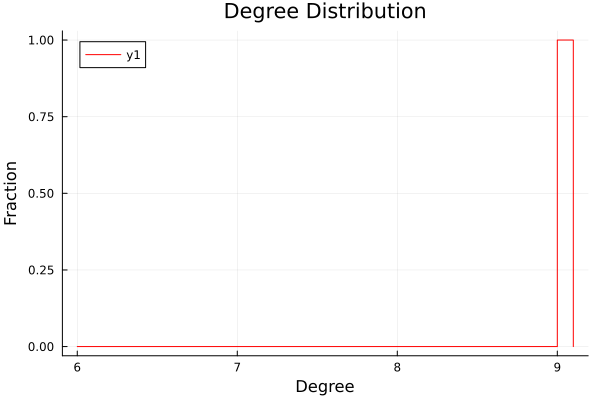

In [66]:
histogram(degree_seq,
    bins=50,
    normalize=:probability,   # y-axis as fraction of total
    title="Degree Distribution",
    #label = "Degree Dist: 400k population",
    xlabel="Degree",
    ylabel="Fraction",
    color = :red
)

In [67]:
global_clustering_coefficient(clustered_G)
#global_clustering_coefficient(unclustered_G)

0.25000105555793056

## Epidemic Simulation

#### Network Parameters (no intervention)

In [72]:
#parameters for both contact tracing and no contact tracing

# Call contacts map
contacts_map = build_contacts_map(N, all_edges)

if clustered_choice == 1
    # Clustered network 
    
    target_R0 = 1.4
    HH_λ = 0.89
    r_R_c_λ = 0.211
    # r-Regular Random Network with Clique Size c
    # You r=9 and c=4 you get for R0 = [1.4, 1.6, 1.8, 2.0, 2.2, 2.4], λ = [0.211, 0.247, 0.285, 0.327, 0.375, 0.435]
    # You r=6 and c=4 you get for R0 = [1.4, 1.6, 1.8, 2.0, 2.2], λ = [0.434, 0.544, 0.689, 0.9, 1.317]
     
    λ = compute_λ(clustered_choice, network_choice, target_R0, degree_seq, HH_λ, r_R_c_λ, er_ave_deg, r)
    
    
else
    # Unclustered network
    
    target_R0 = 2.0#7.99
    HH_λ = 0.89
    r_R_c_λ = 0.75
    λ = compute_λ(clustered_choice, network_choice, target_R0, degree_seq, HH_λ, r_R_c_λ, er_ave_deg, r)
end

γ_shape, γ_scale = 1.82, 2.20 # Parameters for gamma distribution (Choice from Jesse Knight 2020 paper)
#γ_shape, γ_scale = 10000.00, 0.0004
exp_dist_rate = 2.5 # Parameters for exponential distribution
use_exponential = false # Choosing exponential or gamma distribution for generation time distribution

gen_time_dist = use_exponential ? Exponential(exp_dist_rate) : Gamma(γ_shape, γ_scale)
gen_time_samples, poisson_samples, sample_indices = make_random_buffers(gen_time_dist; buffer_size=1_000_000)

infectious_delay_days = 0 # Number of days of days of not being infectious after getting infected
infectious_delay_policy = :shift # t_attempt = t_infect + infectious_delay_days + dt, where dt~gamma(γ_shape, γ_scale) or exp(exp_dist_rate)
#infectious_delay_policy = :clamp # t_attempt = max(t_infect + infectious_delay_days, t_infect + dt)

No_ini_inf = 1 # Number of initially infected individual(s)
#initial_infected = rand(Giant_Component, No_ini_inf)  # Initially infected individual(s)
initial_infected = rand(1:N, No_ini_inf)  # Initially infected individual(s)
max_time = 100.0;

#### Epidemic Parameters (no intervention)

In [73]:
# Parameters for case with no intervention
allow_CT = 0
multiple_step_CT = 0

p_detect = 0.0
p_isolate = 0.0
p_trace = 0.0

prevalence_threshold = 0.0

isolation_delay = 0.0
tracing_delay = 0.0
test_time_delay = 0.0
time_to_recovery = 0.0

initial_isolation_efficacy = 0.0
partial_isolation_efficacy = 0.0
post_isolation_efficacy = 0.0
frtr_det = 0.0; # fraction of transmission that happens before detection

#### Multiple simulation parameters

In [74]:
# Multiple simulation parameters
use_cum_gen_counts = 1
seeds_per_run = 1
n_runs = 1000
max_attempts = n_runs * seeds_per_run * 4
initial_infected_pool = shared_initial_infected_pool(1:N, max_attempts);


#### Simulating epidemic (no intervention)

In [ ]:
@time begin
# For the case with no contact tracing,
# prevalence_threshold = 0
# allow_CT = 0

individuals_no_intv, infection_log_no_intv, epidemic_curve_no_intv, detection_log_no_intv, isolation_log_no_intv, recovery_log_no_intv, partial_isolation_log_no_intv, intervention_time_no_intv = simulate_sir_on_network_intervention(N,
    contacts_map, λ, γ_shape, γ_scale, gen_time_samples, poisson_samples, sample_indices, initial_infected, max_time, p_detect, p_isolate, prevalence_threshold, allow_CT, multiple_step_CT, 
    initial_isolation_efficacy, partial_isolation_efficacy, isolation_delay, tracing_delay, time_to_recovery,p_trace, test_time_delay,
    post_isolation_efficacy; exp_dist_rate, use_exponential, infectious_delay_days, infectious_delay_policy, debug=false)
end


status_no_intv = [s.status for s in individuals_no_intv]
summary_no_intv = Dict(:S => 0, :I => 0, :R => 0)
for s in values(status_no_intv)
    summary_no_intv[s] += 1
end
println("Final state counts: ", summary_no_intv)


#### Calculating theoretical R0

Remember to switch the clustered_choice between 0 (clustered network) and 1 (unclustered network) depending on the network you are using so as to get the correct R0.

In [ ]:
R0_theo = R0_theoretical(clustered_choice, network_choice, λ, degree_seq, er_ave_deg, r)

#R0_theoretical(λ, degree_seq, clustered_choice)

In [ ]:
λ

#### Visualization of epidemic curve (no intervention)
allow_intv takes binary values 0 (no intervention) or 1 (with intervention) as input

In [ ]:
allow_intv = 0
plot_epidemic_curve(epidemic_curve_no_intv, allow_intv)
#savefig("Epi_curve_No_CT.png")

In [ ]:
savefig("Epi_curve_No_CT.png")

#### Visualization of cumulative infection curve (no intervention)

In [ ]:
allow_intv = 0
plot_cumulative_infections(infection_log_no_intv, allow_intv)

In [ ]:
savefig("Cum_Inf_No_CT.png")

#### Calculating the final epidemic fraction without intervention
The epidemic size is computed using the formula R∞ = 1-S∞, where S∞ is the final susceptible fraction

In [ ]:
#R∞ = 1-Computing_S∞(R0_theo)

#### Dictionaries of infections per generation for both intervention and no intervention phases

In [ ]:
infection_generation_no_intv = build_generation_dict(infection_log_no_intv)

#### Visualization of infections per generation for the no intervention phase

In [ ]:
plot_infections_by_generation_opt(infection_generation_no_intv, label="No intervention", color=:blue)

In [ ]:
no_intv_counts = gen_counts_from_generation_dict(infection_generation_no_intv);

## Estimating Ro

### Estimating R0 in single simulation (no intervention)

#### Visualization

In [ ]:
intv_allow = 0
post_intv = 0

if use_cum_gen_counts == 1
    
    p0 = Re_by_generation_from_cumcounts(no_intv_counts, λ, clustered_choice, intv_allow, post_intv, n_runs;
    title = "R₀ by Generation without interventions (Multiple Simulations)",
    color = :blue, include_generation_zero = true, figsize = (900, 600), debug=false)

else
    
    p0 = Re_by_generation_multiple_simulations(infection_generation_no_intv, λ, clustered_choice, intv_allow,
    post_intv; title = "R₀ by Generation without interventions (Multiple Simulations)",
    color = :blue, include_generation_zero = true, figsize = (900, 600), debug=false);
    
end;
p0

#### Visualization (Time Series)

In [ ]:
intv_allow = 0
post_intv = 0


if use_cum_gen_counts == 1
    
    _, _, p1 = Re_by_generation_from_cumcounts_ci(no_intv_counts, 
    λ, clustered_choice, intv_allow, post_intv, n_runs;
    title = "R₀ by Generation without interventions (Multiple Simulations)",
    color = :blue, confidence_level = 0.95, figsize = (900, 600), debug=false);

else
    
    _, _, p1 = Re_by_generation_individual_bootstrap_ci(infection_generation_no_intv,
    λ, clustered_choice, intv_allow, post_intv;
    title = "R₀ by Generation without interventions (Multiple Simulation)",
    color = :blue, confidence_level = 0.95,
    include_generation_zero = true,
    figsize = (900, 600), debug=false
);
    
end;


p1

### Estimating R0 in multiple simulations (no intervention)

#### Simulation

When use_cum_gen_count = 1, returns only the cummulative generation counts (without intervention), otherwise it returns generation dictionaries and infection log dictionaries (without intervention)

In [ ]:
if use_cum_gen_counts == 1
    no_intv_cum_gen_counts  = run_epidemic_simulations_without_interventions_cum_gen_counts(N, contacts_map, 
    λ, γ_shape, γ_scale, gen_time_samples, poisson_samples, sample_indices, max_time, p_detect, p_isolate, 
    prevalence_threshold, allow_CT, multiple_step_CT, isolation_delay, tracing_delay, time_to_recovery, 
    p_trace, test_time_delay, initial_isolation_efficacy, partial_isolation_efficacy, post_isolation_efficacy, 
    n_runs, max_attempts, initial_infected_pool; exp_dist_rate, use_exponential, seeds_per_run, 
    infectious_delay_days, infectious_delay_policy, debug=false);

else
    
    generation_dicts_no_intv, infection_log_dicts_no_intv = run_epidemic_simulations_without_interventions(
    N, contacts_map, λ, γ_shape, γ_scale, gen_time_samples, poisson_samples, sample_indices, max_time, p_detect, p_isolate, prevalence_threshold, allow_CT, multiple_step_CT, 
    isolation_delay, tracing_delay, time_to_recovery, p_trace, test_time_delay, initial_isolation_efficacy,
    partial_isolation_efficacy, post_isolation_efficacy, n_runs, max_attempts, initial_infected_pool; 
    exp_dist_rate, use_exponential, seeds_per_run, infectious_delay_days, infectious_delay_policy, debug=false);
    
end;

#### Visualization

In [ ]:
intv_allow = 0
post_intv = 0

if use_cum_gen_counts == 1
    
    p = Re_by_generation_from_cumcounts(no_intv_cum_gen_counts, λ, clustered_choice, intv_allow, post_intv, n_runs;
    title = "R₀ by Generation without interventions (Multiple Simulations)",
    color = :blue, include_generation_zero = true, figsize = (900, 600), debug=false)

else
    
    Re_by_generation_multiple_simulations(generation_dicts_no_intv, λ, clustered_choice, intv_allow,
    post_intv; title = "R₀ by Generation without interventions (Multiple Simulations)",
    color = :blue, include_generation_zero = true, figsize = (900, 600), debug=false);
    
end;
p

#### Visualization (Time Series)

In [ ]:
intv_allow = 0
post_intv = 0


if use_cum_gen_counts == 1
    
    R0_values, _ , no_intv_plot = Re_by_generation_from_cumcounts_ci(no_intv_cum_gen_counts, 
    λ, clustered_choice, intv_allow, post_intv, n_runs;
    title = "R₀ by Generation without interventions (Multiple Simulations)",
    color = :blue, confidence_level = 0.95, figsize = (900, 600), debug=false);

else
    
    R0_values, _ , no_intv_plot = Re_by_generation_individual_bootstrap_ci(generation_dicts_no_intv,
    λ, clustered_choice, intv_allow, post_intv;
    title = "R₀ by Generation without interventions (Multiple Simulation)",
    color = :blue, confidence_level = 0.95,
    include_generation_zero = true,
    figsize = (900, 600), debug=false
);
    
end;


no_intv_plot

In [ ]:
savefig("R₀ by generation via mutiple simulations (no intervention).png")

In [ ]:
R0_values

In [ ]:
mean(R0_values[3:8])

## Estimating Re

### Network Parameters (with intervention)

### Epidemic Parameters (with intervention)

In [75]:
# Intervention epidemic parameters
allow_CT = 0
multiple_step_CT = 0

p_detect = 0.7#0.8
p_isolate = 0.8
p_trace = 0.7#0.8

prevalence_threshold = 500/N

isolation_delay = 0.0
tracing_delay = 1.0
test_time_delay = 1.0
time_to_recovery = 0.0

initial_isolation_efficacy = 0.1
partial_isolation_efficacy = 1.0
post_isolation_efficacy = 1.0
frtr_det = 0.5; # fraction of transmission that happens before detection

#### Calculating theoretical R0 theoretical Re

Remember to switch the clustered_choice between 0 (clustered network) and 1 (unclustered network) depending on the network you are using so as to get the correct R0.

In [76]:
R0_theo = R0_theoretical(clustered_choice, network_choice, λ, degree_seq, er_ave_deg, r)
#R0_theo = R0_theoretical(λ, degree_seq, clustered_choice)

0.211

In [77]:
#R_eff = estimate_effective_R0(R0_theo, p_detect, p_isolate, post_isolation_efficacy)

In [78]:
λ

0.211

### Simulating epidemic with intervention

In [ ]:
@time begin

individuals, infection_log, epidemic_curve, detection_log, isolation_log, recovery_log, partial_isolation_log, intervention_time = simulate_sir_on_network_intervention(N, 
    contacts_map, λ, γ_shape, γ_scale, gen_time_samples, poisson_samples, sample_indices, initial_infected, max_time, p_detect, p_isolate, 
    prevalence_threshold, allow_CT, multiple_step_CT, isolation_delay, tracing_delay, time_to_recovery, 
    p_trace, test_time_delay, initial_isolation_efficacy, partial_isolation_efficacy, 
    post_isolation_efficacy; exp_dist_rate, use_exponential, infectious_delay_days, infectious_delay_policy, debug=true)
end

status = [s.status for s in individuals]
summary_intv = Dict(:S => 0, :I => 0, :R => 0)
for s in values(status)
    summary_intv[s] += 1
end
println("Final state counts: ", summary_intv)

#### Visualization of epidemic curve (with intervention)

In [ ]:
plot_epidemic_curve(epidemic_curve, allow_CT)
#savefig("Epi_curve_CT.png")

In [ ]:
savefig("Epi_curve_CT.png")

#### Visualization of cumulative infection curve (with intervention)

In [ ]:
plot_cumulative_infections(infection_log, allow_CT)
#savefig("Cum_Inf_CT.png")

In [ ]:
savefig("Cum_Inf_CT.png")

#### Dictionaries of infections per generation for intervention phases

In [ ]:
infection_generation = build_generation_dict(infection_log);

#### Count and map of infections per generation for intervention phase

In [ ]:
gen_map = individuals_by_generation(infection_generation)
sort(gen_map);

intv_counts = gen_counts_from_generation_dict(infection_generation);

#### Pre intervention infection log

In [ ]:
pre_intervention_infection_log = filter(x -> x[3] < intervention_time, infection_log);

#### Post intervention infection log

In [ ]:
post_intervention_infection_log = filter(x -> x[3] >= intervention_time, infection_log);

#### Post intervention initial infected

In [ ]:
post_intervention_initial_infected = find_post_intervention_initial_infected(infection_log, intervention_time);

#### Analysis on partial isolation

In [ ]:
detection_log_ids = getindex.(detection_log, 1)
isolation_log_ids = getindex.(isolation_log, 1)
partial_isolation_log_ids = getindex.(partial_isolation_log, 1)
#unique(partial_isolation_log_ids)
unique_partially_isolated = countmap([log[1] for log in partial_isolation_log])
sort(unique_partially_isolated);

In [ ]:
length(unique_partially_isolated)/length(isolation_log);

In [ ]:
intersect(unique(partial_isolation_log_ids), isolation_log_ids);

In [ ]:
length(isolation_log_ids) - length(intersect(unique(partial_isolation_log_ids), isolation_log_ids));

#### Dictionaries of pre and post intervention infection generation

In [ ]:
pre_intervention_infection_generation = build_generation_dict(pre_intervention_infection_log)
post_intervention_infection_generation = build_generation_dict(post_intervention_infection_log; 
already_sorted=true, seeds=post_intervention_initial_infected);

#### Count and map of infection generation for pre intervention phase

In [ ]:
pre_intervention_gen_map = individuals_by_generation(pre_intervention_infection_generation)
sort(pre_intervention_gen_map);

pre_intv_counts = gen_counts_from_generation_dict(pre_intervention_infection_generation);

#### Count and map of infection generation for post intervention phase

In [ ]:
post_intervention_gen_map = individuals_by_generation(post_intervention_infection_generation)
sort(post_intervention_gen_map);

post_intv_counts = gen_counts_from_generation_dict(post_intervention_infection_generation);

#### Visualization of infections per generation for the intervention phase

In [ ]:
plot_infections_by_generation_opt(infection_generation, label="With intervention", color=:blue)

### Estimating Re in single simulation with intervention (pre and post)

#### Visualization 

In [ ]:
intv_allow = 1
post_intv = 0

if use_cum_gen_counts == 1
    
    p_plot1 = Re_by_generation_from_cumcounts(intv_counts, λ, clustered_choice, intv_allow, post_intv, n_runs;
    title = "Re by Generation without interventions (Multiple Simulations)",
    color = :blue, include_generation_zero = true, figsize = (900, 600), debug=false)

else
    
    p_plot1 = Re_by_generation_multiple_simulations(infection_generation, λ, clustered_choice, intv_allow,
    post_intv; title = "Re by Generation without interventions (Multiple Simulations)",
    color = :blue, include_generation_zero = true, figsize = (900, 600), debug=false);
    
end;

p_plot1

#### Visualization (Time Series)

In [ ]:
intv_allow = 1
post_intv = 0


if use_cum_gen_counts == 1
    
    _, _, p_plot2 = Re_by_generation_from_cumcounts_ci(intv_counts, 
    λ, clustered_choice, intv_allow, post_intv, n_runs;
    title = "Re by Generation without interventions (Multiple Simulations)",
    color = :blue, confidence_level = 0.95, figsize = (900, 600), debug=false);

else
    
    _, _, p_plot2 = Re_by_generation_individual_bootstrap_ci(infection_generation,
    λ, clustered_choice, intv_allow, post_intv;
    title = "Re by Generation without interventions (Multiple Simulation)",
    color = :blue, confidence_level = 0.95,
    include_generation_zero = true,
    figsize = (900, 600), debug=false
);
    
end;


p_plot2

### Estimating Re in single simulation with intervention (post)

#### Visualization

In [ ]:
intv_allow = 1
post_intv = 1

if use_cum_gen_counts == 1
    
    p_plot3 = Re_by_generation_from_cumcounts(post_intv_counts, λ, clustered_choice, intv_allow, post_intv, n_runs;
    title = "Re by Generation without interventions (Multiple Simulations)",
    color = :blue, include_generation_zero = true, figsize = (900, 600), debug=false)

else
    
    p_plot3 = Re_by_generation_multiple_simulations(post_intervention_infection_generation, λ, clustered_choice, intv_allow,
    post_intv; title = "Re by Generation without interventions (Multiple Simulations)",
    color = :blue, include_generation_zero = true, figsize = (900, 600), debug=false);
    
end;

p_plot3

#### Visualization (Time Series)

In [ ]:
intv_allow = 1
post_intv = 1


if use_cum_gen_counts == 1
    
    _, _, p_plot4 = Re_by_generation_from_cumcounts_ci(post_intv_counts, 
    λ, clustered_choice, intv_allow, post_intv, n_runs;
    title = "Re by Generation without interventions (Multiple Simulations)",
    color = :blue, confidence_level = 0.95, figsize = (900, 600), debug=false);

else
    
    _, _, p_plot4 = Re_by_generation_individual_bootstrap_ci(post_intervention_infection_generation,
    λ, clustered_choice, intv_allow, post_intv;
    title = "Re by Generation without interventions (Multiple Simulation)",
    color = :blue, confidence_level = 0.95,
    include_generation_zero = true,
    figsize = (900, 600), debug=false
);
    
end;


p_plot4

### Estimating Re in multiple simulations with intervention (pre and post)

#### Simulation

When use_cum_gen_count = 1, returns only the cummulative generation counts (with intervention), otherwise it returns generation dictionaries and infection log dictionaries (with intervention)

In [79]:
#use_cum_gen_counts = 1

if use_cum_gen_counts == 1
    with_intv_cum_gen_counts, with_intv_cum_postgen_counts  = run_epidemic_simulations_with_interventions_cum_gen_counts(N, contacts_map, 
    λ, γ_shape, γ_scale, gen_time_samples, poisson_samples, sample_indices, max_time, p_detect, p_isolate, 
    prevalence_threshold, allow_CT, multiple_step_CT, isolation_delay, tracing_delay, time_to_recovery, 
    p_trace, test_time_delay, initial_isolation_efficacy, partial_isolation_efficacy, post_isolation_efficacy, 
    n_runs, max_attempts, initial_infected_pool; exp_dist_rate, use_exponential, seeds_per_run, 
    infectious_delay_days, infectious_delay_policy, progress_bar = true, debug=false);

else
    
    generation_dicts, infection_log_dicts = run_epidemic_simulations_with_interventions(
    N, contacts_map, λ, γ_shape, γ_scale, gen_time_samples, poisson_samples, sample_indices, max_time, p_detect, p_isolate, prevalence_threshold, allow_CT, multiple_step_CT, 
    isolation_delay, tracing_delay, time_to_recovery, p_trace, test_time_delay, initial_isolation_efficacy,
    partial_isolation_efficacy, post_isolation_efficacy, n_runs, max_attempts, initial_infected_pool; 
    exp_dist_rate, use_exponential, seeds_per_run, infectious_delay_days, infectious_delay_policy, debug=false);
    
end;

Simulations with interventions: 100%|███████████████████| Time: 0:05:34




#### Visualization 

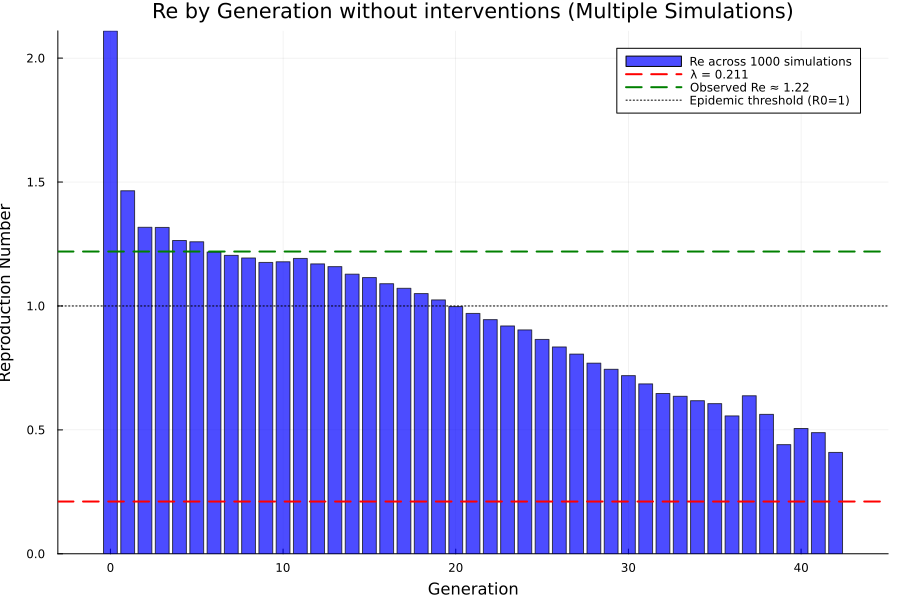

In [80]:
intv_allow = 1
post_intv = 0

if use_cum_gen_counts == 1
    
    pplot1 = Re_by_generation_from_cumcounts(with_intv_cum_gen_counts, λ, clustered_choice, intv_allow, post_intv, n_runs;
    title = "Re by Generation without interventions (Multiple Simulations)",
    color = :blue, include_generation_zero = true, figsize = (900, 600), debug=false)

else
    
    pplot1 = Re_by_generation_multiple_simulations(generation_dicts, λ, clustered_choice, intv_allow,
    post_intv; title = "Re by Generation without interventions (Multiple Simulations)",
    color = :blue, include_generation_zero = true, figsize = (900, 600), debug=false);
    
end;

pplot1

#### Visualization (Time Series)

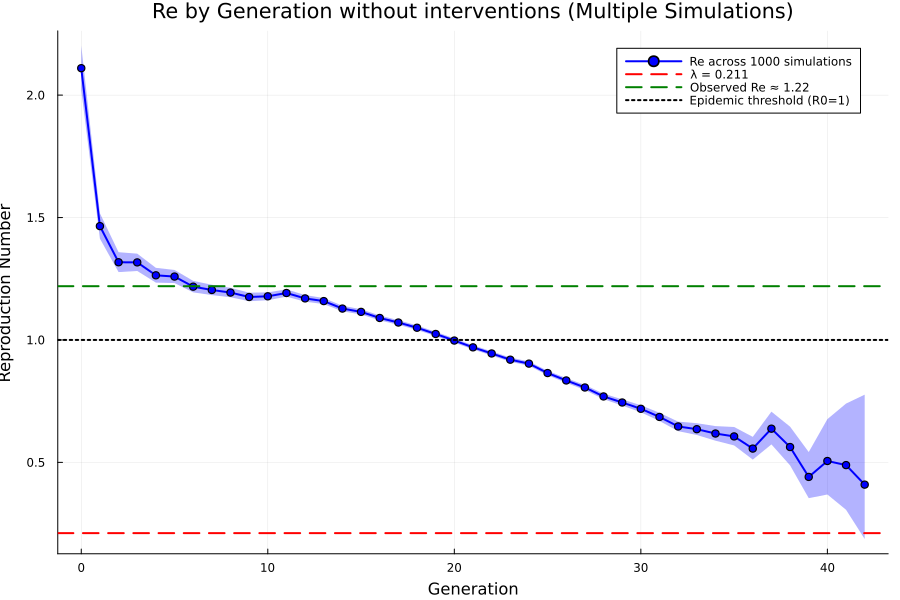

In [81]:
intv_allow = 1
post_intv = 0


if use_cum_gen_counts == 1
    
    _, _, pplot2 = Re_by_generation_from_cumcounts_ci(with_intv_cum_gen_counts, 
    λ, clustered_choice, intv_allow, post_intv, n_runs;
    title = "Re by Generation without interventions (Multiple Simulations)",
    color = :blue, confidence_level = 0.95, figsize = (900, 600), debug=false);

else
    
    _, _, pplot2 = Re_by_generation_individual_bootstrap_ci(generation_dicts,
    λ, clustered_choice, intv_allow, post_intv;
    title = "Re by Generation without interventions (Multiple Simulation)",
    color = :blue, confidence_level = 0.95,
    include_generation_zero = true,
    figsize = (900, 600), debug=false
);
    
end;


pplot2

### Estimating Re in multiple simulations with intervention (post)

#### Visualization

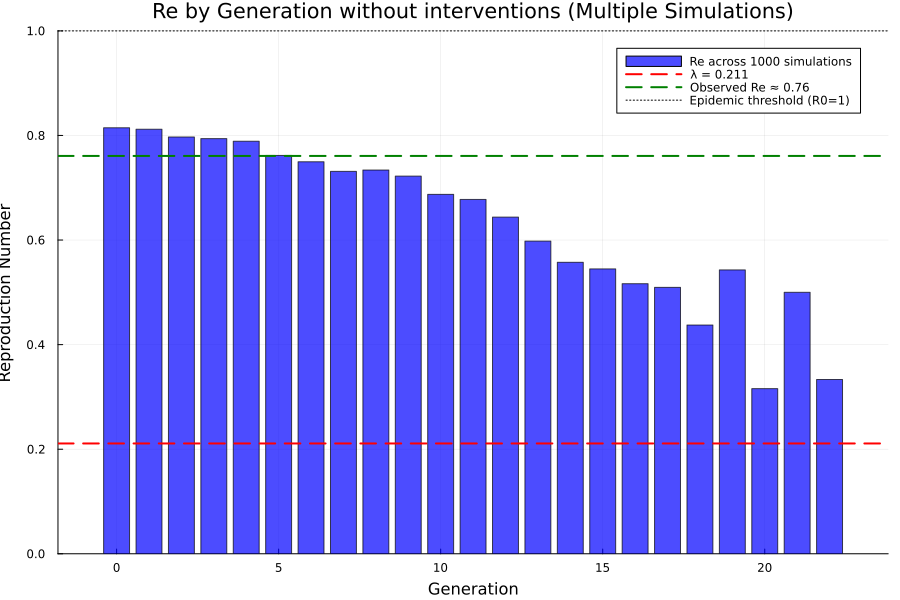

In [82]:
intv_allow = 1
post_intv = 1

if use_cum_gen_counts == 1
    
    pplot3 = Re_by_generation_from_cumcounts(with_intv_cum_postgen_counts, λ, clustered_choice, intv_allow, post_intv, n_runs;
    title = "Re by Generation without interventions (Multiple Simulations)",
    color = :blue, include_generation_zero = true, figsize = (900, 600), debug=false)

else
    
    pplot3 = Re_by_generation_multiple_simulations(generation_dicts_no_intv, λ, clustered_choice, intv_allow,
    post_intv; title = "Re by Generation without interventions (Multiple Simulations)",
    color = :blue, include_generation_zero = true, figsize = (900, 600), debug=false);
    
end;

pplot3

#### Visualization (Time Series)

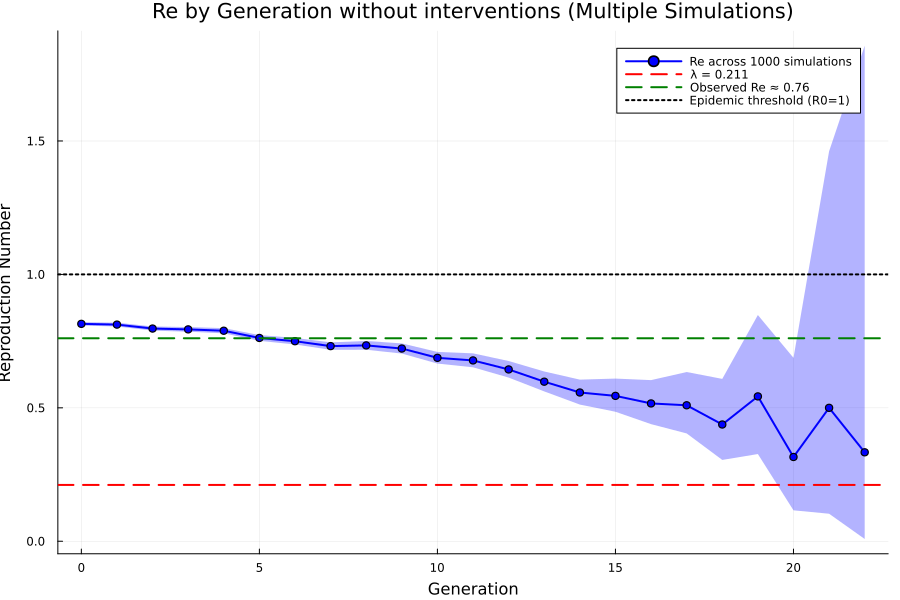

In [83]:
intv_allow = 1
post_intv = 1


if use_cum_gen_counts == 1
    
    Re_values, _, pplot4 = Re_by_generation_from_cumcounts_ci(with_intv_cum_postgen_counts, 
    λ, clustered_choice, intv_allow, post_intv, n_runs;
    title = "Re by Generation without interventions (Multiple Simulations)",
    color = :blue, confidence_level = 0.95, figsize = (900, 600), debug=false);

else
    
    Re_values, _, pplot4 = Re_by_generation_individual_bootstrap_ci(post_intervention_generation_dicts,
    λ, clustered_choice, intv_allow, post_intv;
    title = "Re by Generation without interventions (Multiple Simulation)",
    color = :blue, confidence_level = 0.95,
    include_generation_zero = true,
    figsize = (900, 600), debug=false
);
    
end;


pplot4

In [ ]:
savefig("Rₑ by generation via mutiple simulations  (with intervention).png")

In [84]:
Re_values

23-element Vector{Float64}:
 0.8146901681420564
 0.8118721167601627
 0.7970856679007702
 0.7939642324888226
 0.7888941029250743
 0.7618273387000832
 0.7496226120451824
 0.7312686618984793
 0.7339284018611718
 0.7222150342864536
 0.6873880329630957
 0.6776127182694813
 0.6438461538461538
 0.5979689366786141
 0.5574425574425574
 0.5448028673835126
 0.5164473684210527
 0.5095541401273885
 0.4375
 0.5428571428571428
 0.3157894736842105
 0.5
 0.3333333333333333

In [ ]:
#R∞ = 1-Computing_S∞(R0_theo)

In [85]:
R0_values = collect(1.4:0.2:2.4)

if clustered_choice == 1
    # r-Regular Random Network with Clique Size c
    # You r=9 and c=4 you get for R0 = [1.4, 1.6, 1.8, 2.0, 2.2, 2.4], λ = [0.211, 0.247, 0.285, 0.327, 0.375, 0.435]
    r_R_c_λ_values = [0.211, 0.247, 0.285, 0.327, 0.375, 0.435]
    # You r=6 and c=4 you get for R0 = [1.4, 1.6, 1.8, 2.0, 2.2], λ = [0.434, 0.544, 0.689, 0.9, 1.317]
    # r_R_c_λ_values = [0.434, 0.544, 0.689, 0.9, 1.317]
else
    λ_values = compute_lambda_vector(R0_values, clustered_choice, network_choice, degree_seq, HH_λ, r_R_c_λ, er_ave_deg, r)
end

6-element Vector{Float64}:
 0.211
 0.247
 0.285
 0.327
 0.375
 0.435

In [86]:
gmin = 4#4
gmax = 10#7

if use_cum_gen_counts == 1
    effective_Re_from_generations_cum_gen_counts(with_intv_cum_postgen_counts, λ, 
    clustered_choice, intv_allow, post_intv, gmin, gmax, n_runs)
else
    effective_Re_from_generations(post_intervention_generation_dicts, λ, 
    clustered_choice, intv_allow, post_intv, gmin, gmax)
end

0.7393063120970772

In [87]:
if clustered_choice == 1
    estimate_Re_for_R0_and_regime(R0_values[1], λ, clustered_choice, intv_allow, post_intv, N, 
    contacts_map, γ_shape, γ_scale, gen_time_samples, poisson_samples, sample_indices, max_time, 
    p_detect, p_isolate, prevalence_threshold, allow_CT, multiple_step_CT, isolation_delay, 
    tracing_delay, time_to_recovery, p_trace, test_time_delay, initial_isolation_efficacy,
    partial_isolation_efficacy, post_isolation_efficacy, n_runs, max_attempts, initial_infected_pool, 
    exp_dist_rate, use_exponential, seeds_per_run, infectious_delay_days, infectious_delay_policy, 
    use_cum_gen_counts, gmin, gmax)
else
    estimate_Re_for_R0_and_regime(R0_theo, λ, clustered_choice, intv_allow, post_intv, N, 
    contacts_map, γ_shape, γ_scale, gen_time_samples, poisson_samples, sample_indices, max_time, 
    p_detect, p_isolate, prevalence_threshold, allow_CT, multiple_step_CT, isolation_delay, 
    tracing_delay, time_to_recovery, p_trace, test_time_delay, initial_isolation_efficacy,
    partial_isolation_efficacy, post_isolation_efficacy, n_runs, max_attempts, initial_infected_pool, 
    exp_dist_rate, use_exponential, seeds_per_run, infectious_delay_days, infectious_delay_policy, 
    use_cum_gen_counts, gmin, gmax)
end

Simulations with interventions: 100%|███████████████████| Time: 0:05:40


(R0 = 1.4, Re_eff = 0.7386089697987941, ratio = 0.5275778355705673)

In [ ]:
if clustered_choice == 1
    ratios_noCT, ratios_oneCT, ratios_multiCT = compute_effectiveness_curves(R0_values, 
    r_R_c_λ_values, clustered_choice, intv_allow, post_intv, N, contacts_map, γ_shape, 
    γ_scale, gen_time_samples, poisson_samples, sample_indices, max_time, p_detect, 
    p_isolate, prevalence_threshold, allow_CT, multiple_step_CT, isolation_delay, 
    tracing_delay, time_to_recovery, p_trace, test_time_delay, initial_isolation_efficacy,
    partial_isolation_efficacy, post_isolation_efficacy, n_runs, max_attempts, 
    initial_infected_pool, exp_dist_rate, use_exponential, seeds_per_run, 
    infectious_delay_days, infectious_delay_policy, use_cum_gen_counts, gmin, gmax);
else
    ratios_noCT, ratios_oneCT, ratios_multiCT = compute_effectiveness_curves(R0_values, 
    λ_values, clustered_choice, intv_allow, post_intv, N, contacts_map, γ_shape, 
    γ_scale, gen_time_samples, poisson_samples, sample_indices, max_time, p_detect, 
    p_isolate, prevalence_threshold, allow_CT, multiple_step_CT, isolation_delay, 
    tracing_delay, time_to_recovery, p_trace, test_time_delay, initial_isolation_efficacy,
    partial_isolation_efficacy, post_isolation_efficacy, n_runs, max_attempts, 
    initial_infected_pool, exp_dist_rate, use_exponential, seeds_per_run, 
    infectious_delay_days, infectious_delay_policy, use_cum_gen_counts, gmin, gmax);
end;

In [ ]:
p = plot_Re_over_R0_curves(R0_values, ratios_noCT, ratios_oneCT, ratios_multiCT;
                           title_str = "Re/R₀ vs R₀ for Random Regular Network",
                           legend_pos = :left)
display(p)

In [ ]:
savefig("Effectiveness of intervention for Random Regular Network.png")
#savefig("A.png")

In [ ]:
R0_values_col = reshape(R0_values, :, 1)  
ratios_noCT_col = reshape(ratios_noCT, :, 1)
ratios_oneCT_col = reshape(ratios_oneCT, :, 1)  
ratios_multiCT_col = reshape(ratios_multiCT, :, 1)  

M = hcat(R0_values_col, ratios_noCT_col, ratios_oneCT_col, ratios_multiCT_col)

In [ ]:
df = DataFrame(M, [:R0_values, :No_CT, :One_step_CT, :Multi_step_CT])

In [88]:
# --- ER ---
_, unclustered_ER_edges = generate_ER_graph(N, er_prob)
contacts_map_ER = build_contacts_map(N, unclustered_ER_edges)

er_spec = (name = "ER(k=6)", clustered_choice = 0,
    network_choice = 5, contacts_map = contacts_map_ER,
    deg_seq = Int64[], HH_λ = 0.0, r_R_c_λ = 0.0,
    k = 6.0, r = 0, λ_values = nothing);


# --- RR ---
unclustered_RR_edges = generate_k_regular(N, r; seed=123, output=:edges)
contacts_map_RR = build_contacts_map(N, unclustered_RR_edges)

rr_spec = (name = "RR(r=7)", clustered_choice = 0,
    network_choice = 4, contacts_map = contacts_map_RR,
    deg_seq = Int64[], HH_λ = 0.0, r_R_c_λ = 0.0,
    k = 0.0, r = 7, λ_values = nothing);


# --- Clique network ---
_, clustered_rRRc_edges, _ = generate_clustered_clique_network(N, c_Clique, r_Clique)
contacts_map_CLIQUE = build_contacts_map(N, clustered_rRRc_edges)

clique_spec = (name = "RR+Clique(r=9,c=4)", clustered_choice = 1,
    network_choice = 2, contacts_map = contacts_map_CLIQUE,
    deg_seq = Int64[], HH_λ = 0.0, r_R_c_λ = 0.0,
    k = 0.0, r = 0, λ_values = [0.211, 0.247, 0.285, 0.327, 0.375, 0.435]);
    #k = 0.0, r = 0, λ_values = [0.434, 0.544, 0.689, 0.9, 1.317]);


# --- ECM ---
@load "clustered_all_edges.jld2" clustered_all_edges
clustered_HH_G = rebuild_household_network(clustered_all_edges)
degree_seq_HH = degree(clustered_HH_G)
unclustered_ECM_G, _, _, unclustered_ECM_edges = generate_erased_configuration_model_with_tracking(degree_seq_HH)
degree_seq_ECM = degree(unclustered_ECM_G)
contacts_map_ECM = build_contacts_map(N, unclustered_ECM_edges) 
   

ecm_spec = (name = "ECM", clustered_choice = 0,
    network_choice = 3, contacts_map = contacts_map_ECM,
    deg_seq = degree_seq_ECM, HH_λ = 0.0,r_R_c_λ = 0.0,
    k = 0.0, r = 0, λ_values = nothing);



In [89]:
#network_specs = [er_spec, rr_spec, ecm_spec, clique_spec]
network_specs = [er_spec, rr_spec, clique_spec]


results = compute_effectiveness_across_networks(network_specs, R0_values;
    intv_allow, post_intv, N, γ_shape, γ_scale, gen_time_samples,
    poisson_samples, sample_indices, max_time, p_detect, p_isolate,
    prevalence_threshold, isolation_delay, tracing_delay,
    time_to_recovery, p_trace, test_time_delay,
    initial_isolation_efficacy, partial_isolation_efficacy,
    post_isolation_efficacy, n_runs, max_attempts,
    initial_infected_pool, exp_dist_rate, use_exponential,
    seeds_per_run, infectious_delay_days, infectious_delay_policy,
    use_cum_gen_counts, gmin, gmax, progress_bar =true);
    

Effectiveness across networks: 100%|████████████████████| Time: 14:32:08


In [90]:
p_noCT = plot_across_networks(results, :noCT;   title_str="Effectiveness of No CT intervention", legend_pos=:bottomright)
savefig("Effectiveness of No CT intervention.png")

p_oneCT = plot_across_networks(results, :oneCT;  title_str="Effectiveness of One Step CT intervention", legend_pos=:bottomright)
savefig("Effectiveness of One Step CT intervention.png")

p_multiCT = plot_across_networks(results, :multiCT;title_str="Effectiveness of Multi Step CT intervention", legend_pos=:bottomright)
savefig("Effectiveness of Multi Step CT intervention.png");

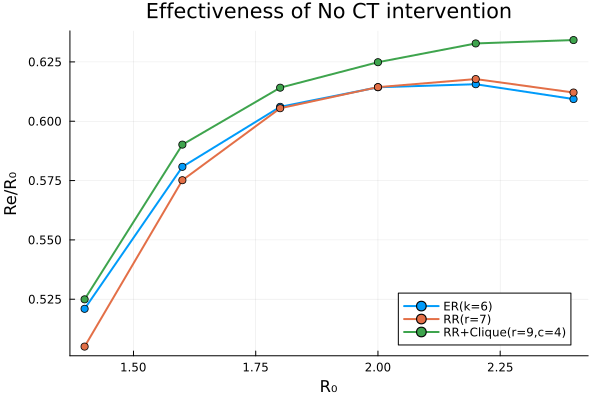

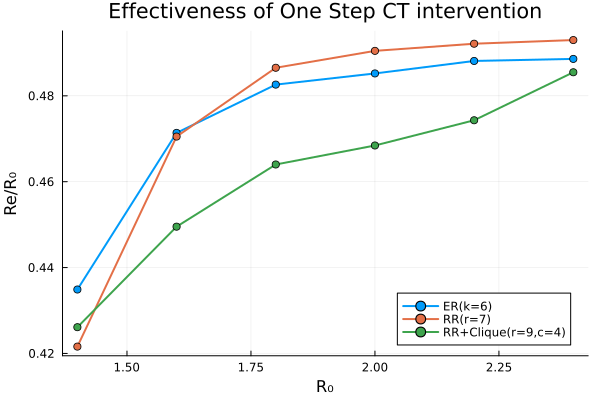

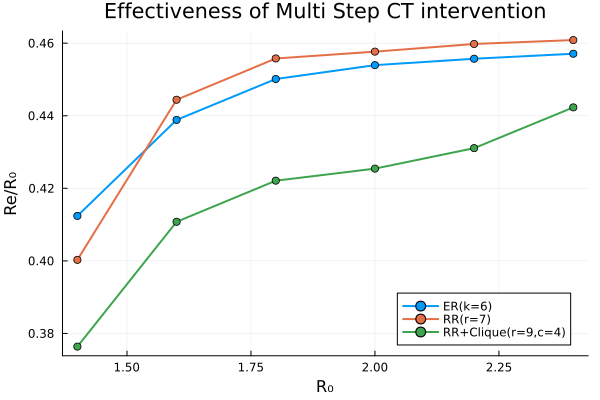

In [92]:
display(p_noCT)
display(p_oneCT)
display(p_multiCT)

In [ ]:
results

In [ ]:
er=results["ER(k=6)"]
rr=results["RR(r=7)"]
rr_c=results["RR+Clique(r=9,c=4)"];

In [ ]:
er.noCT

In [ ]:
rr.noCT

In [ ]:
rr_c.noCT

In [ ]:
function mean_neighbors_per_generation_mult(
    generation_dicts::AbstractVector{<:Dict{Int,Int}},
    G::SimpleGraph
)
    sum_deg   = Dict{Int, Float64}()  # generation => sum of degrees
    n_per_gen = Dict{Int, Int}()      # generation => number of nodes

    @inbounds for generation in generation_dicts
        for (node, gen) in generation
            d = degree(G, node)
            sum_deg[gen]   = get(sum_deg, gen, 0.0) + d
            n_per_gen[gen] = get(n_per_gen, gen, 0) + 1
        end
    end

    mean_deg = Dict{Int, Float64}()
    @inbounds for (g, c) in n_per_gen
        mean_deg[g] = c == 0 ? NaN : sum_deg[g] / c
    end

    return mean_deg, n_per_gen
end

In [ ]:
# gen_dicts :: Vector{Dict{Int,Int}} from multiple runs
#mean_deg_dict, n_per_gen_dict = mean_neighbors_per_generation_mult(generation_dicts_no_intv, clustered_G)
mean_deg_dict, n_per_gen_dict = mean_neighbors_per_generation_mult(generation_dicts_no_intv, unclustered_G)

In [ ]:
sort(mean_deg_dict)

In [ ]:
sort(n_per_gen_dict)

In [ ]:
gens = sort(collect(keys(mean_deg_dict)))
#plot(gens, [round(mean_deg_dict[g]) for g in gens];
plot(gens, [mean_deg_dict[g] for g in gens];
     seriestype=:scatter, marker = :circle, lw =2, xlabel="Generation", 
     ylabel="Mean degree", label="Mean neighbors per generation",
     title="Mean neighbors per generation")

#plot!(gens, [round(mean_deg_dict[g]) for g in gens];
plot!(gens, [mean_deg_dict[g] for g in gens];
     seriestype=:line,
     lw=2,
     color=:blue,
     label="")

In [ ]:
savefig("mean neighbors per generation  (no intervention).png")

In [ ]:
# --------------------------------------------------------------------------
# 1.
# --------------------------------------------------------------------------
# indiv_groups[i] = vector of clique IDs that individual i belongs to
function build_indiv_groups(group_members::Vector{Vector{Int}}, N::Int)
    indiv_groups = [Int[] for _ in 1:N]
    @inbounds for (g, members) in enumerate(group_members)
        for v in members
            push!(indiv_groups[v], g)
        end
    end
    return indiv_groups
end


# --------------------------------------------------------------------------
# 2.
# --------------------------------------------------------------------------
"""
    infection_clique_map(infection_log, indiv_groups; seed_ids)

Return a Dict person -> clique_id giving the clique where each person
was first infected.

- infection_log: Vector of (infectee, infector, time), sorted by time
- indiv_groups:  indiv_groups[i] = vector of clique IDs for i
- seed_ids:      vector of initial infected individuals (infector==0)
"""
function infection_clique_map(
    infection_log::Vector{Tuple{Int,Int,Float64}},
    indiv_groups::Vector{Vector{Int}};
    seed_ids::AbstractVector{<:Integer}
)
    infect_clique = Dict{Int,Int}()

    # 1) assign seeds: pick an arbitrary clique they belong to
    @inbounds for s in seed_ids
        groups = indiv_groups[s]
        @assert !isempty(groups) "Seed $s has no cliques?"
        infect_clique[s] = groups[1]    # or rand(groups) if you prefer
    end

    # 2) assign clique for each non-seed, in time order
    # (assuming infection_log sorted by time)
    @inbounds for (child, parent, _) in infection_log
        parent == 0 && continue  # skip seed entries that use 0 as infector
        haskey(infect_clique, child) && continue  # already assigned (first infection only)

        parent_cliques = indiv_groups[parent]
        child_cliques  = indiv_groups[child]

        # intersection: cliques where infection could have occurred
        # (in your model, they *should* share exactly one clique in practice)
        shared = intersect(parent_cliques, child_cliques)
        @assert !isempty(shared) "No shared clique between $parent and $child – unexpected in clique model."

        infect_clique[child] = shared[1]  # pick first shared clique
    end

    return infect_clique
end



# -----------------------------------------------------------------------
# 3.
# -----------------------------------------------------------------------
"""
    clique_R_from_infection_log(infection_log, indiv_groups; seed_ids)

Compute:
- The number of new cliques each infected clique seeds
- The mean of this (clique reproduction number R_clique)

Returns:
    R_clique::Float64,
    out_deg::Dict{Int,Int}   # clique -> number of distinct cliques it infected
"""
function clique_R_from_infection_log(
    infection_log::Vector{Tuple{Int,Int,Float64}},
    indiv_groups::Vector{Vector{Int}};
    seed_ids::AbstractVector{<:Integer}
)
    # 1) map each person to its infection clique
    infect_clique = infection_clique_map(infection_log, indiv_groups; seed_ids=seed_ids)

    # 2) build clique-level adjacency: clique g -> set of cliques it infected
    clique_children = Dict{Int,Set{Int}}()

    @inbounds for (child, parent, _) in infection_log
        parent == 0 && continue   # skip seed "infections"
        # if either missing from infect_clique, skip (defensive)
        haskey(infect_clique, parent) || continue
        haskey(infect_clique, child)  || continue

        c_parent = infect_clique[parent]
        c_child  = infect_clique[child]

        c_parent == c_child && continue  # within-clique, not clique-to-clique

        s = get!(clique_children, c_parent, Set{Int}())
        push!(s, c_child)
    end

    # 3) compute out-degree per clique & mean
    out_deg = Dict{Int,Int}()
    total = 0
    count = 0
    for (c, kids) in clique_children
        d = length(kids)
        out_deg[c] = d
        total += d
        count += 1
    end

    R_clique = count == 0 ? 0.0 : total / count
    return R_clique, out_deg
end

In [ ]:
# Closed-open bin index in edges [e[i], e[i+1))
@inline function _bin_index(t::Float64, edges::Vector{Float64})
    (t < edges[1] || t >= edges[end]) && return 0
    lo, hi = 1, length(edges)-1
    while lo ≤ hi
        mid = (lo + hi) >>> 1
        if t < edges[mid]
            hi = mid - 1
        elseif t ≥ edges[mid+1]
            lo = mid + 1
        else
            return mid
        end
    end
    return 0
end

@inline function _sorted_by_time(log)
    @inbounds for i in 2:length(log)
        log[i-1][3] ≤ log[i][3] || return false
    end
    true
end

In [ ]:
"""
    build_cohort_dict(infection_log; bin=1.0, tmin=nothing, tmax=nothing,
                      child_window=nothing, right_censor=:drop)

Return:
- parent_bin :: Dict{Int,Int}     # parent -> time-bin index (1..nbins)
- offspring  :: Dict{Int,Int}     # parent -> realized number of children (optionally windowed)
- edges      :: Vector{Float64}   # bin edges
- tmid       :: Vector{Float64}   # bin midpoints

Notes
- Each *parent* is placed in a calendar-time bin by their own infection time.
- `child_window = W` counts only children with (t_child - t_parent) ≤ W.
- If `right_censor=:drop` and `child_window` is set, parents whose window exceeds tmax are excluded.
"""
function build_cohort_dict(infection_log::Vector{Tuple{Int,Int,Float64}};
    bin::Float64 = 1.0,
    tmin = nothing,
    tmax = nothing,
    child_window::Union{Nothing,Float64} = nothing,
    right_censor::Symbol = :drop  # :drop or :keep (only matters if child_window≠nothing)
)
    isempty(infection_log) && return (Dict{Int,Int}(), Dict{Int,Int}(), Float64[], Float64[])

    log = _sorted_by_time(infection_log) ? infection_log :
          sort(infection_log, by = x -> x[3])

    lo = tmin === nothing ? log[1][3] : Float64(tmin)
    hi = tmax === nothing ? log[end][3] : Float64(tmax)
    nb = max(1, ceil(Int, (hi - lo)/bin))
    edges = collect(lo:bin:(lo + nb*bin))
    nb = length(edges) - 1
    tmid = @. 0.5*(edges[1:end-1] + edges[2:end])

    # infection time of each node
    tinf = Dict{Int,Float64}()
    @inbounds for (child, _parent, t) in log
        tinf[child] = t
    end

    # realized children per parent (optionally window-limited)
    offspring = Dict{Int,Int}()
    if child_window === nothing
        @inbounds for (_child, parent, _tc) in log
            parent == 0 && continue
            offspring[parent] = get(offspring, parent, 0) + 1
        end
    else
        W = Float64(child_window)
        @inbounds for (child, parent, tc) in log
            parent == 0 && continue
            tp = get(tinf, parent, NaN)
            isfinite(tp) || continue
            if (tc - tp) ≤ W + 1e-12
                offspring[parent] = get(offspring, parent, 0) + 1
            end
        end
    end

    # assign each parent to its **parent-time** bin
    parent_bin = Dict{Int,Int}()
    if child_window === nothing || right_censor == :keep
        @inbounds for (p, tp) in tinf
            b = _bin_index(tp, edges); b == 0 && continue
            parent_bin[p] = b
        end
    else
        # drop parents whose window would extend past the end (avoids right-censoring bias)
        W = Float64(child_window)
        @inbounds for (p, tp) in tinf
            (tp + W) ≤ hi + 1e-12 || continue
            b = _bin_index(tp, edges); b == 0 && continue
            parent_bin[p] = b
        end
    end

    return (parent_bin, offspring, edges, tmid)
end

In [ ]:
"""
    Rt_from_cohort(parent_bin, offspring, edges; min_parents=20, ci=0.95)

Compute Rt per parent-time bin as mean offspring per parent.
Returns (tmid, Rt, lo, hi, n_parents, total_children).
"""
function Rt_from_cohort(parent_bin::Dict{Int,Int},
                        offspring::Dict{Int,Int},
                        edges::Vector{Float64};
                        min_parents::Int = 20,
                        ci::Float64 = 0.95)

    nb = length(edges) - 1
    tmid = @. 0.5*(edges[1:end-1] + edges[2:end])

    samples = [Int[] for _ in 1:nb]   # offspring counts per parent-bin
    @inbounds for (p, b) in parent_bin
        push!(samples[b], get(offspring, p, 0))
    end

    Rt   = fill(NaN, nb)
    lo   = similar(Rt)
    hi   = similar(Rt)
    npar = zeros(Int, nb)
    tots = zeros(Int, nb)

    α = 1 - ci
    @inbounds for b in 1:nb
        ys = samples[b]; n = length(ys)
        npar[b] = n
        n == 0 && continue
        tots[b] = sum(ys)
        if n < min_parents
            Rt[b] = NaN; lo[b] = NaN; hi[b] = NaN; continue
        end
        m = mean(ys); Rt[b] = m
        s = std(ys; corrected=true)
        if n > 1 && isfinite(s)
            tcrit = quantile(TDist(n - 1), 1 - α/2)
            half  = tcrit * s / sqrt(n)
            lo[b] = m - half; hi[b] = m + half
        else
            lo[b] = m; hi[b] = m
        end
    end

    return (tmid, Rt, lo, hi, npar, tots)
end

In [ ]:
"""
    rt_cohort_multi(
        logs::Vector{Vector{Tuple{Int,Int,Float64}}};
        bin::Float64 = 1.0,
        child_window::Union{Nothing,Float64} = nothing,
        right_censor::Symbol = :drop,    # :drop or :keep (only matters if child_window≠nothing)
        combine::Symbol = :pooled,       # :pooled or :per_sim_weighted
        min_parents_bin::Int = 20,       # minimum parents (pooled) to report Rt in a bin
        min_parents_sim::Int = 5         # minimum parents per sim per bin (for :per_sim_weighted)
    )

Compute cohort (parent-time) Rt across multiple simulations.

Returns:
- tmid::Vector{Float64}             (bin midpoints)
- Rt::Vector{Float64}               (Rt per bin; NaN if not enough parents)
- lo::Vector{Float64}, hi::Vector{Float64}  (t-intervals for pooled, or weighted s.e. bands)
- n_parents_total::Vector{Int}      (total parents across sims per bin)
- total_children::Vector{Int}       (total children across sims per bin)
"""
function rt_cohort_multi(
    logs::Vector{Vector{Tuple{Int,Int,Float64}}};
    bin::Float64 = 1.0,
    child_window::Union{Nothing,Float64} = nothing,
    right_censor::Symbol = :drop,
    combine::Symbol = :pooled,
    min_parents_bin::Int = 20,
    min_parents_sim::Int = 5
)
    isempty(logs) && return (Float64[], Float64[], Float64[], Float64[], Int[], Int[])

    # 1) Align bins across sims (global tmin/tmax)
    tmin = +Inf
    tmax = -Inf
    for L in logs
        isempty(L) && continue
        log = _sorted_by_time(L) ? L : sort(L, by = x->x[3])
        tmin = min(tmin, log[1][3])
        tmax = max(tmax, log[end][3])
    end
    isfinite(tmin) || return (Float64[], Float64[], Float64[], Float64[], Int[], Int[])

    nb = max(1, ceil(Int, (tmax - tmin)/bin))
    edges = collect(tmin:bin:(tmin + nb*bin))
    nb = length(edges) - 1
    tmid = @. 0.5*(edges[1:end-1] + edges[2:end])

    # 2) Prepare per-bin accumulators
    # For :pooled → keep all parent offspring samples in each bin
    pooled_samples = [Int[] for _ in 1:nb]
    n_parents_total = zeros(Int, nb)
    total_children  = zeros(Int, nb)

    # For :per_sim_weighted → keep (mean_offspring, weight=n_parents) pairs per bin
    per_sim_means   = [Float64[] for _ in 1:nb]
    per_sim_weights = [Int[]     for _ in 1:nb]

    W = child_window === nothing ? 0.0 : Float64(child_window)

    # 3) Process each simulation
    for L in logs
        isempty(L) && continue
        log = _sorted_by_time(L) ? L : sort(L, by = x->x[3])

        # infection time of each node in this sim
        tinf = Dict{Int,Float64}()
        @inbounds for (child, _p, t) in log
            tinf[child] = t
        end

        # realized children per parent (optionally time-windowed)
        offspring = Dict{Int,Int}()
        if child_window === nothing
            @inbounds for (_c, p, _tc) in log
                p == 0 && continue
                offspring[p] = get(offspring, p, 0) + 1
            end
        else
            @inbounds for (c, p, tc) in log
                p == 0 && continue
                tp = get(tinf, p, NaN)
                isfinite(tp) || continue
                if (tc - tp) ≤ W + 1e-12
                    offspring[p] = get(offspring, p, 0) + 1
                end
            end
        end

        # assign parents to bins; optional right-censor
        parent_bin = Dict{Int,Int}()
        if child_window === nothing || right_censor == :keep
            @inbounds for (p, tp) in tinf
                b = _bin_index(tp, edges); b == 0 && continue
                parent_bin[p] = b
            end
        else
            @inbounds for (p, tp) in tinf
                (tp + W) ≤ tmax + 1e-12 || continue
                b = _bin_index(tp, edges); b == 0 && continue
                parent_bin[p] = b
            end
        end

        # accumulate into global bins
        if combine == :pooled
            # push each parent's offspring count into the bin sample
            @inbounds for (p, b) in parent_bin
                y = get(offspring, p, 0)
                push!(pooled_samples[b], y)
            end
        elseif combine == :per_sim_weighted
            # for each bin, compute sim-mean (if enough parents), store with weight
            local_counts = Dict{Int, Vector{Int}}()  # b -> [offspring per parent]
            @inbounds for (p, b) in parent_bin
                push!(get!(local_counts, b, Int[]), get(offspring, p, 0))
            end
            for (b, ys) in local_counts
                n = length(ys)
                if n ≥ min_parents_sim
                    m = mean(ys)
                    push!(per_sim_means[b], m)
                    push!(per_sim_weights[b], n)
                end
            end
        else
            error("combine must be :pooled or :per_sim_weighted")
        end
    end

    # 4) Finalize Rt per bin + CI
    Rt = fill(NaN, nb); lo = similar(Rt); hi = similar(Rt)

    if combine == :pooled
        α = 0.05
        for b in 1:nb
            ys = pooled_samples[b]; n = length(ys)
            n_parents_total[b] = n
            n == 0 && (lo[b]=NaN; hi[b]=NaN; continue)
            total_children[b] = sum(ys)
            if n < min_parents_bin
                lo[b]=NaN; hi[b]=NaN; continue
            end
            m = mean(ys); Rt[b] = m
            s = std(ys; corrected=true)
            if n > 1 && isfinite(s)
                tcrit = quantile(TDist(n-1), 1-α/2)
                half  = tcrit * s / sqrt(n)
                lo[b] = m - half; hi[b] = m + half
            else
                lo[b] = m; hi[b] = m
            end
        end
    else
        # weighted mean of per-sim means with weights = parents per bin in that sim
        for b in 1:nb
            ms = per_sim_means[b]; ws = per_sim_weights[b]
            isempty(ms) && (lo[b]=NaN; hi[b]=NaN; continue)
            wsum = sum(ws)
            n_parents_total[b] = wsum
            # weighted mean
            m = sum(ms .* ws) / wsum
            Rt[b] = m
            total_children[b] = round(Int, m * wsum)
            # weighted "standard error of mean of parent-level counts" is tricky;
            # a simple delta-method style band using sample var of ms works:
            if length(ms) ≥ 2
                s2 = var(ms; corrected=true)
                se = sqrt(s2 / length(ms))
                tcrit = quantile(TDist(length(ms)-1), 0.975)
                lo[b] = m - tcrit*se; hi[b] = m + tcrit*se
            else
                lo[b] = m; hi[b] = m
            end
            # enforce min_parents_bin guard
            if wsum < min_parents_bin
                lo[b]=NaN; hi[b]=NaN
            end
        end
    end

    return (tmid, Rt, lo, hi, n_parents_total, total_children)
end

In [ ]:
function get_infection_times(ids::AbstractVector{Int},
                             infection_log::Vector{Tuple{Int,Int,Float64}})
    tmap = Dict{Int,Float64}()
    @inbounds for (infectee, _, t) in infection_log
        tmap[infectee] = t
    end
    out = [get(tmap, id, NaN) for id in ids]
    return out
end

In [ ]:
parent_bin, offspring_bin, edges_bin, tmid = build_cohort_dict(infection_log_no_intv;bin=2.5)
#     child_window=5.0,             # optional: limit realized children to 14 days
#     right_censor=:drop             # drop parents too close to tmax
# )


In [ ]:
parent_bin
#offspring_bin
#edges_bin
#tmid

In [ ]:
bin_map= sort(individuals_by_generation(parent_bin));
sorted_bin_map = sort(bin_map)

In [ ]:
offspring_bin

In [ ]:
tmid, Rt, lo, hi, npar, tots = Rt_from_cohort(parent_bin, offspring_bin, edges_bin)

In [ ]:
Rt

In [ ]:
plot(tmid, Rt, seriestype=:line, marker = :circle, lw =2, xlabel="Time", ylabel="Reproduction Number", title="Reproduction number per time", label="R0 per time")

In [ ]:
tmid_multsim, Rt_multsim, lo_multsim, hi_multsim, npar_multsim, tots_multsim = rt_cohort_multi(infection_log_dicts_no_intv;
 bin=2.0)

In [ ]:
Rt_multsim

In [ ]:
plot(tmid_multsim, Rt_multsim, seriestype=:line, marker = :circle, lw =2, xlabel="Time", ylabel="Reproduction Number", title="Reproduction number per time", label="R0 per time")

#plot!(tmid, Rt, seriestype=:line, lw=2, color=:blue, label="")

hline!([1.0]; ls=:dot, c=:black, label="Epidemic Threshold")

In [ ]:
savefig("R0 per time (without intervention).png")

#### Function for building infection tree without underlying network
Build a generational infection tree starting from a seed in generation `i`,
growing up to generation `k`. For each individual in generation `g`, the number
of offsprings in generation `g+1` is Poisson(λ) (independent across parents).

Returns:
- infection_log :: Vector{Tuple{Int,Int}}  # (infectee, infector)
- generation    :: Dict{Int,Int}           # id => generation index

Notes:
- IDs are unique. By default they are assigned sequentially for speed.
- If `random_ids=true`, IDs are sampled uniformly at random from a large range
  with collision checking (slower for very large trees).

In [ ]:
function Infection_tree_without_network(seed_id::Int, i::Int, k::Int; λ::Float64,
                                rng=Random.default_rng(), random_ids::Bool=false)

    if k < i
        # nothing to grow; just return the seed in its generation
        return Tuple{Int,Int}[], Dict(seed_id => i)
    end

    # Output containers
    infection_log = Vector{Tuple{Int,Int}}()
    generation    = Dict{Int,Int}()

    # Put seed in generation i
    generation[seed_id] = i

    # Expected total number of offsprings (for sizehint, not exact):
    # with 1 seed, expected gen sizes ~ λ^(g-i); total offsprings ~ sum_{t=1}^{k-i} λ^t
    Δ = k - i
    expected_total = λ == 1 ? λ * Δ : (λ * (λ^Δ - 1)) / (λ - 1)
    sizehint!(infection_log, max(0, Int(ceil(expected_total))))

    # Track used IDs if we randomize
    used = random_ids ? Set{Int}([seed_id]) : nothing

    # A fast ID allocator (sequential by default)
    next_id = seed_id + 1

    # Helper to get a fresh unique ID
    get_new_id! = if random_ids
        # Random unique IDs from a large range; retry on collision
        () -> begin
            while true
                x = rand(rng, 1:9_000_000_000)  # big range to keep collisions rare
                if !(x in used)
                    push!(used, x)
                    return x
                end
            end
        end
    else
        # Sequential unique IDs (fast & deterministic)
        () -> begin
            id = next_id
            next_id += 1
            return id
        end
    end

    # Start with the seed’s generation members
    current_gen_ids = [seed_id]
    pois = Poisson(λ)

    # Grow generations i+1, i+2, ..., k
    for g in (i+1):k
        next_gen_ids = Int[]
        for parent in current_gen_ids
            n_off = rand(rng, pois)  # Poisson(λ) offsprings
            if n_off == 0
                continue
            end
            # Create children and log edges
            for _ in 1:n_off
                child = get_new_id!()
                push!(infection_log, (child, parent))  # (infectee, infector)
                generation[child] = g
                push!(next_gen_ids, child)
            end
        end
        current_gen_ids = next_gen_ids
        isempty(current_gen_ids) && break  # extinction
    end

    return infection_log, generation
end

#### Function for building multiple infection trees without underlying network across multiple simulations

Run `n_sims` independent simulations of `grow_generational_tree`.

- Each simulation uses its **own RNG**:
  - If `base_seed` is provided: `MersenneTwister(base_seed + s - 1)`.
  - Otherwise: `Random.default_rng()` (non-reproducible across sessions).
- `seed_ids[s]` is the seed case ID for simulation `s`.

Returns `(infection_logs, generations)` where:
- `infection_logs :: Vector{Vector{Tuple{Int,Int}}}`
- `generations   :: Vector{Dict{Int,Int}}`

In [ ]:
function Mult_sim_infection_tree_without_network(n_sims::Int;
    seed_ids::AbstractVector{<:Integer},
    i::Int, k::Int, λ::Float64,
    random_ids::Bool=false,
    base_seed::Union{Nothing,Int}=nothing,
)

    @assert length(seed_ids) >= n_sims "seed_ids length $(length(seed_ids)) < n_sims=$n_sims"
    infection_logs = Vector{Vector{Tuple{Int,Int}}}(undef, n_sims)
    generations    = Vector{Dict{Int,Int}}(undef, n_sims)

    @inbounds for s in 1:n_sims
        rng = base_seed === nothing ? Random.default_rng() : MersenneTwister(base_seed + s - 1)
        infection_logs[s], generations[s] =
            Infection_tree_without_network(seed_ids[s], i, k; λ=λ, rng=rng, random_ids=random_ids)
    end
    return infection_logs, generations
end

In [ ]:
function Re_by_generation_from_generations(generation_dicts::Vector{Dict{Int,Int}})
    gen_counts = Dict{Int,Int}()

    # 1️⃣ Count total individuals per generation across all simulations
    @inbounds for gen_dict in generation_dicts
        for (_, g) in gen_dict
            gen_counts[g] = get(gen_counts, g, 0) + 1
        end
    end

    # 2️⃣ Sort generations and compute ratios
    sorted_gens = sort(collect(keys(gen_counts)))
    R_by_gen = Dict{Int,Float64}()

    for i in 2:length(sorted_gens)
        g_prev = sorted_gens[i-1]
        g_curr = sorted_gens[i]
        n_prev = gen_counts[g_prev]
        n_curr = gen_counts[g_curr]
        R_by_gen[g_curr] = n_prev > 0 ? n_curr / n_prev : NaN
    end

    # --- Prepare data for plotting ---
    x = sorted_gens[2:end]
    y = [R_by_gen[g] for g in x]

    # --- Plot ---
    p = plot(x, y; 
             xlabel="Generation", ylabel="R₍g₎ = nᵢ / nᵢ₋₁",
             title="Generation-based Reproduction Number",
             lw=2, color=:blue, marker=:circle,
             label="R₍g₎ across simulations")
    hline!(p, [1.0], linestyle=:dash, color=:red, label="Threshold (R₀=1)")
    display(p)

    return p, sort(gen_counts), sort(R_by_gen)
end

In [ ]:
inf_log, gen_dict = Infection_tree_without_network(1, 0, 20; λ=2.0);

In [ ]:
inf_log

In [ ]:
gen_dict

In [ ]:
sort(individuals_by_generation(gen_dict))

In [ ]:
intv_allow = 0.0
post_intv = 0.0
clustered_choice = 1
λ = 2.0

r_val, p = Re_by_generation_individual_bootstrap_ci(
    gen_dict,
    λ, clustered_choice, intv_allow, post_intv;
    title = "R0 by Generation without interventions (Single Simulation)",
    color = :blue, confidence_level = 0.95,
    include_generation_zero = true,
    figsize = (900, 600), n_bootstrap = 1000, debug=false);
    p

In [ ]:
n_sims = 200000
λ = 2.0
i, k = 0, 10
seed_ids = rand(1:10000, n_sims)

inf_logs, gen_dicts = Mult_sim_infection_tree_without_network(n_sims; seed_ids=seed_ids, i=i, k=k, λ=λ);

In [ ]:
inf_logs

In [ ]:
gen_dicts

In [ ]:
intv_allow = 0.0
post_intv = 0.0
clustered_choice = 1
λ = 2.0

r_val, genr_counts, p = Re_by_generation_individual_bootstrap_ci(
    gen_dicts,
    λ, clustered_choice, intv_allow, post_intv;
    title = "R0 by Generation without interventions (Single Simulation)",
    color = :blue, confidence_level = 0.95,
    include_generation_zero = true,
    figsize = (900, 600), n_bootstrap = 1000, debug=false);
    p

In [ ]:
r_val

In [ ]:
genr_counts

In [ ]:
#gen_counts, R_by_gen = Re_by_generation_from_generations([gen_dict]);
pp, gen_counts, R_by_gen = Re_by_generation_from_generations(gen_dicts);

In [ ]:
gen_counts

In [ ]:
R_by_gen

In [ ]:
"""
    make_degree_dists_from_degseq(deg_seq)

Given a vector of degrees from a big CM/ECM network, build

- `deg_dist`: empirical degree distribution P(D = k)
- `sb_dist`:  size-biased degree distribution P(D* = k) ∝ k P(D=k)
- `E_D`:      mean degree
- `E_DD1`:    E[D(D-1)]

All without needing you to manually specify k or a PMF.
"""
function make_degree_dists_from_degseq(deg_seq::AbstractVector{<:Integer})
    # empirical counts
    counts = countmap(deg_seq)              # Dict{k, count}
    ks     = sort(collect(keys(counts)))    # sorted support
    freq   = Float64[counts[k] for k in ks]
    p      = freq ./ sum(freq)              # empirical P(D=k)

    # degree distribution
    deg_dist = DiscreteNonParametric(ks, p)

    # size-biased probabilities: ∝ k p_k
    w  = Float64[ks[i] * p[i] for i in eachindex(ks)]
    Z  = sum(w)
    if Z == 0
        error("All degrees are zero – cannot build size-biased distribution.")
    end
    p_sb    = w ./ Z
    sb_dist = DiscreteNonParametric(ks, p_sb)

    # moments
    E_D   = sum(ks[i] * p[i] for i in eachindex(ks))
    E_DD1 = sum(ks[i] * (ks[i]-1) * p[i] for i in eachindex(ks))

    return deg_dist, sb_dist, E_D, E_DD1
end

In [ ]:
"""
    Infection_tree_CM_from_degseq_without_network(seed_id::Int, i::Int, k::Int,
                                                  deg_seq;
                                                  p_trans::Float64,
                                                  rng=Random.default_rng(),
                                                  random_ids::Bool=false)

Build a CM-like infection tree (generations i..k) WITHOUT an explicit network.

- Degrees are drawn from an empirical degree distribution induced by `deg_seq`.
- Seed degree ∼ P(D) (deg_dist).
- Later generations' degrees ∼ size-biased P*(D).
- Offspring:
    seed:   Binomial(D,     p_trans)
    others: Binomial(D - 1, p_trans)

Returns `(infection_log, generation)` where:

- `infection_log :: Vector{Tuple{Int,Int}}` = (infectee, infector)
- `generation    :: Dict{Int,Int}`          = id ↦ generation index
"""
function Infection_tree_CM_from_degseq_without_network(seed_id::Int,
                                                       i::Int,
                                                       k::Int,
                                                       deg_seq::AbstractVector{<:Integer};
                                                       p_trans::Float64,
                                                       rng=Random.default_rng(),
                                                       random_ids::Bool=false)

    # trivial case
    if k < i
        return Tuple{Int,Int}[], Dict(seed_id => i)
    end

    # build degree distributions
    deg_dist, sb_dist, E_D, E_DD1 = make_degree_dists_from_degseq(deg_seq)

    # outputs
    infection_log = Vector{Tuple{Int,Int}}()
    generation    = Dict{Int,Int}()
    generation[seed_id] = i #deneration of seed case

    # rough sizehint using branching-process expectation
    R_seed = E_D * p_trans
    R_typ  = (E_DD1 / E_D) * p_trans   # size-biased expected degree-1 * p
    Δ      = k - i
    expected_total = if R_typ ≤ 1
        R_seed * Δ
    else
        # geometric growth from generation i+1 onward, rough
        R_seed * (R_typ^Δ - 1) / (R_typ - 1)
    end
    sizehint!(infection_log, max(0, Int(ceil(expected_total))))

    # ID management
    used    = random_ids ? Set{Int}([seed_id]) : nothing
    next_id = seed_id + 1

    get_new_id! = if random_ids
        () -> begin
            while true
                x = rand(rng, 1:9_000_000_000)
                if !(x in used)
                    push!(used, x)
                    return x
                end
            end
        end
    else
        () -> begin
            id = next_id
            next_id += 1
            return id
        end
    end

    # generation loop
    current_gen_ids = [seed_id]

    # sample seed degree and offspring
    D0   = rand(rng, deg_dist) #degree of seed case
    n0   = rand(rng, Binomial(D0, p_trans)) #number of offspring(s) (infections by seed)
    next_gen_ids = Int[]
    for _ in 1:n0
        child = get_new_id!()
        push!(infection_log, (child, seed_id))
        generation[child] = i + 1 #generation of seed case offspring(s)
        push!(next_gen_ids, child)
    end

    current_gen_ids = next_gen_ids
    isempty(current_gen_ids) && return infection_log, generation

    # later generations (size-biased degrees)
    for g in (i+2):k
        next_gen_ids = Int[]
        for parent in current_gen_ids
            Dstar = rand(rng, sb_dist) #degree of offspring(s) in gen >= 2 
            if Dstar <= 1
                continue
            end
            n_off = rand(rng, Binomial(Dstar - 1, p_trans)) #number of offspring(s) (infections by seed) in gen >= 2 
            if n_off == 0
                continue
            end
            for _ in 1:n_off
                child = get_new_id!()
                push!(infection_log, (child, parent))
                generation[child] = g
                push!(next_gen_ids, child)
            end
        end
        current_gen_ids = next_gen_ids
        isempty(current_gen_ids) && break
    end

    return infection_log, generation
end

In [ ]:
function Mult_sim_infection_tree_CM_without_network(
    n_sims::Int;
    seed_ids::AbstractVector{<:Integer},
    i::Int,
    k::Int,
    deg_seq::AbstractVector{<:Integer},
    p_trans::Float64,
    random_ids::Bool=false,
    base_seed::Union{Nothing,Int}=nothing
)
    @assert length(seed_ids) >= n_sims "seed_ids length $(length(seed_ids)) < n_sims=$n_sims"

    infection_logs = Vector{Vector{Tuple{Int,Int}}}(undef, n_sims)
    generations    = Vector{Dict{Int,Int}}(undef, n_sims)

    @inbounds for s in 1:n_sims
        rng = base_seed === nothing ? Random.default_rng() : MersenneTwister(base_seed + s - 1)

        infection_logs[s], generations[s] =
            Infection_tree_CM_from_degseq_without_network(
                seed_ids[s], i, k, deg_seq;
                p_trans = p_trans,
                rng = rng,
                random_ids = random_ids
            )
    end

    return infection_logs, generations
end

In [ ]:
CM0_seed_id = 1
CM0_i = 0
CM0_k = 20
CM0_p_trans = 0.4

CM0_inf_log, CM0_gen = Infection_tree_CM_from_degseq_without_network(CM0_seed_id, CM0_i, CM0_k, degree_seq; p_trans=CM0_p_trans);

In [ ]:
CM0_inf_log

In [ ]:
CM0_gen

In [ ]:
sort(individuals_by_generation(CM0_gen))

In [ ]:
intv_allow = 0.0
post_intv = 0.0
clustered_choice = 1
λ = 2.0

CM0_r_val, CM0_counts_per_gen, CM0_p = Re_by_generation_individual_bootstrap_ci(
    CM0_gen,
    λ, clustered_choice, intv_allow, post_intv;
    title = "R0 by Generation without interventions (Single Simulation)",
    color = :blue, confidence_level = 0.95,
    include_generation_zero = true,
    figsize = (900, 600), n_bootstrap = 1000, debug=false);
    CM0_p

In [ ]:
n_sims = 20000
CM_seed_ids = rand(1:10000, n_sims)
CM_i = 0
CM_k = 5
CM_p_trans = 0.4


CM_infection_logs, CM_generations = Mult_sim_infection_tree_CM_without_network(
    n_sims;
    seed_ids   = CM_seed_ids,
    i          = CM_i,
    k          = CM_k,
    deg_seq    = degree_seq,
    p_trans    = CM_p_trans);
#     random_ids = false,
#     base_seed  = base_seed
# )

In [ ]:
CM_infection_logs

In [ ]:
CM_generations

In [ ]:
CM_pp, CM_gen_counts, CM_R_by_gen = Re_by_generation_from_generations(CM_generations);

In [ ]:
intv_allow = 0.0
post_intv = 0.0
clustered_choice = 1
λ = 2.0

CM_r_val, CM_counts_per_gen, CM_p = Re_by_generation_individual_bootstrap_ci(
    CM_generations,
    λ, clustered_choice, intv_allow, post_intv;
    title = "R0 by Generation without interventions (Multiple Simulation)",
    color = :blue, confidence_level = 0.95,
    include_generation_zero = true,
    figsize = (900, 600), n_bootstrap = 1000, debug=false);
    CM_p

In [ ]:
CM_r_val

In [ ]:
CM_counts_per_gen

In [ ]:
0.4*excess_degree_mean(degree_seq)

In [ ]:
"""
    Infection_tree_RR_without_network(seed_id::Int, i::Int, k::Int;
                                      d::Int,
                                      p_trans::Float64,
                                      rng = Random.default_rng(),
                                      random_ids::Bool = false)

Build an infection tree that mimics SIR on a d-regular (random regular) graph,
without explicitly constructing the underlying network.

Arguments
---------
- `seed_id` : ID of the initial case (root).
- `i`       : generation index of the seed (e.g. 0).
- `k`       : last generation to grow up to (inclusive).
- `d`       : degree of every vertex in the RR graph.
- `p_trans` : per-edge transmission probability.
- `rng`     : random number generator (default: `Random.default_rng()`).
- `random_ids` : if true, children get random unique Int IDs; else sequential.

Returns
-------
`infection_log::Vector{Tuple{Int,Int}}`, `generation::Dict{Int,Int}`

- `infection_log` contains pairs `(child, parent)`.
- `generation` maps each infected ID → its generation index.
"""
function Infection_tree_RR_without_network(seed_id::Int, i::Int, k::Int;
                                           d::Int,
                                           p_trans::Float64,
                                           rng = Random.default_rng(),
                                           random_ids::Bool = false)

    @assert d ≥ 1 "Degree d must be ≥ 1"
    @assert 0.0 ≤ p_trans ≤ 1.0 "p_trans must be in [0,1]"

    # If we don't go beyond generation i, nothing to grow:
    if k < i
        return Tuple{Int,Int}[], Dict(seed_id => i)
    end

    # Output containers
    infection_log = Vector{Tuple{Int,Int}}()
    generation    = Dict{Int,Int}()

    # Seed generation
    generation[seed_id] = i

    # Rough expectation of total offspring to sizehint infection_log
    Δ = k - i
    # For RR you can still approximate by a Galton–Watson with mean (d-1)*p_trans
    m  = (d-1) * p_trans
    expected_total = m == 1 ? m * Δ : (m * (m^Δ - 1)) / (m - 1)
    sizehint!(infection_log, max(0, Int(ceil(expected_total))))

    # Track used IDs when random_ids=true
    used = random_ids ? Set{Int}([seed_id]) : nothing

    # Sequential IDs if random_ids=false
    next_id = seed_id + 1

    # Helper to get a fresh unique ID
    get_new_id! = if random_ids
        # random unique IDs from a large range
        () -> begin
            while true
                x = rand(rng, 1:9_000_000_000)
                if !(x in used)
                    push!(used, x)
                    return x
                end
            end
        end
    else
        () -> begin
            id = next_id
            next_id += 1
            return id
        end
    end

    # Distributions for offspring counts
    # Root: Binomial(d, p_trans)
    # Others: Binomial(d-1, p_trans)
    root_binom   = Binomial(d,   p_trans)
    other_binom  = Binomial(max(d-1, 0), p_trans)

    # Start with the seed
    current_gen_ids = [seed_id]

    # Grow generations i+1, i+2, ..., k
    for g in (i+1):k
        next_gen_ids = Int[]

        for parent in current_gen_ids
            # Determine number of offsprings for this parent
            if parent == seed_id
                # Seed uses degree d
                n_off = rand(rng, root_binom)
            else
                # All other nodes use degree (d-1)
                n_off = rand(rng, other_binom)
            end

            if n_off == 0
                continue
            end

            # Create children and log edges
            for _ in 1:n_off
                child = get_new_id!()
                push!(infection_log, (child, parent))  # (infectee, infector)
                generation[child] = g
                push!(next_gen_ids, child)
            end
        end

        current_gen_ids = next_gen_ids
        isempty(current_gen_ids) && break  # early extinction
    end

    return infection_log, generation
end

In [ ]:
function Mult_sim_infection_tree_RR_without_network(n_sims::Int;
    seed_ids::AbstractVector{<:Integer},
    i::Int, k::Int, d::Int, p_trans::Float64,
    random_ids::Bool=false,
    base_seed::Union{Nothing,Int}=nothing
)
    @assert length(seed_ids) ≥ n_sims "seed_ids length $(length(seed_ids)) < n_sims=$n_sims"

    infection_logs = Vector{Vector{Tuple{Int,Int}}}(undef, n_sims)
    generations    = Vector{Dict{Int,Int}}(undef, n_sims)

    @inbounds for s in 1:n_sims
        rng = base_seed === nothing ? Random.default_rng() :
                                      MersenneTwister(base_seed + s - 1)

        infection_logs[s], generations[s] =
            Infection_tree_RR_without_network(seed_ids[s], i, k;
                                              d=d, p_trans=p_trans,
                                              rng=rng, random_ids=random_ids)
    end

    return infection_logs, generations
end

In [ ]:
RR0_seed_id = 1
RR0_i = 0
RR0_k = 20
d = 6;
RR0_p_trans = 0.4

RR0_inf_log, RR0_gen = Infection_tree_RR_without_network(RR0_seed_id, RR0_i, RR0_k; d, p_trans=RR0_p_trans);

In [ ]:
RR0_inf_log

In [ ]:
RR0_gen

In [ ]:
sort(individuals_by_generation(RR0_gen))

In [ ]:
intv_allow = 0.0
post_intv = 0.0
clustered_choice = 1
λ = 2.0

RR0_r_val, RR0_counts_per_gen, RR0_p = Re_by_generation_individual_bootstrap_ci(
    RR0_gen,
    λ, clustered_choice, intv_allow, post_intv;
    title = "R0 by Generation without interventions (Single Simulation)",
    color = :blue, confidence_level = 0.95,
    include_generation_zero = true,
    figsize = (900, 600), n_bootstrap = 1000, debug=false);
    RR0_p

In [ ]:
n_sims = 20000
RR_seed_ids = rand(1:10000, n_sims)
RR_i = 0
RR_k = 5
d = 6
RR_p_trans = 0.4


RR_infection_logs, RR_generations = Mult_sim_infection_tree_RR_without_network(n_sims;
    seed_ids   = RR_seed_ids,
    i          = RR_i,
    k          = RR_k,
    d          = d,
    p_trans    = RR_p_trans);


In [ ]:
RR_infection_logs

In [ ]:
RR_generations

In [ ]:
RR_pp, RR_gen_counts, RR_R_by_gen = Re_by_generation_from_generations(RR_generations);

In [ ]:
intv_allow = 0.0
post_intv = 0.0
clustered_choice = 1
λ = 2.0

RR_r_val, RR_counts_per_gen, RR_p = Re_by_generation_individual_bootstrap_ci(
    RR_generations,
    λ, clustered_choice, intv_allow, post_intv;
    title = "R0 by Generation without interventions (Multiple Simulation)",
    color = :blue, confidence_level = 0.95,
    include_generation_zero = true,
    figsize = (900, 600), n_bootstrap = 1000, debug=false);
    RR_p

In [ ]:
RR_r_val

In [ ]:
RR_counts_per_gen

In [ ]:
γ_scale

In [ ]:
gm = rand(Gamma(10000, 0.0004),1000)
histogram(gm)

In [ ]:
mean(gm)

In [ ]:
gm

In [ ]:
N=5000;r=6;c=4;
r % (c-1) == 0

In [ ]:
n_c = r / (c - 1)

In [ ]:
(N * n_c) / c 

In [ ]:
n_c = r / (c - 1)  
G_G = (N * n_c) / c 

In [ ]:
"""
Generate an r-regular random network with clique size c
following the bipartite construction in Rizi et al. (2024).

Arguments:
    N  :: Int  - number of individuals
    c  :: Int  - clique size
    r  :: Int  - node degree, must satisfy n_c = [r / (c - 1)] and r % (c-1) == 0

Returns:
    SimpleGraph - the final projected network
"""
function generate_clique_network(N::Int, c::Int, r::Int)

    @assert r % (c-1) == 0 "Degree r must satisfy r = n_c*(c-1)"
    @assert N % c == 0 "Population size N must be divisible by clique size c"

    n_c = r ÷ (c - 1)    # number of groups per individual
    G = (N * n_c) ÷ c    # number of groups


    # --- 1. Create stubs ---
    indiv_stubs  = repeat(1:N, inner=n_c)
    group_stubs  = repeat(1:G, inner=c)

    @assert length(indiv_stubs) == length(group_stubs)

    # --- 2. Shuffle and match stubs ---
    shuffle!(group_stubs)

    # Each match defines individual -> group membership
    memberships = zip(indiv_stubs, group_stubs)

    # --- 3. Build graph and edgelist---
    g = SimpleGraph(N)
    edgelist = Tuple{Int,Int}[]

    # For each group, collect its members
    group_members = [Int[] for _ in 1:G]
    for (indiv, grp) in memberships
        push!(group_members[grp], indiv)
    end

    # --- 4. Add clique edges for each group ---
    for members in group_members
        # Connect every pair (simple clique)
        for i in 1:length(members)-1
            for j in i+1:length(members)
                u = members[i]
                v = members[j]
                add_edge!(g, u, v)
                push!(edgelist, (u, v))
            end
        end
    end

    return g, edgelist
end


In [ ]:
g_g, e_list = generate_clique_network(4000000, 4, 6);

In [ ]:
e_list

In [ ]:
println(global_clustering_coefficient(g_g))

In [ ]:
degree(g_g)

In [ ]:
histogram(degree(g_g),
    bins=50,
    normalize=:probability,   # y-axis as fraction of total
    title="Degree Distribution",
    #label = "Degree Dist: 400k population",
    xlabel="Degree",
    ylabel="Fraction",
    color = :red
)